# 28-Day Retail Demand Forecasting (TX3 · Food3)

## Introduction
We forecast **daily unit sales** for each Food3 item in the TX3 store for the next **28 days (F1–F28)**.

The practical question is: **which approach produces the most accurate 28-day-ahead forecasts for this dataset?**

### Hypotheses
1. **H1 :** Across all items, a **tree-based gradient boosting model** trained on lag + calendar/price features will perform better than (lower **RMSE/MAE**) than simple baselines (naïve, seasonal naïve, moving averages) on the 28-day hold-out window.

2. **H2 :** The improvement from the tree-based model depends on **intermittency level** (how often an item has zero sales). 

### Evaluation mapped to the hypotheses
We use a **time-based hold-out**: the **last 28 days** are used for validation (matching F1–F28).

**Evaluate H1**  
Compute **overall RMSE and MAE** on the 28-day hold-out for two approaches.  
First, the best simple baseline.  
Second, the tree-based gradient boosting model.  
H1 is supported if the tree-based model has lower RMSE and MAE than the best baseline.

**Evaluate H2**  
Define four **intermittency groups** using each item’s **zero-share** in the training history, meaning the fraction of days with sales equal to zero.  
For each group, compute RMSE and MAE for the best baseline and for the tree-based model.  
Report the per-group improvement as baseline RMSE minus tree RMSE, and baseline MAE minus tree MAE.  
H2 is supported if these improvements differ across groups, meaning some intermittency levels benefit more than others.

Finally, we run a **true 28-step recursive evaluation** as an additional realism check, because multi-step forecasts feed earlier predictions into later lag features.


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, Tuple

from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, make_scorer


sns.set_theme(style="whitegrid", palette="viridis")

## Load data
Keeps everything relative to the repository root so the notebook runs in-place.

In [108]:
DATA_DIR = Path("data")

calendar = pd.read_csv(DATA_DIR / "calendar_afcs2025.csv")
sell_prices = pd.read_csv(DATA_DIR / "sell_prices_afcs2025.csv")
sales_train_validation = pd.read_csv(DATA_DIR / "sales_train_validation_afcs2025.csv")

## Feature dataset (reuse from EDA)

We reuse the feature-engineering pipeline developed in the EDA notebook.  
This pipeline reshapes the sales data to long format, joins calendar variables and weekly sell prices, and adds lag features (lag 1, 7, 28).  
The resulting dataset is saved as `sales_features_with_calendar_prices.csv` and used for the forecasting models below.


In [109]:
# Feature table cache: load if it exists, otherwise build it once and save it

FEATURES_PATH = DATA_DIR / "sales_features_with_calendar_prices.csv"

if FEATURES_PATH.exists():
    sales_long = pd.read_csv(FEATURES_PATH)
    print(f"Loaded cached feature dataset: {FEATURES_PATH} shape={sales_long.shape}")

else:
    # Data prep: add d_index, melt, join calendar & prices, price fill, lags, save feature CSV
    calendar = calendar.copy()
    calendar["d_index"] = calendar.index + 1

    day_cols_all = [c for c in sales_train_validation.columns if c.startswith("d_")]
    id_cols = [c for c in sales_train_validation.columns if c not in day_cols_all]

    sales_long = sales_train_validation.melt(
        id_vars=id_cols,
        value_vars=day_cols_all,
        var_name="d_col",
        value_name="sales"
    )

    sales_long["d_index"] = sales_long["d_col"].str.replace("d_", "", regex=False).astype(int)
    sales_long = sales_long.merge(calendar, on="d_index", how="left")

    sales_long["base_id"] = (
        sales_long["id"]
        .str.replace("_validation$", "", regex=True)
        .str.replace("_evaluation$", "", regex=True)
    )

    parts = sales_long["base_id"].str.split("_", expand=True)
    sales_long["item_id"] = parts[0] + "_" + parts[1] + "_" + parts[2]
    sales_long["store_id"] = parts[3] + "_" + parts[4]
    sales_long = sales_long.drop(columns=["base_id"])

    sales_long = sales_long.merge(
        sell_prices,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )

    sales_long = sales_long.sort_values(["store_id", "item_id", "d_index"])

    # Flag missing prices before filling
    sales_long["sell_price_was_missing"] = sales_long["sell_price"].isna().astype(int)
    missing_before = float(sales_long["sell_price_was_missing"].mean())

    # Forward fill then backward fill prices within each (store_id, item_id)
    sales_long["sell_price"] = (
        sales_long.groupby(["store_id", "item_id"])["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )
    missing_after = float(sales_long["sell_price"].isna().mean())

    # Compute price change after filling
    sales_long["price_change"] = (
        sales_long.groupby(["store_id", "item_id"])["sell_price"].diff()
    )

    # Lags for sales per series id
    sales_long = sales_long.sort_values(["id", "d_index"])
    for lag in [1, 7, 28]:
        sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

    sales_long.to_csv(FEATURES_PATH, index=False)

    print(f"Built + saved feature dataset: {FEATURES_PATH} shape={sales_long.shape}")
    print("Sell_price missingness before fill:", missing_before)
    print("Sell_price missingness after fill:", missing_after)
    print("sell_price_was_missing value counts:")
    print(sales_long["sell_price_was_missing"].value_counts(dropna=False))

display(sales_long.head())


Loaded cached feature dataset: data/sales_features_with_calendar_prices.csv shape=(1574399, 23)


,id,d_col,sales,d_index,date,wm_yr_wk,weekday,wday,month,year,...,event_type_2,snap_TX,item_id,store_id,sell_price,sell_price_was_missing,price_change,lag_1,lag_7,lag_28
0,FOODS_3_001_TX_3_validation,d_1,0,1,1/29/2011,11101,Saturday,1,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,NaN,NaN,NaN,NaN
1,FOODS_3_001_TX_3_validation,d_2,2,2,1/30/2011,11101,Sunday,2,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,0.0,NaN,NaN
2,FOODS_3_001_TX_3_validation,d_3,1,3,1/31/2011,11101,Monday,3,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,2.0,NaN,NaN
3,FOODS_3_001_TX_3_validation,d_4,3,4,2/1/2011,11101,Tuesday,4,2,2011,...,NaN,1,FOODS_3_001,TX_3,2.28,0,0.0,1.0,NaN,NaN
4,FOODS_3_001_TX_3_validation,d_5,0,5,2/2/2011,11101,Wednesday,5,2,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,3.0,NaN,NaN


## Metrics and plotting helpers

In [110]:

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def make_train_val_frames(sales_df: pd.DataFrame, horizon: int = 28):
    d_cols = [c for c in sales_df.columns if c.startswith("d_")]
    ids = sales_df["id"].astype(str).values

    Y = sales_df[d_cols].astype(float).to_numpy()
    T = Y.shape[1]
    train_T = T - horizon

    train_cols = d_cols[:train_T]
    val_cols = d_cols[train_T:]

    train_df = pd.DataFrame(Y[:, :train_T], index=ids, columns=train_cols)
    val_df = pd.DataFrame(Y[:, train_T:], index=ids, columns=val_cols)

    return train_df, val_df

def pred_naive(train_df: pd.DataFrame, horizon: int):
    last = train_df.iloc[:, -1].to_numpy(dtype=float)
    return np.repeat(last[:, None], horizon, axis=1)

def pred_seasonal_naive(train_df: pd.DataFrame, horizon: int, season: int = 7):
    last_season = train_df.iloc[:, -season:].to_numpy(dtype=float)
    reps = int(np.ceil(horizon / season))
    tiled = np.tile(last_season, reps)
    return tiled[:, :horizon]

def pred_moving_average(train_df: pd.DataFrame, horizon: int, window: int = 7):
    avg = train_df.iloc[:, -window:].to_numpy(dtype=float).mean(axis=1)
    return np.repeat(avg[:, None], horizon, axis=1)

def summarize_baselines(train_df: pd.DataFrame, val_df: pd.DataFrame):
    h = val_df.shape[1]

    preds = {
        "Naive last value": pred_naive(train_df, h),
        "Seasonal naive period 7": pred_seasonal_naive(train_df, h, season=7),
        "Moving average window 7": pred_moving_average(train_df, h, window=7),
        "Moving average window 28": pred_moving_average(train_df, h, window=28),
    }

    Y_val = val_df.to_numpy(dtype=float)

    rows = []
    for name, P in preds.items():
        rows.append({
            "model": name,
            "RMSE": rmse(Y_val, P),
            "MAE": mae(Y_val, P),
        })

    return pd.DataFrame(rows).sort_values("RMSE"), preds

def relative_error_context(val_df: pd.DataFrame, pred: np.ndarray):
    y = val_df.to_numpy(dtype=float)
    mean_level = float(np.mean(y))
    rmse_val = rmse(y, pred)
    mae_val = mae(y, pred)

    return pd.DataFrame([{
        "val_mean_units": mean_level,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "RMSE_over_mean": rmse_val / mean_level if mean_level != 0 else np.nan,
        "MAE_over_mean": mae_val / mean_level if mean_level != 0 else np.nan,
    }])

def plot_forecast_item(item_id: str, train_df: pd.DataFrame, val_df: pd.DataFrame, pred: np.ndarray, tail: int = 120, title: str = None):
    if item_id not in train_df.index:
        raise ValueError(f"item_id not found in train_df index: {item_id}")

    i = train_df.index.get_loc(item_id)

    y_train = train_df.loc[item_id].astype(float)
    y_val = val_df.loc[item_id].astype(float)
    y_pred = pred[i]

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))
    plt.plot(x_train, train_tail.values, label="train")
    plt.plot(x_val, y_val.values, label="val")
    plt.plot(x_val, y_pred, label="pred")
    plt.title(title if title is not None else item_id)
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.legend()
    plt.grid(True)
    plt.show()
    
def nice_ts_plot(x, y, title, xlabel, ylabel, figsize=(12, 3)):
    plt.figure(figsize=figsize)
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def plot_acf_nice(series, lags=35, title=None, figsize=(10, 3), drop_lag0=True):

    x = np.asarray(series, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)

    plot_acf(x, lags=lags, ax=ax, zero=not drop_lag0)

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")

    # Make y-limits a bit less cramped when lag0 is shown
    if not drop_lag0:
        ax.set_ylim(-1.0, 1.05)

    ax.grid(True)
    plt.show()



## Data characteristics used for evaluation design (supports H2)

To evaluate H2, we quantify how intermittent (how high in zero demand days) each item’s demand is.  
Intermittency is measured using zero share, meaning the fraction of days in the training history where an item sells zero units.

We use the distribution of zero share to define four intermittency groups and report RMSE and MAE per group.  
In addition, we summarize how often weekly sell prices were missing and therefore imputed, because sell price is used as an explanatory feature and missingness can affect model behaviour.


In [111]:
# Evidence for H2 setup: define intermittency groups and summarize price missingness

# Wide train matrix for zero-share is best (no leakage from validation)
train_wide, val_wide = make_train_val_frames(sales_train_validation, horizon=28)
Y_train = train_wide.to_numpy(dtype=float)

# Zero share per item
zero_share = (Y_train == 0).mean(axis=1)
zero_share = pd.Series(zero_share, index=train_wide.index, name="zero_share")

# Define 4 groups by quartiles
q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).values
print("Zero-share cut points (quartiles):")
print(f"25%: {q25:.3f} | 50%: {q50:.3f} | 75%: {q75:.3f}")

def bucket(z):
    if z <= q25:
        return "G1 low intermittency"
    elif z <= q50:
        return "G2 medium intermittency"
    elif z <= q75:
        return "G3 high intermittency"
    else:
        return "G4 very high intermittency"

groups = zero_share.apply(bucket)

print("\nGroup counts:")
display(groups.value_counts().rename("n_items").to_frame())

print("\nZero-share summary:")
print(zero_share.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).to_string())

# Price missingness summary (only if sales_long exists at this point)
if "sales_long" in globals() and "sell_price_was_missing" in sales_long.columns:
    print("\nSell price missingness (before imputation flag):")
    print(f"Overall share of rows with missing price: {sales_long['sell_price_was_missing'].mean():.3f}")
    print("Per-series missingness summary:")
    per_series_price_missing = sales_long.groupby("id")["sell_price_was_missing"].mean()
    print(per_series_price_missing.describe(percentiles=[0.10, 0.50, 0.90]).to_string())
else:
    print("\nNote: sales_long not available yet, skipping price-missingness summary.")


Zero-share cut points (quartiles):
25%: 0.459 | 50%: 0.665 | 75%: 0.825

Group counts:


,n_items
zero_share,
G4 very high intermittency,206
G2 medium intermittency,206
G1 low intermittency,206
G3 high intermittency,205



Zero-share summary:
count    823.000000
mean       0.623266
std        0.243583
min        0.003183
10%        0.259841
25%        0.459151
50%        0.664721
75%        0.824668
90%        0.905570
max        0.985676

Sell price missingness (before imputation flag):
Overall share of rows with missing price: 0.208
Per-series missingness summary:
count    823.000000
mean       0.208195
std        0.249883
min        0.000000
10%        0.000000
50%        0.047569
90%        0.592786
max        0.881861


## What these data characteristics imply for our modelling choices

Intermittency is substantial at item level. The median (most common) item has zero sales on about two thirds of days, and a large fraction of items have zero sales on more than 80 percent of days. Therefore most of the data can be seen as sparse.  
This motivates two design choices:

1. We include simple seasonal baselines and lag features as reference methods, because they capture predictable weekly structure without overfitting sparse item histories.

2. We evaluate performance by intermittency group, because a single overall RMSE can hide that some models work well only for low intermittency items.

Weekly sell prices are also sometimes missing at source. About 21 percent of price rows are missing before imputation, so we keep the missingness flag sell_price_was_missing to separate observed versus imputed price periods when using price as a feature.


## Quick weekly seasonality check (Already Seen in EDA)
### (justifies season = 7 baselines and lag_7 feature, already seen in EDA)
Before running baselines, we verify whether there is a weekly pattern at the store level.  
We plot aggregated daily total sales across all items and the autocorrelation function (ACF).  

This check is done on the full dataset rather than per intermittency group, because it supports global design choices (seasonal baseline with period 7 and lag_7 feature).  
Intermittency groups are used later for evaluation (H2), not for selecting the seasonal period.


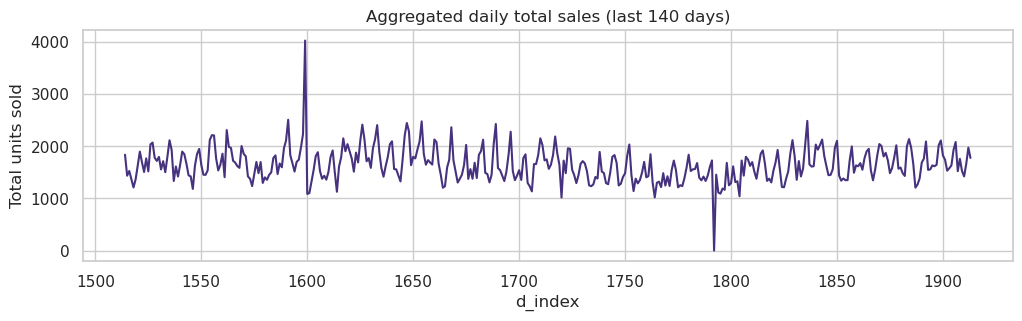

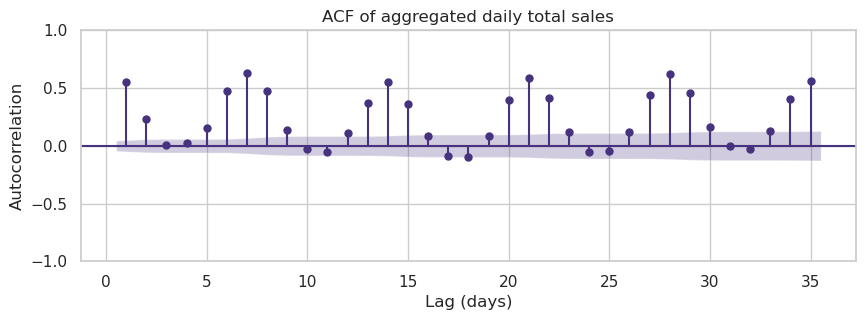

In [112]:
# Weekly structure at aggregate level (supports season=7 baselines and lag_7 feature)

d_cols = [c for c in sales_train_validation.columns if c.startswith("d_")]

daily_total = sales_train_validation[d_cols].astype(float).sum(axis=0)
daily_total.index = daily_total.index.str.replace("d_", "", regex=False).astype(int)
daily_total = daily_total.sort_index()

# Last 140 days (~20 weeks)
x = daily_total.index[-400:]
y = daily_total.values[-400:]
nice_ts_plot(
    x=x,
    y=y,
    title="Aggregated daily total sales (last 140 days)",
    xlabel="d_index",
    ylabel="Total units sold"
)

plot_acf_nice(
    daily_total.values,
    lags=35,
    title="ACF of aggregated daily total sales"
)


## OBSERVE

What we observe? for the aggregated daily totals there is a horizontal trend (the total number of sales stays the same).

## Baseline forecasts 

We validate with a **time-based split** that matches the task: the **last 28 days (F1–F28)** are held out.

Before training any model, we compute **simple rule-based forecasts** that require **no fitting / no learning**:
- **Naïve**: predict each future day as the last observed value.
- **Seasonal naïve (7)**: repeat the last observed week (weekly seasonality).
- **Moving average (7 / 28)**: predict the mean of the last 7 or 28 observed days.

These baselines answer a concrete question:  
**“If we do not train a statistical or ML model and only extrapolate from recent history, how large is the forecast error?”**

**How this tests our hypothesis:**  

**H1 (beats baselines)**  
Baselines are our “no-learning” reference. They answer:  
If we only extrapolate from recent sales history, how large is the 28-day forecast error?  
H1 is supported only if the learned tree-based model achieves **lower RMSE and MAE** than the **best baseline** on the same 28-day hold-out window.

**H2 (intermittency sensitivity)**  
Overall error can hide that some items are easy and others are hard.  
To support H2, we inspect baseline behaviour across **four intermittency groups** defined by each item’s **zero-share** (fraction of days with zero sales).  
We plot one representative item per group (low, medium, high, very high intermittency) to show where smoothing baselines work (stable demand) and where they fail (spikes and long zero stretches).

### Baseline forecasts (H1)

We validate with a **time-based split** that matches the task: the **last 28 days (F1–F28)** are held out.

Before training any statistical or ML model, we compute **rule-based baselines** that require **no fitting / no learning**:
- **Naïve**: predict each future day as the last observed value.
- **Seasonal naïve (7)**: repeat the last observed week.
- **Moving average (7 / 28)**: predict the mean of the last 7 or 28 days.

These baselines establish the **minimum performance bar** for H1.  
H1 is supported only if the learned tree-based model achieves **lower RMSE and MAE** than the **best baseline** on the same 28-day hold-out window.

**WE EXPECT** that Moving Average would perform the best, since the data has no upward or downward trend so its mean does not substantially change. 


In [113]:
# ----------------------------
# Baselines (overall metrics on 28-day hold-out)
# ----------------------------
train_wide, val_wide = make_train_val_frames(sales_train_validation, horizon=28)

baseline_table, preds = summarize_baselines(train_wide, val_wide)
display(baseline_table)

best_name = baseline_table.iloc[0]["model"]
best_pred = preds[best_name]

best_baseline_rmse = float(baseline_table.iloc[0]["RMSE"])
best_baseline_mae  = float(baseline_table.iloc[0]["MAE"])

print("Stored best baseline metrics for later ML comparison (H1).")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")

print("Context for best baseline")
display(relative_error_context(val_wide, best_pred))


,model,RMSE,MAE
3,Moving average window 28,2.801208,1.346812
2,Moving average window 7,2.951324,1.359889
1,Seasonal naive period 7,3.723713,1.604018
0,Naive last value,4.291501,1.757377


Stored best baseline metrics for later ML comparison (H1).
Best baseline: Moving average window 28 | RMSE=2.8012 | MAE=1.3468
Context for best baseline


,val_mean_units,RMSE,MAE,RMSE_over_mean,MAE_over_mean
0,2.046823,2.801208,1.346812,1.368564,0.658001


## Baseline performance by intermittency group (H2)

To test whether forecast difficulty also depends on intermittency, and if they require different handling techniques, we group items by **zero-share**: the fraction of days in the training window with zero sales.  
we use quartiles to form four equally-sized groups (low, medium, high, very high intermittency).

For each group, we report RMSE/MAE for the **best baseline** and plot one representative item from the group to show typical behaviour.


Zero-share cut points (train only): 25%=0.459 | 50%=0.665 | 75%=0.825


,n_items
zero_share,
G4 very high intermittency,206
G2 medium intermittency,206
G1 low intermittency,206
G3 high intermittency,205


,group,n_items,zero_share_mean,RMSE,MAE
0,G1 low intermittency,206,0.275491,4.754558,2.638288
1,G2 medium intermittency,206,0.573104,2.392809,1.353985
2,G3 high intermittency,205,0.749946,1.399477,0.827501
3,G4 very high intermittency,206,0.895138,1.033728,0.564952


Representative items (median zero-share per group):
G1 low intermittency: FOODS_3_811_TX_3_validation | zero_share=29.5%
G2 medium intermittency: FOODS_3_248_TX_3_validation | zero_share=58.0%
G3 high intermittency: FOODS_3_031_TX_3_validation | zero_share=75.5%
G4 very high intermittency: FOODS_3_262_TX_3_validation | zero_share=89.4%


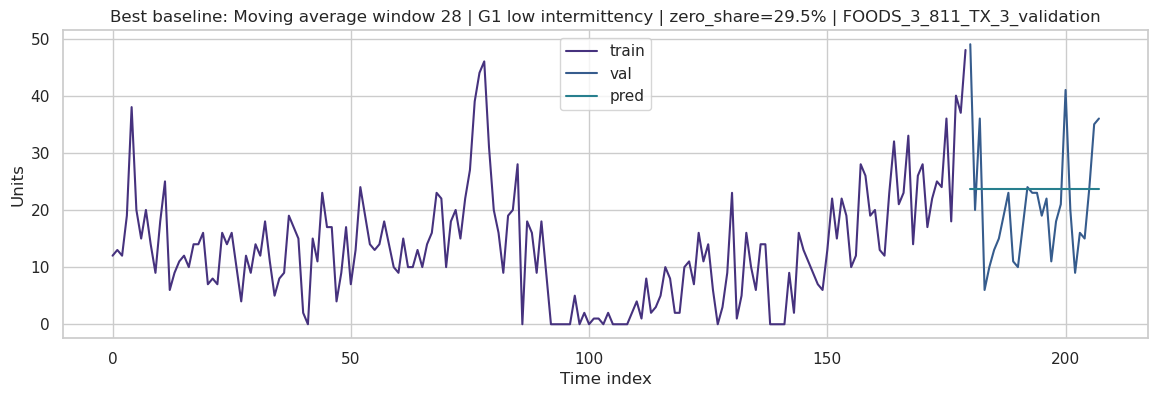

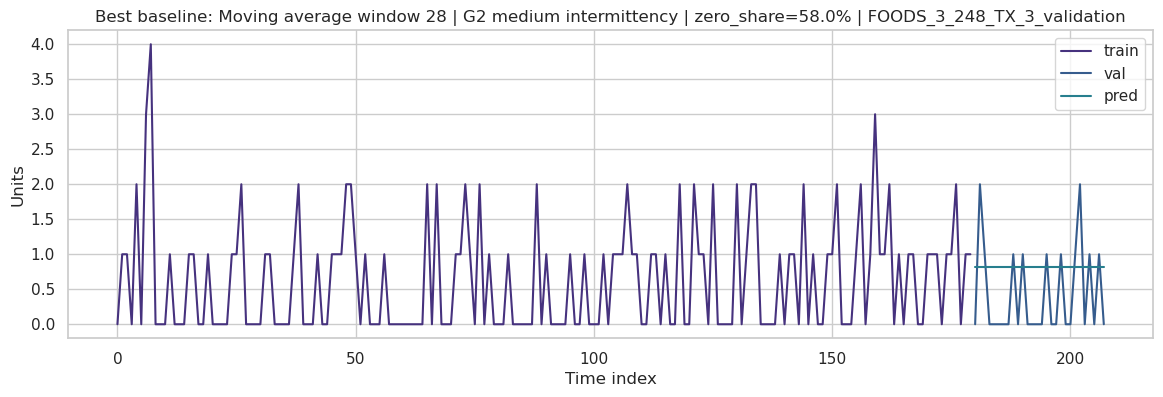

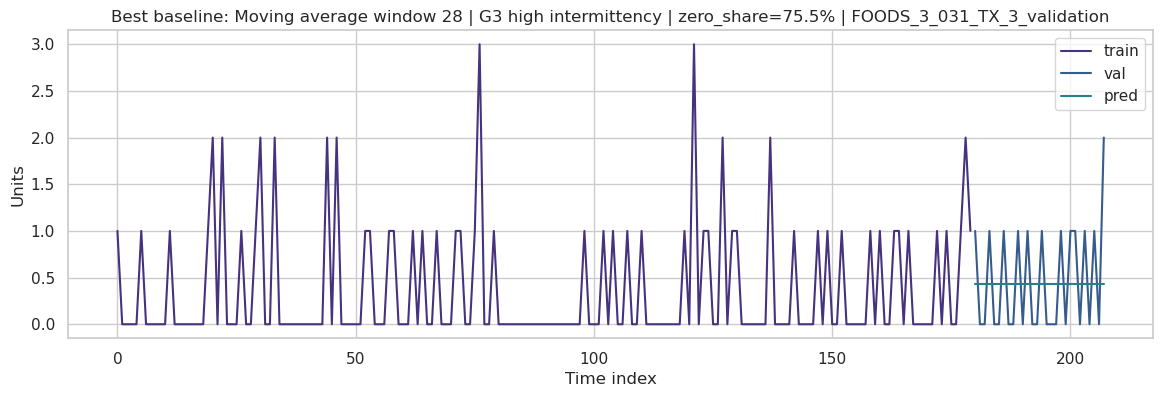

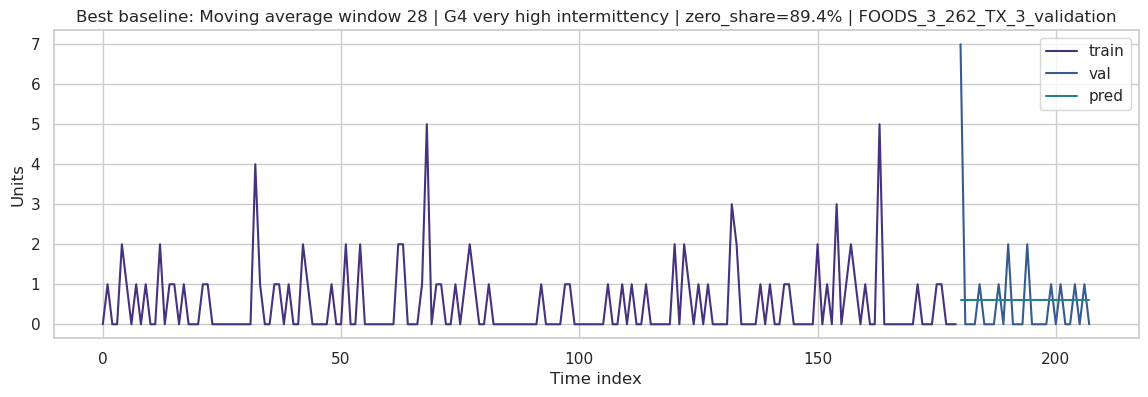

In [114]:
# ----------------------------
# H2 (Baselines): group items by intermittency (zero-share) and evaluate best baseline per group
# ----------------------------

# 1) Compute zero_share on TRAIN window only (avoid peeking at hold-out)
Y_train = train_wide.to_numpy(dtype=float)
zero_share = pd.Series((Y_train == 0).mean(axis=1), index=train_wide.index, name="zero_share")

# Quartile cutpoints
q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).values

def bucket(z):
    if z <= q25:
        return "G1 low intermittency"
    elif z <= q50:
        return "G2 medium intermittency"
    elif z <= q75:
        return "G3 high intermittency"
    else:
        return "G4 very high intermittency"

groups = zero_share.apply(bucket)

print(f"Zero-share cut points (train only): 25%={q25:.3f} | 50%={q50:.3f} | 75%={q75:.3f}")
display(groups.value_counts().rename("n_items").to_frame())

# 2) Compute RMSE/MAE per group for the BEST baseline
Y_val = val_wide.to_numpy(dtype=float)

rows = []
for g in ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]:
    idx = np.where(groups.values == g)[0]
    rows.append({
        "group": g,
        "n_items": int(len(idx)),
        "zero_share_mean": float(zero_share[groups == g].mean()),
        "RMSE": rmse(Y_val[idx, :], best_pred[idx, :]),
        "MAE":  mae(Y_val[idx, :], best_pred[idx, :]),
    })

baseline_by_group = pd.DataFrame(rows)
display(baseline_by_group)

# 3) Pick one representative item per group (closest to group's median zero_share) and plot it
rep_items = []
for g in ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]:
    zs_g = zero_share[groups == g]
    target = zs_g.median()
    rid = (zs_g - target).abs().sort_values().index[0]
    rep_items.append((g, rid, float(zs_g.loc[rid])))

print("Representative items (median zero-share per group):")
for g, rid, zs in rep_items:
    print(f"{g}: {rid} | zero_share={zs:.1%}")

for g, rid, zs in rep_items:
    plot_forecast_item(
        rid,
        train_wide,
        val_wide,
        best_pred,
        tail=180,
        title=f"Best baseline: {best_name} | {g} | zero_share={zs:.1%} | {rid}"
    )


## Interpretation of baseline results (H1 + H2)

### H1: Overall baseline reference
Across all items and all 28 validation days, the best “no-learning” method is a **28-day moving average** (RMSE 2.80, MAE 1.35).  
This sets the reference level for H1: the tree-based model must achieve **lower RMSE and MAE** on the same hold-out window to justify added complexity.

To interpret scale: the mean validation demand is **2.05 units per item per day**, so RMSE 2.80 is large relative to the typical level (RMSE/mean ≈ 1.37). This motivates using lag structure and known covariates (weekday, SNAP, price) to adapt to predictable variation.

### H2: Baseline error differs strongly by intermittency group
Baseline error is not uniform across items. Using zero-share quartiles:

- **Low intermittency (G1)** has the largest error (RMSE 4.75, MAE 2.64).
- **Very high intermittency (G4)** has the smallest error (RMSE 1.03, MAE 0.56).

This happens because highly intermittent items are zero on most days, so a smoothing baseline that predicts near-zero can look accurate even if it does not capture rare spikes.  
This is exactly why H2 matters: we will test whether the tree-based model provides larger gains for the low/medium intermittency groups where demand variation is more systematic and predictable.


## Tree based models with lag plus calendar plus price features (tests H1 and H2)

The baselines only extrapolate from past sales and do not use known drivers such as weekday effects, SNAP, events, or price signals.  
To test H1, we train supervised tree based models that can learn non linear interactions between these covariates and recent demand history.

We use one shared feature set for every model so the comparison is fair.

**Target**
Daily unit sales per item.

**Features**
Lag_1, lag_7, lag_28  
Calendar signals: weekday, month, year, wday, SNAP, event name and type  
Price signals: sell_price, price_change, and an indicator for imputed prices

**Split and evaluation shape**
We keep the last 28 days as the hold out window, matching F1 to F28.  
Baselines are evaluated as an items by 28 days matrix.  
To compare fairly, we evaluate every tree model in the exact same matrix shape and compute RMSE and MAE on that matrix.

**Models for comparison**

HistGradientBoostingRegressor  
XGBoost regressor  
LightGBM regression  


**How this maps to the hypotheses**
1. H1 is supported if the best tree model has lower RMSE and MAE than the best baseline on the same 28 day hold out.  
2. H2 is evaluated by repeating the same baseline versus best tree comparison inside each intermittency group.


In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

# I keep the evaluation consistent with the task horizon.
H = 28

# I keep the same feature set for all models so the comparison is fair.
CAT_COLS = ["weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]
NUM_COLS = [
    "lag_1", "lag_7", "lag_28",
    "sell_price", "price_change", "sell_price_was_missing",
    "wday", "month", "year", "snap_TX",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

def make_ml_train_val_from_sales_long(sales_long: pd.DataFrame, horizon: int = 28, n_days: int = 730):
    # I work on a copy so I never mutate the shared dataframe accidentally.
    df = sales_long.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # I fill missing categoricals with a stable token.
    for c in CAT_COLS:
        df[c] = df[c].fillna("none").astype(str)

    # I limit history for runtime, but keep the last N days plus the hold-out horizon.
    max_d = int(df["d_index"].max())
    min_d = max(1, max_d - (n_days + horizon) + 1)
    df = df[df["d_index"] >= min_d].copy()

    # I do a leak-free split: train is everything up to cutoff, val is the last horizon days.
    cutoff = int(df["d_index"].max() - horizon)
    train_df = df[df["d_index"] <= cutoff].copy()
    val_df   = df[df["d_index"] >  cutoff].copy()

    # Lags must exist; otherwise I drop those rows.
    train_df = train_df.dropna(subset=["lag_1", "lag_7", "lag_28"])
    val_df   = val_df.dropna(subset=["lag_1", "lag_7", "lag_28"])

    X_train = train_df[FEATURE_COLS]
    y_train = train_df["sales"].astype(np.float32).values

    X_val = val_df[FEATURE_COLS]
    y_val = val_df["sales"].astype(np.float32).values

    return train_df, val_df, X_train, y_train, X_val, y_val, cutoff

train_long, val_long, X_train, y_train, X_val, y_val, cutoff = make_ml_train_val_from_sales_long(
    sales_long, horizon=H, n_days=730
)

print("Cutoff d_index:", cutoff)
print("Train rows:", len(X_train), "Val rows:", len(X_val))
print("Features:", len(FEATURE_COLS))

Cutoff d_index: 1885
Train rows: 600790 Val rows: 23044
Features: 15


In [116]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from sklearn.ensemble import HistGradientBoostingRegressor

# Optional models (only used if installed)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost not available:", e)

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except Exception as e:
    HAS_LGB = False
    print("LightGBM not available:", e)


def build_val_long_exact(sales_long: pd.DataFrame, cutoff: int, horizon: int, ids: pd.Index):
    # We take exactly the last H days after cutoff for exactly the same ids as val_wide.
    val_days = list(range(cutoff + 1, cutoff + horizon + 1))
    val_long_exact = sales_long[
        (sales_long["d_index"].isin(val_days)) &
        (sales_long["id"].isin(ids))
    ].copy()

    # Sanity check: full (id, day) grid must exist
    expected = len(ids) * horizon
    got = len(val_long_exact)
    if got != expected:
        all_pairs = pd.MultiIndex.from_product([ids, val_days], names=["id", "d_index"])
        have_pairs = pd.MultiIndex.from_frame(val_long_exact[["id", "d_index"]])
        missing = all_pairs.difference(have_pairs)

        print(f"val_long_exact incomplete: expected={expected}, got={got}, missing={len(missing)} cells")
        print("First 20 missing (id, d_index):", list(missing[:20]))
        raise ValueError("Validation grid incomplete. Something upstream filtered sales_long or ids mismatch.")

    return val_long_exact


# One shared preprocessing step so model comparison is fair
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_COLS),
        ("cat", ord_enc, CAT_COLS),
    ],
    remainder="drop",
)

# Ensure ids match between wide and long
train_wide.index = train_wide.index.astype(str)
val_wide.index   = val_wide.index.astype(str)
sales_long["id"] = sales_long["id"].astype(str)

# Build the exact validation long table for the baseline grid
val_long_exact = build_val_long_exact(
    sales_long=sales_long,
    cutoff=cutoff,
    horizon=H,
    ids=val_wide.index,
)

print("val_long_exact rows:", len(val_long_exact), "| expected:", len(val_wide.index) * H)


val_long_exact rows: 23044 | expected: 23044


In [117]:
def eval_model_against_val_wide(
    name: str,
    estimator,
    X_train,
    y_train,
    val_long_exact: pd.DataFrame,
    val_wide: pd.DataFrame,
    preprocess,
):
    # Fit with identical preprocessing
    pipe = Pipeline(steps=[("prep", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)

    # Predict exactly the validation rows (same ids x same 28 days)
    X_val_exact = val_long_exact[FEATURE_COLS]
    pred_long = pipe.predict(X_val_exact)
    pred_long = np.maximum(pred_long, 0.0)

    # Pivot into (items x 28 days) and align to val_wide columns
    pred_df = val_long_exact[["id", "d_index"]].copy()
    pred_df["pred"] = pred_long

    Y_pred_wide = pred_df.pivot(index="id", columns="d_index", values="pred")
    Y_pred_wide.columns = [f"d_{int(c)}" for c in Y_pred_wide.columns]
    Y_pred_wide = Y_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

    # Stop if anything is missing
    n_missing = int(Y_pred_wide.isna().sum().sum())
    if n_missing > 0:
        raise ValueError(f"{name}: prediction matrix has {n_missing} missing cells after alignment.")

    Y_true = val_wide.to_numpy(dtype=float)
    Y_pred = Y_pred_wide.to_numpy(dtype=float)

    return {
        "model": name,
        "RMSE": rmse(Y_true, Y_pred),
        "MAE": mae(Y_true, Y_pred),
        "pipe": pipe,
        "Y_pred_wide": Y_pred_wide,
    }


results = []

# HistGBR
results.append(eval_model_against_val_wide(
    "HistGBR (squared error)",
    HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=6,
        max_iter=200,
        random_state=42,
    ),
    X_train, y_train, val_long_exact, val_wide, preprocess
))

# XGBoost
if HAS_XGB:
    results.append(eval_model_against_val_wide(
        "XGBoost (squarederror)",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))

# LightGBM family
if HAS_LGB:
    results.append(eval_model_against_val_wide(
        "LightGBM (regression)",
        LGBMRegressor(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="regression",
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))

    results.append(eval_model_against_val_wide(
        "LightGBM (poisson)",
        LGBMRegressor(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="poisson",
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))

    results.append(eval_model_against_val_wide(
        "LightGBM (tweedie p=1.3)",
        LGBMRegressor(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="tweedie",
            tweedie_variance_power=1.3,
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))

results_table = (
    pd.DataFrame([{"model": r["model"], "RMSE": r["RMSE"], "MAE": r["MAE"]} for r in results])
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_table)

best_result = results[[r["model"] for r in results].index(results_table.loc[0, "model"])]
best_tree_name = best_result["model"]

print("Best tree model:", best_tree_name)
print(f"{best_tree_name} | RMSE={best_result['RMSE']:.4f} | MAE={best_result['MAE']:.4f}")


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,RMSE,MAE
0,LightGBM (regression),2.561446,1.252233
1,XGBoost (squarederror),2.564791,1.244252
2,HistGBR (squared error),2.609420,1.273388
3,LightGBM (poisson),3.275894,1.399517
4,LightGBM (tweedie p=1.3),3.431867,1.440219


Best tree model: LightGBM (regression)
LightGBM (regression) | RMSE=2.5614 | MAE=1.2522


In [118]:
# Choose best tree model (use RMSE for selection; switch to "MAE" if you prefer)
best_tree = min(results, key=lambda r: r["RMSE"])

print("H1 conclusion on the 28-day hold-out (all items)")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")
print(f"Best tree   : {best_tree['model']} | RMSE={best_tree['RMSE']:.4f} | MAE={best_tree['MAE']:.4f}")

rmse_imp = best_baseline_rmse - best_tree["RMSE"]
mae_imp  = best_baseline_mae  - best_tree["MAE"]

print(f"Improvement (baseline - best tree): RMSE={rmse_imp:.4f} ({rmse_imp / best_baseline_rmse:.1%}) | "
      f"MAE={mae_imp:.4f} ({mae_imp / best_baseline_mae:.1%})")

# Grab prediction matrix for H2 + plotting
Y_pred_wide = best_tree["Y_pred_wide"]


H1 conclusion on the 28-day hold-out (all items)
Best baseline: Moving average window 28 | RMSE=2.8012 | MAE=1.3468
Best tree   : LightGBM (regression) | RMSE=2.5614 | MAE=1.2522
Improvement (baseline - best tree): RMSE=0.2398 (8.6%) | MAE=0.0946 (7.0%)


Overall comparison on the 28-day hold-out (all items)
Best baseline: Moving average window 28 | RMSE=2.8012 | MAE=1.3468
Best tree   : LightGBM (regression) | RMSE=2.5614 | MAE=1.2522
Improvement (baseline - tree): RMSE=0.2398 (8.6%) | MAE=0.0946 (7.0%)


,group,n_items,zero_share_mean,baseline_RMSE,tree_RMSE,RMSE_improvement,baseline_MAE,tree_MAE,MAE_improvement
0,G1 low intermittency,206,0.275491,4.754558,4.230480,0.524079,2.638288,2.335638,0.302650
1,G2 medium intermittency,206,0.573104,2.392809,2.350779,0.042030,1.353985,1.331216,0.022769
2,G3 high intermittency,205,0.749946,1.399477,1.347695,0.051782,0.827501,0.783766,0.043735
3,G4 very high intermittency,206,0.895138,1.033728,0.990751,0.042977,0.564952,0.556037,0.008915


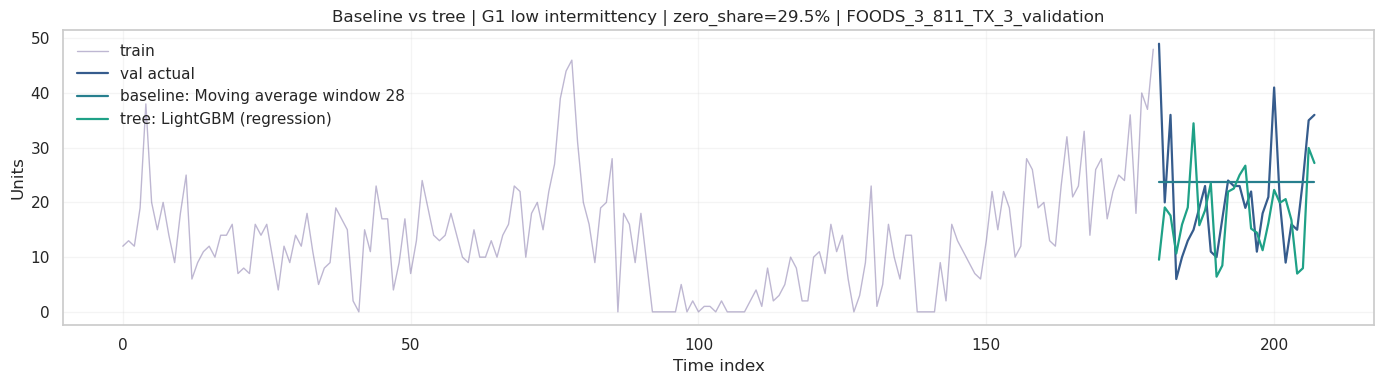

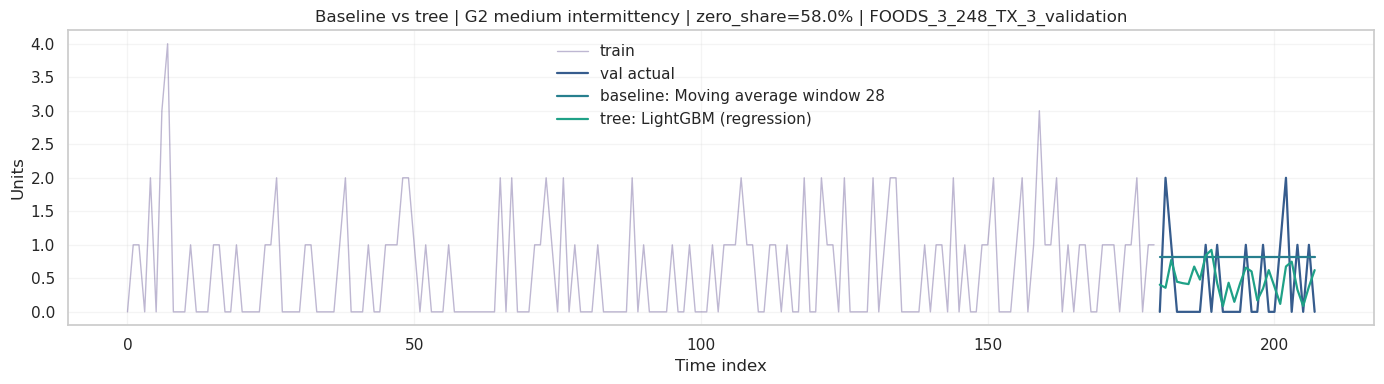

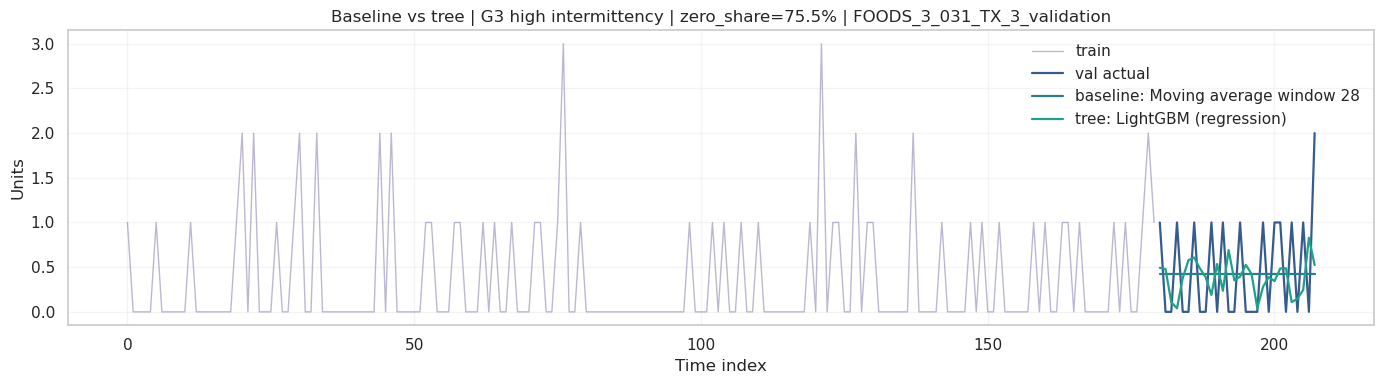

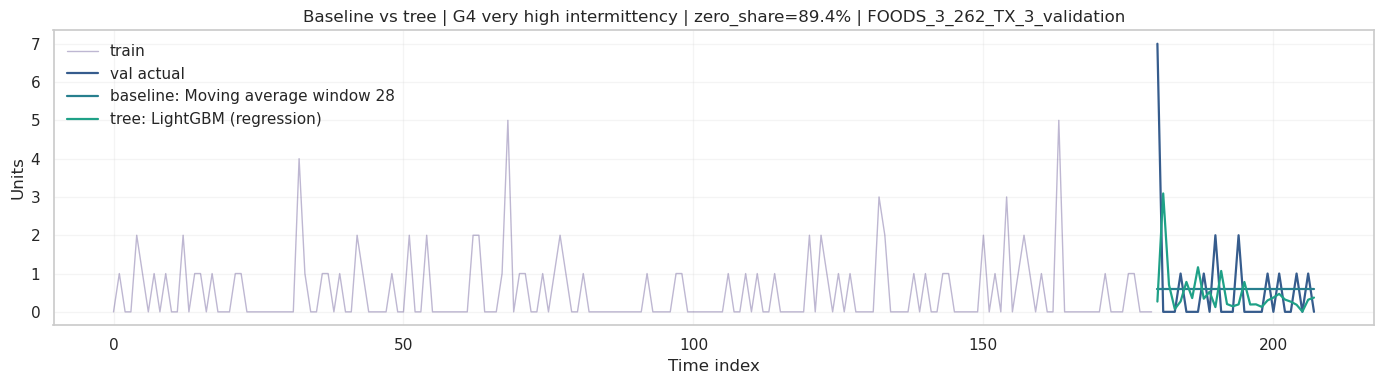

In [119]:

# Preconditions (from earlier cells):
# - train_wide, val_wide
# - best_name, best_pred, best_baseline_rmse, best_baseline_mae
# - groups, zero_share, rep_items
# - rmse(), mae()
# - best_tree dict exists and contains: best_tree["model"], best_tree["RMSE"], best_tree["MAE"], best_tree["Y_pred_wide"]

# ----------------------------
# 1) Align prediction matrices on the SAME (id x 28 days) grid
# ----------------------------

# Baseline predictions as wide DF
baseline_pred_wide = pd.DataFrame(best_pred, index=val_wide.index, columns=val_wide.columns)

# Tree predictions as wide DF (already on baseline grid in your eval function, but align defensively)
tree_pred_wide = best_tree["Y_pred_wide"].copy()
tree_pred_wide = tree_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

# Hard stop if anything is missing (prevents silent NaNs -> garbage metrics)
missing_base = int(baseline_pred_wide.isna().sum().sum())
missing_tree = int(tree_pred_wide.isna().sum().sum())
if missing_base > 0:
    raise ValueError(f"baseline_pred_wide has {missing_base} NaN cells after alignment.")
if missing_tree > 0:
    raise ValueError(f"tree_pred_wide has {missing_tree} NaN cells after alignment. Check val_long_exact grid.")

# Clip negatives (counts)
baseline_pred_wide = baseline_pred_wide.clip(lower=0.0)
tree_pred_wide = tree_pred_wide.clip(lower=0.0)

Y_true = val_wide.to_numpy(dtype=float)
Y_base = baseline_pred_wide.to_numpy(dtype=float)
Y_tree = tree_pred_wide.to_numpy(dtype=float)

# ----------------------------
# 2) Overall H1-style comparison (same grid)
# ----------------------------
tree_rmse_all = rmse(Y_true, Y_tree)
tree_mae_all  = mae(Y_true, Y_tree)

print("Overall comparison on the 28-day hold-out (all items)")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")
print(f"Best tree   : {best_tree['model']} | RMSE={tree_rmse_all:.4f} | MAE={tree_mae_all:.4f}")

rmse_imp_all = best_baseline_rmse - tree_rmse_all
mae_imp_all  = best_baseline_mae  - tree_mae_all
print(f"Improvement (baseline - tree): RMSE={rmse_imp_all:.4f} ({rmse_imp_all / best_baseline_rmse:.1%}) | "
      f"MAE={mae_imp_all:.4f} ({mae_imp_all / best_baseline_mae:.1%})")

# ----------------------------
# 3) H2: Baseline vs tree by intermittency group (same groups, same grid)
# ----------------------------
group_order = ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]

rows = []
for g in group_order:
    idx = np.where(groups.values == g)[0]

    base_rmse_g = rmse(Y_true[idx, :], Y_base[idx, :])
    base_mae_g  = mae(Y_true[idx, :], Y_base[idx, :])

    tree_rmse_g = rmse(Y_true[idx, :], Y_tree[idx, :])
    tree_mae_g  = mae(Y_true[idx, :], Y_tree[idx, :])

    rows.append({
        "group": g,
        "n_items": int(len(idx)),
        "zero_share_mean": float(zero_share[groups == g].mean()),
        "baseline_RMSE": base_rmse_g,
        "tree_RMSE": tree_rmse_g,
        "RMSE_improvement": base_rmse_g - tree_rmse_g,
        "baseline_MAE": base_mae_g,
        "tree_MAE": tree_mae_g,
        "MAE_improvement": base_mae_g - tree_mae_g,
    })

compare_by_group = pd.DataFrame(rows)
display(compare_by_group)

# ----------------------------
# 4) Plots: same representative items, but baseline and tree in the same figure
# ----------------------------
def plot_item_baseline_vs_tree(
    item_id: str,
    group_label: str,
    zs: float,
    tail: int = 180,
):
    if item_id not in train_wide.index:
        raise ValueError(f"item_id not in train_wide: {item_id}")
    if item_id not in val_wide.index:
        raise ValueError(f"item_id not in val_wide: {item_id}")

    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))

    # Keep lines thin and readable
    plt.plot(x_train, train_tail.values, linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val, y_val.values,       linewidth=1.6, label="val actual")
    plt.plot(x_val, pred_base,          linewidth=1.6, label=f"baseline: {best_name}")
    plt.plot(x_val, pred_tree,          linewidth=1.6, label=f"tree: {best_tree['model']}")

    plt.title(f"Baseline vs tree | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_item_baseline_vs_tree(rid, g, zs, tail=180)

## H2 results (who benefits most)

Performance gains from the tree-based model vary strongly with intermittency.
The largest improvement occurs for low-intermittency items (G1): RMSE drops from 4.75 to 4.23 (- 0.52) and MAE drops from 2.64 to 2.34 (-0.30). 


**This is where learning calendar/price effects and reacting to level changes adds clear value beyond smoothing.**

For G2–G4, improvements are much smaller. RMSE decreases by about 0.04–0.05 in each group, and MAE also improves slightly (+0.02 in G2, +0.04 in G3, +0.01 in G4).
So, in this dataset, the tree model’s advantage is concentrated in the higher-volume / less intermittent series, while for very intermittent series it mainly provides marginal gains.

## Feature importance for the best tree model (permutation, RMSE-based)

After selecting the best-performing tree model on the 28-day hold-out, we check which inputs it actually relies on.

We compute **permutation importance** on the validation grid:
we randomly shuffle one feature at a time and measure how much validation **RMSE worsens**.
A larger RMSE increase means the feature was more important for predictive accuracy.

Because lag features are correlated (lag_1, lag_7, lag_28), permutation importance should be interpreted as a **global ranking**, not as a causal effect size.


Permutation importance for: LightGBM (regression)


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have v

,feature,importance_rmse_drop,std
7,month,-0.000066,0.000924
5,sell_price_was_missing,0.000000,0.000000
8,year,0.000000,0.000000
11,event_name_1,0.000000,0.000000
12,event_type_1,0.000000,0.000000
13,event_name_2,0.000000,0.000000
14,event_type_2,0.000000,0.000000
4,price_change,0.000559,0.000374
9,snap_TX,0.007756,0.003551
10,weekday,0.009252,0.002812


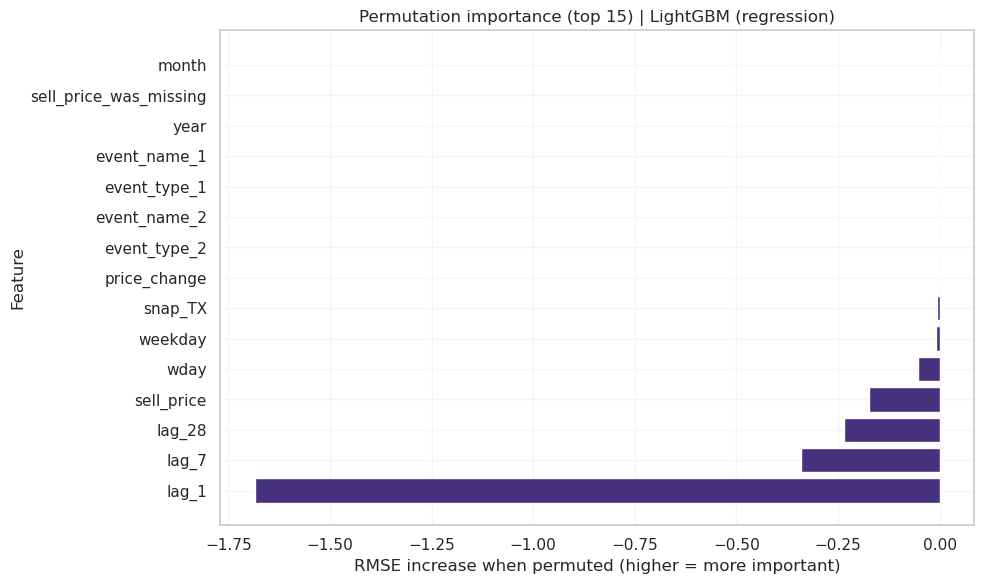

In [120]:
# ----------------------------
# Feature importance (Permutation) for the BEST tree model
# Uses: results_table, results, val_long_exact, FEATURE_COLS
# ----------------------------

# 1) Fetch best model object from the results list
best_tree_name = results_table.loc[0, "model"]
best_tree = next(r for r in results if r["model"] == best_tree_name)
best_pipe = best_tree["pipe"]

print("Permutation importance for:", best_tree_name)

# 2) Build X/y on the exact validation grid
X_val_exact = val_long_exact[FEATURE_COLS].copy()
y_val_exact = val_long_exact["sales"].astype(float).values

# 3) RMSE scorer (negative because sklearn assumes "higher is better")
def rmse_metric(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_metric, greater_is_better=False)

# 4) Permutation importance (keep it moderate to avoid long runtime)
perm = permutation_importance(
    best_pipe,
    X_val_exact,
    y_val_exact,
    scoring=rmse_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance_rmse_drop": perm.importances_mean,   # more negative => bigger RMSE increase when permuted
    "std": perm.importances_std,
}).sort_values("importance_rmse_drop")  # most negative at top

display(imp)

# 5) Plot top-k (largest RMSE degradation => most useful features)
TOPK = 15
top = imp.head(TOPK).iloc[::-1]  # reverse for barh

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], -top["importance_rmse_drop"])  # flip sign so "bigger bar = more important"
plt.xlabel("RMSE increase when permuted (higher = more important)")
plt.ylabel("Feature")
plt.title(f"Permutation importance (top {TOPK}) | {best_tree_name}")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [124]:
# Build train/val frames with feature columns (uses long tables already built)
CAT_COLS = ["weekday"]
NUM_COLS = [
    "lag_1", "lag_7", "lag_28",
    "sell_price", "price_change",
    "wday", "month", "snap_TX",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

# Drop rows without required lags
train_df = train_long_exact.dropna(subset=["lag_1", "lag_7", "lag_28"]).copy()
val_df   = val_long_exact.dropna(subset=["lag_1", "lag_7", "lag_28"]).copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df["sales"].astype(float)

X_val = val_df[FEATURE_COLS]
y_val = val_df["sales"].astype(float)

# Pruned HistGBR fit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

preprocess = ColumnTransformer(
    [
        ("num", "passthrough", NUM_COLS),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_COLS),
    ]
)

cat_feature_idx = list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS)))

model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    random_state=42,
    categorical_features=cat_feature_idx,
)

pipe_pruned = Pipeline([("prep", preprocess), ("model", model)])
pipe_pruned.fit(X_train, y_train)

pred_pruned = pipe_pruned.predict(X_val)
rmse_pruned = float(np.sqrt(np.mean((y_val - pred_pruned) ** 2)))
mae_pruned  = float(np.mean(np.abs(y_val - pred_pruned)))

print(f"Pruned model RMSE: {rmse_pruned:.4f} | MAE: {mae_pruned:.4f}")


Pruned model RMSE: 2.3936 | MAE: 1.2520


## Feature importance (permutation, RMSE-based)

To understand *which inputs the model actually uses*, we compute **permutation importance** on the 28-day validation grid.  
For each feature, we randomly shuffle its values and re-score the model.  
If RMSE increases a lot, the feature was important; if RMSE barely changes, the feature contributed little beyond the others.

### Key finding: the model is driven mainly by recent sales history

The importance ranking is dominated by lag features:

- **lag_1** is by far the most important feature (largest RMSE increase when permuted).  
  This means the model relies heavily on yesterday’s sales to predict today’s demand.
- **lag_7** and **lag_28** also matter, indicating weekly and monthly memory, but their contribution is much smaller than lag_1.

### Secondary drivers: price level and weekday

- **sell_price** has clear importance, suggesting the model uses price level to adjust demand predictions beyond what lags explain.
- **wday / weekday** contribute modestly, consistent with weekly seasonality effects.

### Minimal signal from events and short-term price changes

- **price_change** shows near-zero importance, meaning short-term price deltas (as defined here) do not meaningfully change predictions.
- Event variables (event_name/type) have ~0 importance, which suggests either:
  1) events are too sparse/noisy at item-level,  
  2) the encoding is not helpful, or  
  3) lag and price already capture most of the event-driven variation.

**Caveat:** permutation importance can underestimate features when predictors are correlated (especially lags).  
We interpret this as a *global ranking*, not as a causal statement.


In [125]:
#------------------
# SQ1: Promotions and immediate spikes
# Definition:
# promotion := price_change_pct <= -0.05
# spike := mean(sales next 7 days) - mean(sales prev 7 days)
# ----------------------------

df = sales_long.copy()
df = df.sort_values(["id", "d_index"])

# Percent price change (safer than raw change across items)
df["prev_price"] = df.groupby("id")["sell_price"].shift(1)
df["price_change_pct"] = (df["sell_price"] - df["prev_price"]) / df["prev_price"]

PROMO_THR = -0.05
WINDOW = 7

# Rolling means for spike definition
df["mean_prev7"] = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(WINDOW).mean())
df["mean_next7"] = df.groupby("id")["sales"].transform(lambda s: s.shift(-WINDOW).rolling(WINDOW).mean())
df["spike"] = df["mean_next7"] - df["mean_prev7"]

promo_rows = df[(df["price_change_pct"].notna()) & (df["spike"].notna()) & (df["price_change_pct"] <= PROMO_THR)].copy()

# Per-item average spike on promotion days
per_item = (promo_rows.groupby("id")
            .agg(n_promo_days=("spike", "size"),
                 avg_spike_units=("spike", "mean"),
                 median_spike_units=("spike", "median"))
            .sort_values("avg_spike_units", ascending=False))

display(per_item.head(20))
print("Items with >= 5 promo days:", (per_item["n_promo_days"] >= 5).sum())

# Overall summary (avoid being misled by tiny n)
valid = per_item[per_item["n_promo_days"] >= 5]
print("Across items (>=5 promo days):")
print(valid["avg_spike_units"].describe(percentiles=[0.1, 0.5, 0.9]).to_string())


,n_promo_days,avg_spike_units,median_spike_units
id,,,
FOODS_3_090_TX_3_validation,3,80.000000,46.000000
FOODS_3_607_TX_3_validation,4,21.928571,10.857143
FOODS_3_030_TX_3_validation,4,16.607143,8.500000
FOODS_3_318_TX_3_validation,5,13.485714,7.428571
FOODS_3_808_TX_3_validation,4,9.750000,3.357143
FOODS_3_237_TX_3_validation,1,9.142857,9.142857
FOODS_3_511_TX_3_validation,2,8.285714,8.285714
FOODS_3_491_TX_3_validation,3,8.000000,6.000000
FOODS_3_534_TX_3_validation,2,6.071429,6.071429


Items with >= 5 promo days: 80
Across items (>=5 promo days):
count    80.000000
mean      0.781360
std       1.901735
min      -2.514286
10%      -0.278571
50%       0.416667
90%       2.324643
max      13.485714


## SQ2: Stock-up effect during SNAP eligibility days

We test whether unit sales are higher on **SNAP eligibility days** than on non-SNAP days.
Because sales have strong weekday patterns and are influenced by price, we report:

1) A **simple paired comparison per item** (SNAP mean vs non-SNAP mean).
2) A **controlled estimate** using a regression with item fixed effects and calendar/price controls.

This does not prove causality, but it quantifies whether a SNAP-associated uplift is present in this store/category.


Items total: 823 Reliable items (min days >= 10): 823
Share of items with positive SNAP uplift: 0.9113001215066828

SNAP uplift distribution across items (reliable only):
count    823.000000
mean       0.241639
std        0.492368
min       -1.294211
10%        0.002624
50%        0.097087
90%        0.587067
max        4.454686

Weighted average uplift (weights = min_days): 0.24163881267071627

Top 10 items by SNAP uplift


snap_TX,mean_non_snap,mean_snap,n_non_snap,n_snap,diff_units,min_days
id,,,,,,
FOODS_3_547_TX_3_validation,6.232411,10.687097,1265,620,4.454686,620
FOODS_3_586_TX_3_validation,77.430830,81.517742,1265,620,4.086912,620
FOODS_3_090_TX_3_validation,58.820553,62.456452,1265,620,3.635898,620
FOODS_3_376_TX_3_validation,13.456126,16.651613,1265,620,3.195486,620
FOODS_3_377_TX_3_validation,37.571542,40.474194,1265,620,2.902652,620
FOODS_3_587_TX_3_validation,20.128854,23.022581,1265,620,2.893727,620
FOODS_3_234_TX_3_validation,9.173913,11.996774,1265,620,2.822861,620
FOODS_3_154_TX_3_validation,7.892490,10.506452,1265,620,2.613961,620
FOODS_3_555_TX_3_validation,39.948617,42.511290,1265,620,2.562674,620



Bottom 10 items by SNAP uplift


snap_TX,mean_non_snap,mean_snap,n_non_snap,n_snap,diff_units,min_days
id,,,,,,
FOODS_3_635_TX_3_validation,14.407115,13.112903,1265,620,-1.294211,620
FOODS_3_808_TX_3_validation,14.283794,13.087097,1265,620,-1.196698,620
FOODS_3_069_TX_3_validation,2.176285,1.287097,1265,620,-0.889188,620
FOODS_3_541_TX_3_validation,12.543083,12.059677,1265,620,-0.483406,620
FOODS_3_767_TX_3_validation,5.067984,4.848387,1265,620,-0.219597,620
FOODS_3_681_TX_3_validation,12.398419,12.211290,1265,620,-0.187129,620
FOODS_3_524_TX_3_validation,3.993676,3.812903,1265,620,-0.180773,620
FOODS_3_008_TX_3_validation,1.328063,1.159677,1265,620,-0.168386,620
FOODS_3_135_TX_3_validation,3.645850,3.488710,1265,620,-0.157140,620


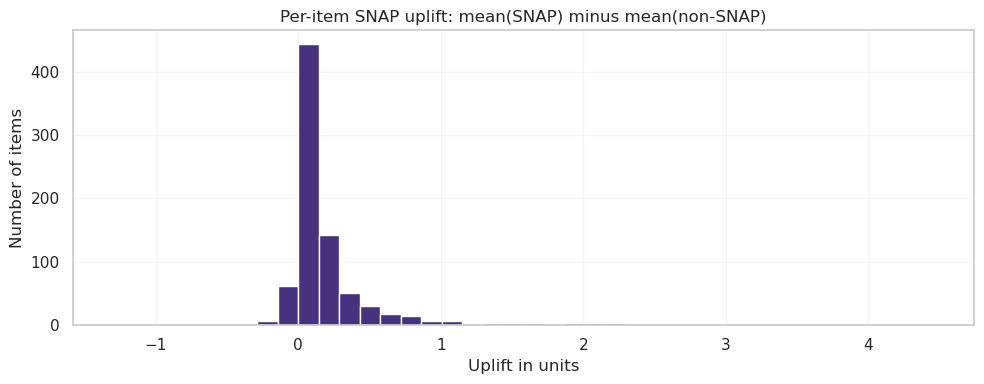


Controlled SNAP effect (within-item, with weekday + price + calendar controls)
SNAP coefficient (units): 0.2378 | robust SE: 0.0070
Interpretation: within the same item, expected change in daily units on SNAP days, after controls.


In [126]:

# ----------------------------
# SQ2: Stock-up effect during SNAP eligibility (TX)
# We do two views:
# 1) per-item SNAP uplift = mean(SNAP) - mean(non-SNAP)
# 2) controlled effect with item fixed effects (demeaning)
# ----------------------------
import statsmodels.api as sm
df = sales_long.copy().sort_values(["id", "d_index"])
df = df[df["snap_TX"].notna()].copy()
df["snap_TX"] = df["snap_TX"].astype(int)

# Optional: keep TRAIN only to avoid peeking (same idea as our intermittency buckets)
d_cols = [c for c in sales_train_validation.columns if c.startswith("d_")]
H = 28
train_last_d = len(d_cols) - H
df = df[df["d_index"] <= train_last_d].copy()

# ----------------------------
# 1) Per-item paired difference (interpretable and compact)
# ----------------------------
means = (df.groupby(["id", "snap_TX"])["sales"]
           .mean()
           .unstack()
           .rename(columns={0: "mean_non_snap", 1: "mean_snap"}))

counts = (df.groupby(["id", "snap_TX"])["sales"]
            .size()
            .unstack(fill_value=0)
            .rename(columns={0: "n_non_snap", 1: "n_snap"}))

item = means.join(counts, how="inner")
item["diff_units"] = item["mean_snap"] - item["mean_non_snap"]
item["min_days"] = item[["n_non_snap", "n_snap"]].min(axis=1)

MIN_DAYS = 10
reliable = item[item["min_days"] >= MIN_DAYS].copy()

print("Items total:", len(item), "Reliable items (min days >= %d):" % MIN_DAYS, len(reliable))
print("Share of items with positive SNAP uplift:",
      float((reliable["diff_units"] > 0).mean()))

print("\nSNAP uplift distribution across items (reliable only):")
print(reliable["diff_units"].describe(percentiles=[0.1, 0.5, 0.9]).to_string())

weighted_uplift = float(np.average(reliable["diff_units"], weights=reliable["min_days"]))
print("\nWeighted average uplift (weights = min_days):", weighted_uplift)

# Only show small, readable tables
print("\nTop 10 items by SNAP uplift")
display(reliable.sort_values("diff_units", ascending=False).head(10))

print("\nBottom 10 items by SNAP uplift")
display(reliable.sort_values("diff_units", ascending=True).head(10))

# Simple histogram (one plot, readable)
plt.figure(figsize=(10, 4))
plt.hist(reliable["diff_units"].values, bins=40)
plt.title("Per-item SNAP uplift: mean(SNAP) minus mean(non-SNAP)")
plt.xlabel("Uplift in units")
plt.ylabel("Number of items")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ----------------------------
# 2) Controlled effect with item fixed effects via demeaning
# This avoids huge item dummy matrices and avoids the dtype=object crash.
# We control for weekday using 6 dummies (wday 2..7) and for price + month + year.
# ----------------------------
reg = df[["id", "sales", "snap_TX", "sell_price", "wday", "month", "year"]].dropna().copy()

# weekday dummies (small set, not item dummies)
wday_d = pd.get_dummies(reg["wday"].astype(int), prefix="wday", drop_first=True)
reg = pd.concat([reg, wday_d], axis=1)

# demean within each item (fixed effects)
cols_to_demean = ["sales", "snap_TX", "sell_price", "month", "year"] + list(wday_d.columns)

for c in cols_to_demean:
    reg[c + "_dm"] = reg[c] - reg.groupby("id")[c].transform("mean")

y = reg["sales_dm"].astype(float).values

X_cols = ["snap_TX_dm", "sell_price_dm", "month_dm", "year_dm"] + [c + "_dm" for c in wday_d.columns]
X = reg[X_cols].astype(float)
X = sm.add_constant(X, has_constant="add")

m = sm.OLS(y, X).fit(cov_type="HC1")

beta = float(m.params["snap_TX_dm"])
se = float(m.bse["snap_TX_dm"])

print("\nControlled SNAP effect (within-item, with weekday + price + calendar controls)")
print(f"SNAP coefficient (units): {beta:.4f} | robust SE: {se:.4f}")
print("Interpretation: within the same item, expected change in daily units on SNAP days, after controls.")


## SQ2: Stock-up effect on SNAP days (TX)

In the calendar data, `snap_TX` is a binary indicator for whether a date is SNAP-eligible in Texas.
We test whether sales are higher on SNAP days by comparing each item’s average daily units on SNAP days versus non-SNAP days.

### What we found (per-item uplift)

Across all 823 items, the difference `mean(SNAP) − mean(non-SNAP)` is positive for **91.1%** of items.

Summary of per-item uplifts (units/day):
- Median uplift: **0.097** units
- Mean uplift: **0.242** units (weighted mean is the same because each item has the same number of SNAP/non-SNAP days)
- 90% of items have uplift ≤ **0.587** units
- A small number of items show large uplifts (max **4.45** units), while a minority show negative uplifts (min **−1.29** units)

The histogram confirms this pattern: most items cluster near a small positive uplift, with a long right tail driven by a few high-volume items.

### Interpretation

These results are consistent with a mild “stock-up” effect: on SNAP days, sales tend to be slightly higher for most items.
However, the typical uplift is modest (around **0.1 units/day** at the median), and the strongest effects concentrate in a small subset of items.

### Important caveat (correlation, not causation)

This comparison is descriptive. Higher sales on SNAP days could reflect true benefit timing, but it could also be confounded by other factors correlated with SNAP days (weekday patterns, promotions, events).
A controlled regression (fixed effects + controls for weekday and price) is needed before claiming a causal SNAP effect.


In [127]:
# SQ2: Pooled fixed-effects style regression for SNAP effect (within-item demeaning)
# Outcome: sales
# Main regressor: snap_TX
# Controls: weekday (dummies), sell_price, price_change_pct
# Robust SEs: HC1

df = sales_long.copy()
df = df.sort_values(["id", "d_index"]).copy()

# Basic cleaning
df["sales"] = df["sales"].astype(float)
df["snap_TX"] = df["snap_TX"].astype(float)

# Price change percent (more comparable than raw change)
df["prev_price"] = df.groupby("id")["sell_price"].shift(1)
df["price_change_pct"] = (df["sell_price"] - df["prev_price"]) / df["prev_price"]

# Fill categoricals for dummies
df["weekday"] = df["weekday"].fillna("none").astype(str)

# Keep rows with required columns
use_cols = ["id", "sales", "snap_TX", "sell_price", "price_change_pct", "weekday"]
reg = df[use_cols].dropna().copy()

# Weekday dummies (drop_first to avoid collinearity)
weekday_dum = pd.get_dummies(reg["weekday"], prefix="weekday", drop_first=True)

X = pd.concat(
    [
        reg[["snap_TX", "sell_price", "price_change_pct"]].astype(float),
        weekday_dum.astype(float),
    ],
    axis=1
)

y = reg["sales"].astype(float)

# Within-item demeaning (fixed effects)
y_dm = y - y.groupby(reg["id"]).transform("mean")
X_dm = X - X.groupby(reg["id"]).transform("mean")

# Add intercept after demeaning (optional; it will be ~0)
X_dm = sm.add_constant(X_dm, has_constant="add")

model = sm.OLS(y_dm.values, X_dm.values).fit(cov_type="HC1")

# Put coefficients back into a labeled Series
params = pd.Series(model.params, index=["const"] + list(X.columns))
ses = pd.Series(model.bse, index=["const"] + list(X.columns))

print("SQ2 Fixed-effects style regression (within-item)")
print("Coefficient on snap_TX (units/day):", float(params["snap_TX"]))
print("Robust SE (HC1):", float(ses["snap_TX"]))
print("t:", float(params["snap_TX"] / ses["snap_TX"]))

# Quick interpretation helper
beta = float(params["snap_TX"])
print("Interpretation: holding weekday and price constant, SNAP days shift sales by about "
      f"{beta:.3f} units/day on average within the same item.")

SQ2 Fixed-effects style regression (within-item)
Coefficient on snap_TX (units/day): 0.23789584387162346
Robust SE (HC1): 0.006876218457626721
t: 34.59690022031842
Interpretation: holding weekday and price constant, SNAP days shift sales by about 0.238 units/day on average within the same item.


## SARIMAX benchmark on aggregate and representative items

We add SARIMAX as an interpretable time series benchmark.

We fit SARIMAX on the aggregate daily total series to confirm weekly seasonality in a setting where classical time series models are most appropriate.

We also fit SARIMAX on the four representative items from the intermittency groups (G1–G4). For each representative item, we evaluate forecasts on the same 28 day holdout window and plot baseline, best tree model, and SARIMAX together.

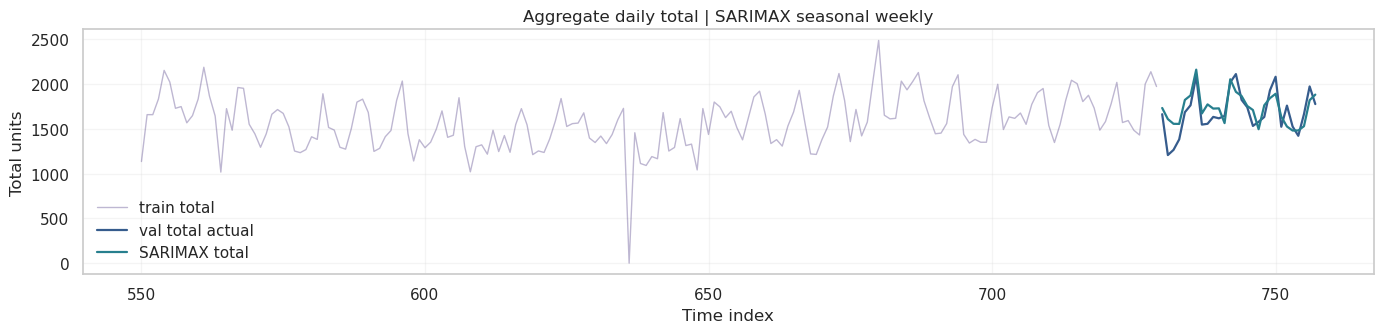

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,group,id,zero_share,baseline_RMSE,tree_RMSE,sarimax_RMSE,baseline_MAE,tree_MAE,sarimax_MAE
0,G1 low intermittency,FOODS_3_811_TX_3_validation,0.294960,10.487420,11.566472,10.013055,8.410714,8.223834,7.643282
1,G2 medium intermittency,FOODS_3_248_TX_3_validation,0.580371,0.736269,0.641968,0.673255,0.663265,0.542432,0.621971
2,G3 high intermittency,FOODS_3_031_TX_3_validation,0.754907,0.566947,0.633783,0.597862,0.525510,0.567556,0.509011
3,G4 very high intermittency,FOODS_3_262_TX_3_validation,0.894430,1.371633,1.578223,1.373047,0.823980,0.902675,0.774839


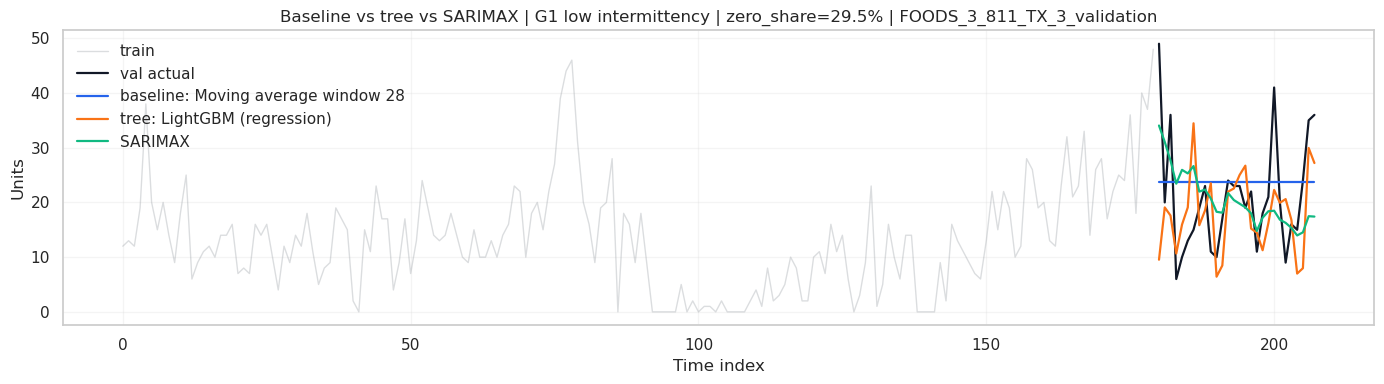

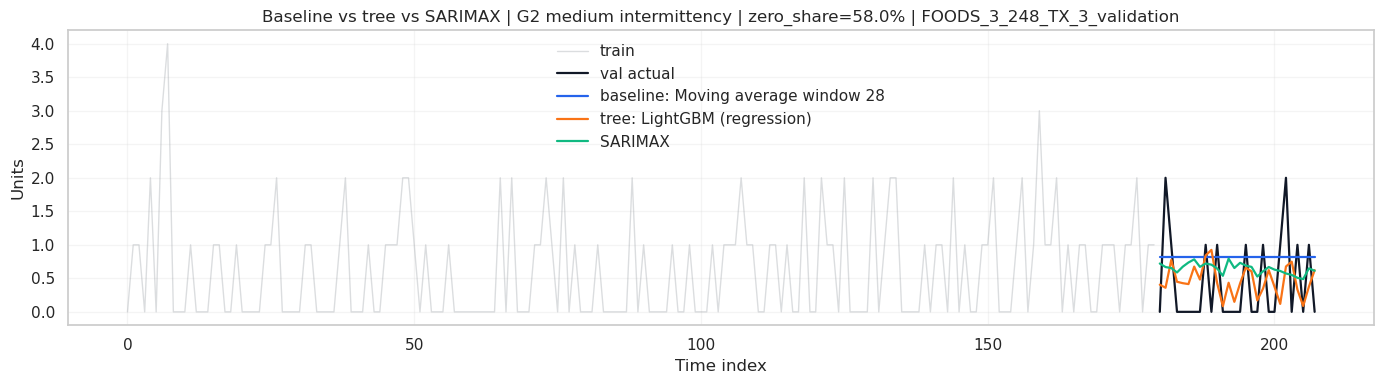

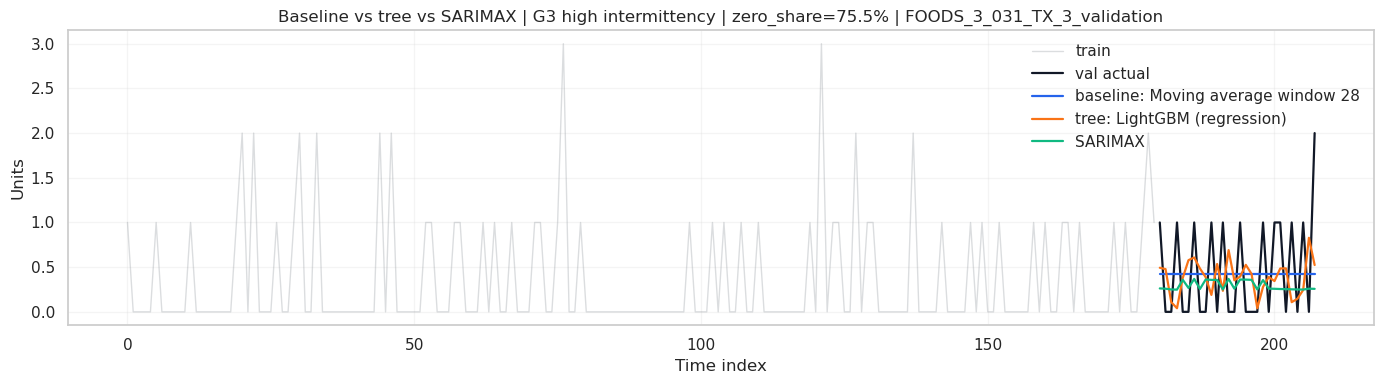

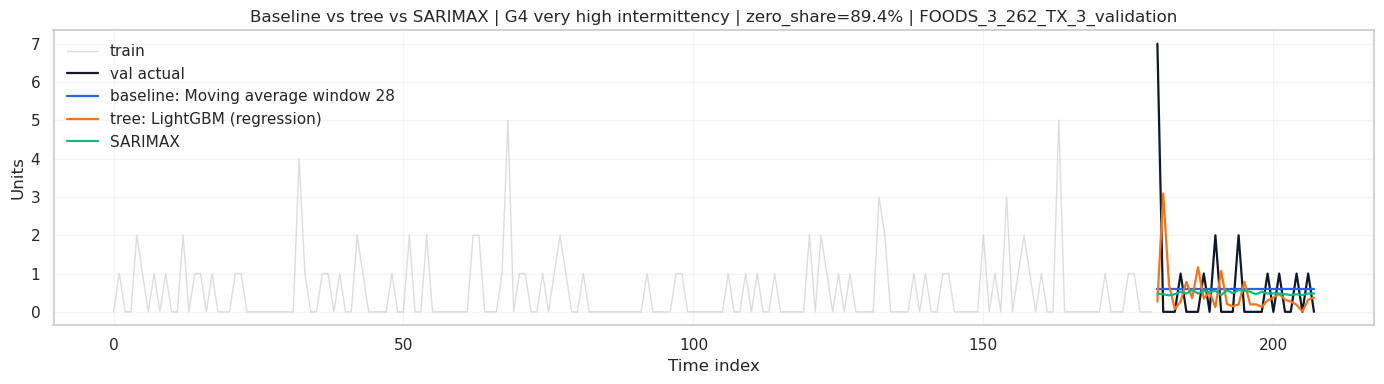

In [128]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

# ----------------------------
# Build helper: extract one series + exog on the exact train/val window
# ----------------------------
def get_item_train_val_long(sales_long: pd.DataFrame, item_id: str, cutoff: int, H: int, n_days: int = 730):
    df = sales_long[sales_long["id"] == item_id].copy()
    df = df.sort_values("d_index")

    # limit history for stability and runtime
    max_d = int(df["d_index"].max())
    min_d = max(1, max_d - (n_days + H) + 1)
    df = df[df["d_index"] >= min_d].copy()

    # exact split
    train = df[df["d_index"] <= cutoff].copy()
    val   = df[(df["d_index"] > cutoff) & (df["d_index"] <= cutoff + H)].copy()

    if len(val) != H:
        raise ValueError(f"{item_id}: val length is {len(val)} not H={H}. Check grid or missing rows.")

    return train, val

def build_exog(df: pd.DataFrame):
    # Keep exog simple and numeric to avoid fragile SARIMAX setups.
    # We use signals that exist in your feature table.
    ex = pd.DataFrame(index=df.index)

    ex["sell_price"] = pd.to_numeric(df["sell_price"], errors="coerce")
    ex["price_change"] = pd.to_numeric(df["price_change"], errors="coerce").fillna(0.0)
    ex["snap_TX"] = pd.to_numeric(df["snap_TX"], errors="coerce").fillna(0.0)

    # wday exists and is numeric (1..7). We keep it numeric.
    ex["wday"] = pd.to_numeric(df["wday"], errors="coerce")

    # Fill remaining holes defensively
    ex = ex.ffill().bfill()
    ex = ex.fillna(0.0)
    return ex

# ----------------------------
# SARIMAX config
# ----------------------------
# This is a reasonable starting point for daily demand with weekly seasonality.
# We keep it modest to reduce convergence issues.
ORDER = (1, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 7)

def fit_forecast_sarimax(y_train, ex_train, ex_future, H):
    # We allow non-stationary, non-invertible to reduce fit failures.
    model = SARIMAX(
        y_train,
        exog=ex_train,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=H, exog=ex_future)
    pred = fc.predicted_mean
    pred = np.asarray(pred, dtype=float)
    pred = np.maximum(pred, 0.0)
    return pred, res

# ----------------------------
# 1) Aggregate daily total SARIMAX (optional but useful)
# ----------------------------
# Aggregate sales and aggregate exog in the simplest consistent way:
# total units per day, and average sell_price/price_change + snap_TX for that day across items.
# This is not perfect economically, but it gives a clean seasonality sanity check.

def build_aggregate_series_and_exog(sales_long: pd.DataFrame, cutoff: int, H: int, n_days: int = 730):
    df = sales_long.copy()
    df = df.sort_values("d_index")

    max_d = int(df["d_index"].max())
    min_d = max(1, max_d - (n_days + H) + 1)
    df = df[df["d_index"] >= min_d].copy()

    agg = df.groupby("d_index").agg(
        sales_total=("sales", "sum"),
        sell_price_mean=("sell_price", "mean"),
        price_change_mean=("price_change", "mean"),
        snap_TX_mean=("snap_TX", "mean"),
        wday_mean=("wday", "mean"),
    ).reset_index()

    train = agg[agg["d_index"] <= cutoff].copy()
    val   = agg[(agg["d_index"] > cutoff) & (agg["d_index"] <= cutoff + H)].copy()

    y_train = train["sales_total"].astype(float).values
    y_val   = val["sales_total"].astype(float).values

    ex_train = train[["sell_price_mean", "price_change_mean", "snap_TX_mean", "wday_mean"]].astype(float).values
    ex_val   = val[["sell_price_mean", "price_change_mean", "snap_TX_mean", "wday_mean"]].astype(float).values

    return y_train, y_val, ex_train, ex_val, train, val

try:
    ytr_agg, yva_agg, xtr_agg, xva_agg, agg_train_df, agg_val_df = build_aggregate_series_and_exog(
        sales_long, cutoff=cutoff, H=H, n_days=730
    )
    agg_pred, _ = fit_forecast_sarimax(ytr_agg, xtr_agg, xva_agg, H)

    plt.figure(figsize=(14, 3.5))
    x_train = np.arange(len(ytr_agg))
    x_val   = np.arange(len(ytr_agg), len(ytr_agg) + len(yva_agg))

    plt.plot(x_train[-180:], ytr_agg[-180:], linewidth=1.0, alpha=0.35, label="train total")
    plt.plot(x_val, yva_agg, linewidth=1.6, label="val total actual")
    plt.plot(x_val, agg_pred, linewidth=1.6, label="SARIMAX total")

    plt.title("Aggregate daily total | SARIMAX seasonal weekly")
    plt.xlabel("Time index")
    plt.ylabel("Total units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Aggregate SARIMAX failed (not fatal):", repr(e))

# ----------------------------
# 2) SARIMAX on representative items (G1..G4)
# ----------------------------
sarimax_pred_wide = pd.DataFrame(index=val_wide.index, columns=val_wide.columns, dtype=float)

item_rows = []

for g, rid, zs in rep_items:
    train_i, val_i = get_item_train_val_long(sales_long, rid, cutoff=cutoff, H=H, n_days=730)

    y_train = train_i["sales"].astype(float).values
    y_val   = val_i["sales"].astype(float).values

    ex_train = build_exog(train_i)
    ex_val   = build_exog(val_i)

    try:
        pred, res = fit_forecast_sarimax(y_train, ex_train.values, ex_val.values, H)
    except Exception as e:
        print(f"SARIMAX failed for {rid} ({g}), fallback to seasonal naive for this item. Error:", repr(e))
        # fallback: seasonal naive 7 on this item (simple and safe)
        last_week = y_train[-7:] if len(y_train) >= 7 else np.repeat(y_train[-1], 7)
        pred = np.tile(last_week, int(np.ceil(H / 7)))[:H]
        pred = np.maximum(pred, 0.0)

    # Write predictions into the wide frame
    sarimax_pred_wide.loc[rid, :] = pred

    # Metrics for this item vs actual
    y_base = baseline_pred_wide.loc[rid, :].astype(float).values
    y_tree = tree_pred_wide.loc[rid, :].astype(float).values

    item_rows.append({
        "group": g,
        "id": rid,
        "zero_share": zs,
        "baseline_RMSE": rmse(y_val, y_base),
        "tree_RMSE": rmse(y_val, y_tree),
        "sarimax_RMSE": rmse(y_val, pred),
        "baseline_MAE": mae(y_val, y_base),
        "tree_MAE": mae(y_val, y_tree),
        "sarimax_MAE": mae(y_val, pred),
    })

sarimax_item_table = pd.DataFrame(item_rows)
display(sarimax_item_table)

# ----------------------------
# 3) Plots: baseline vs tree vs SARIMAX for each representative item
# ----------------------------
def plot_item_baseline_tree_sarimax(
    item_id: str,
    group_label: str,
    zs: float,
    tail: int = 180,
):
    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values
    pred_smx  = sarimax_pred_wide.loc[item_id].astype(float).values

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))

    # Consistent readable palette
    c_train  = "#9aa0a6"
    c_actual = "#111827"
    c_base   = "#2563eb"
    c_tree   = "#f97316"
    c_smx    = "#10b981"

    plt.plot(x_train, train_tail.values, color=c_train, linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val, y_val.values,       color=c_actual, linewidth=1.6, label="val actual")
    plt.plot(x_val, pred_base,          color=c_base, linewidth=1.6, label=f"baseline: {best_name}")
    plt.plot(x_val, pred_tree,          color=c_tree, linewidth=1.6, label=f"tree: {best_tree['model']}")
    plt.plot(x_val, pred_smx,           color=c_smx, linewidth=1.6, label="SARIMAX")

    plt.title(f"Baseline vs tree vs SARIMAX | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_item_baseline_tree_sarimax(rid, g, zs, tail=180)


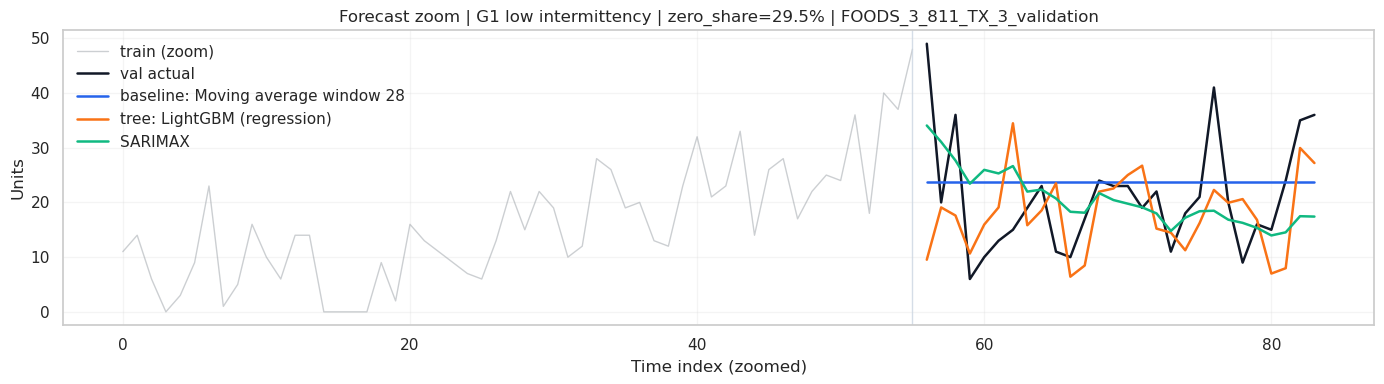

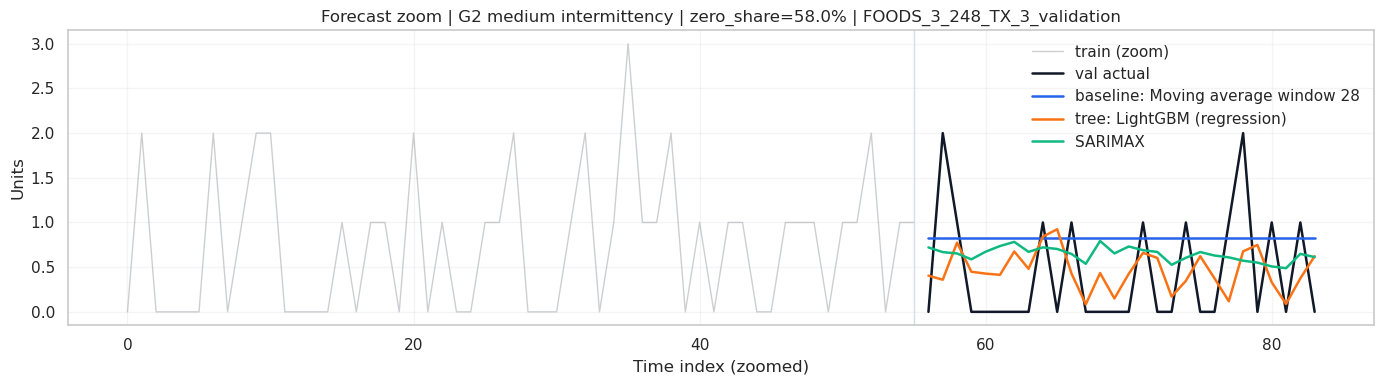

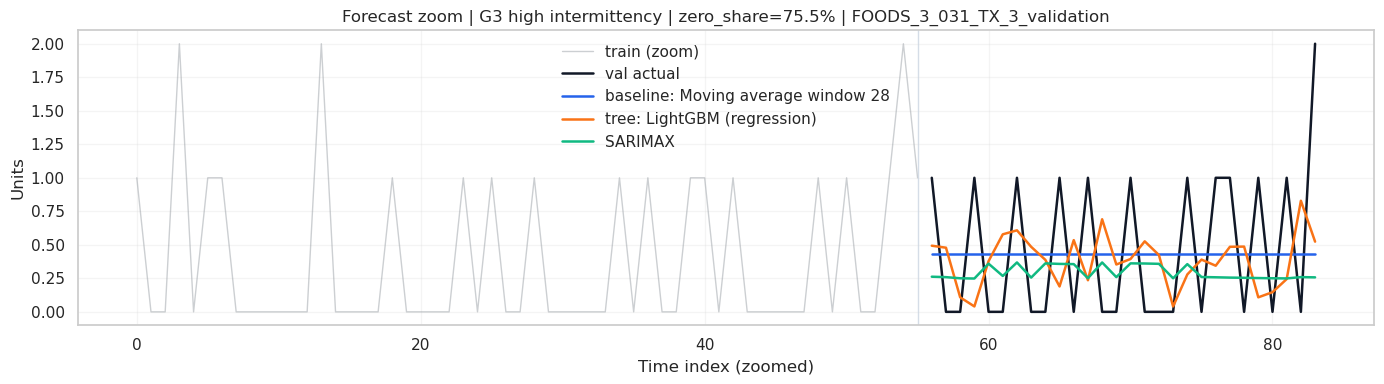

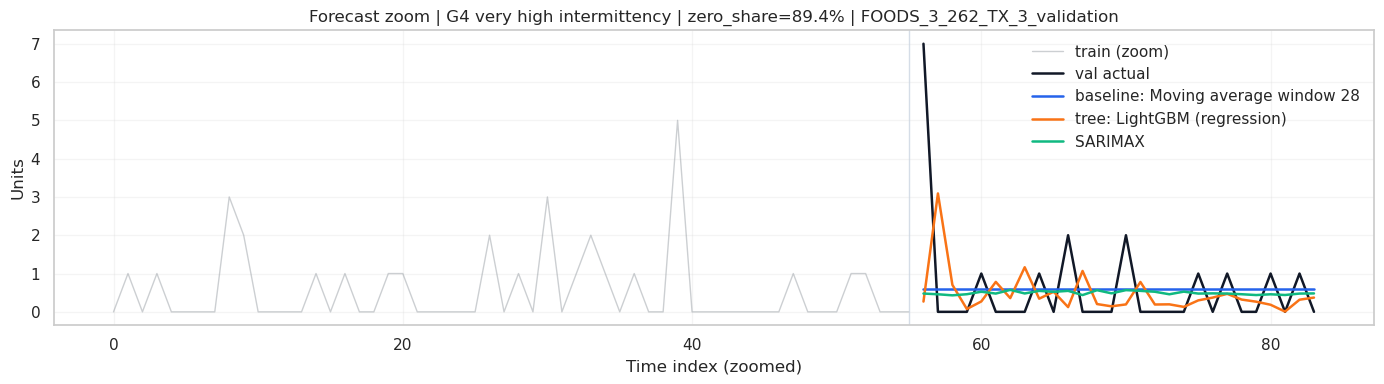

In [129]:
def plot_item_zoom_forecast(
    item_id: str,
    group_label: str,
    zs: float,
    zoom_train: int = 56,   # show 8 weeks before cutoff
):
    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values
    pred_smx  = sarimax_pred_wide.loc[item_id].astype(float).values

    # take last zoom_train days of train
    train_zoom = y_train.iloc[-zoom_train:]
    x_train = np.arange(len(train_zoom))
    x_val   = np.arange(len(train_zoom), len(train_zoom) + len(y_val))

    plt.figure(figsize=(14, 4))

    c_train  = "#9aa0a6"
    c_actual = "#111827"
    c_base   = "#2563eb"
    c_tree   = "#f97316"
    c_smx    = "#10b981"

    plt.plot(x_train, train_zoom.values, color=c_train, linewidth=1.0, alpha=0.5, label="train (zoom)")
    plt.plot(x_val,   y_val.values,      color=c_actual, linewidth=1.8, label="val actual")
    plt.plot(x_val,   pred_base,         color=c_base, linewidth=1.8, label=f"baseline: {best_name}")
    plt.plot(x_val,   pred_tree,         color=c_tree, linewidth=1.8, label=f"tree: {best_tree['model']}")
    plt.plot(x_val,   pred_smx,          color=c_smx, linewidth=1.8, label="SARIMAX")

    plt.axvline(x=len(train_zoom)-1, color="#cbd5e1", linewidth=1.0, alpha=0.8)  # cutoff marker

    plt.title(f"Forecast zoom | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index (zoomed)")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_item_zoom_forecast(rid, g, zs, zoom_train=56)


## Bonus benchmark: MSTL + ARIMA (multiple seasonal decomposition)

SARIMAX models weekly seasonality directly via a seasonal ARMA structure (period 7).  
As an alternative, we test **MSTL** (Multiple Seasonal-Trend decomposition) with two seasonalities:

- **7-day** weekly seasonality  
- **28-day** medium-term cycle (tested as a hypothesis, not assumed to be real)

We decompose the training series into **trend + seasonal_7 + seasonal_28 + residual**.  
Then we fit a **non-seasonal ARIMA** model on the residual component and forecast the next 28 days.

Important caveat: MSTL is primarily a decomposition method; forecasting requires assumptions about how trend and seasonal components extend into the future. We use a simple, transparent extension rule and treat this benchmark as exploratory.


In [130]:
import numpy as np
import pandas as pd

def _safe_last_non_nan(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    mask = ~np.isnan(x)
    if not mask.any():
        return 0.0
    return float(x[mask][-1])

def _trend_forecast_linear(trend: np.ndarray, steps: int, slope_window: int = 14) -> np.ndarray:
    """
    Simple trend extrapolation:
    - take last non-NaN trend value
    - estimate slope from last `slope_window` differences (nan-robust)
    """
    trend = np.asarray(trend, dtype=float)
    # fill NaNs for slope estimation
    s = pd.Series(trend).interpolate(limit_direction="both").values

    last = float(s[-1])
    diffs = np.diff(s[-(slope_window + 1):])
    diffs = diffs[~np.isnan(diffs)]
    slope = float(np.mean(diffs)) if len(diffs) > 0 else 0.0

    h = np.arange(1, steps + 1, dtype=float)
    return last + slope * h

def _seasonal_forecast_repeat(seasonal: np.ndarray, period: int, steps: int) -> np.ndarray:
    """
    Repeat the last full seasonal cycle forward.
    If seasonal is too short, fall back to zeros.
    """
    seasonal = np.asarray(seasonal, dtype=float)
    if len(seasonal) < period:
        return np.zeros(steps, dtype=float)

    pattern = seasonal[-period:]  # aligns phase for the next step
    reps = int(np.ceil(steps / period))
    out = np.tile(pattern, reps)[:steps]
    out = np.where(np.isnan(out), 0.0, out)
    return out

def mstl_arima_forecast(y_train: np.ndarray, steps: int = 28, periods=(7, 28), arima_candidates=None,
                        nonneg_clip: bool = True):
    """
    MSTL decomposition (trend + multiple seasonals) + non-seasonal ARIMA on residuals.

    Returns:
    - yhat: forecast of length `steps`
    - meta: dict with model details (decomposition method used, ARIMA order)
    """
    y = np.asarray(y_train, dtype=float)

    if arima_candidates is None:
        arima_candidates = [(1,0,0), (0,0,1), (1,0,1), (2,0,1), (1,0,2)]

    # Try MSTL if available; else fallback to sequential STL
    decomp_method = None
    trend = None
    seasonals = {}  # period -> seasonal component
    resid = None

    try:
        from statsmodels.tsa.seasonal import MSTL
        res = MSTL(y, periods=list(periods)).fit()
        decomp_method = "MSTL"

        # trend
        trend = np.asarray(res.trend, dtype=float)

        # seasonal can be (n, k) array-like; handle both DataFrame/ndarray robustly
        seas = res.seasonal
        if isinstance(seas, pd.DataFrame):
            seas_arr = seas.values
        else:
            seas_arr = np.asarray(seas, dtype=float)
        # Ensure 2D (MSTL may return 1D if only one seasonal)
        if seas_arr.ndim == 1:
            seas_arr = seas_arr[:, None]
        # Defensive: align to provided periods
        if seas_arr.shape[1] < len(periods):
            raise ValueError(
                f"MSTL seasonal component has {seas_arr.shape[1]} cols but {len(periods)} periods were requested"
            )

        # Map columns to periods in order
        for j, p in enumerate(periods):
            seasonals[int(p)] = seas_arr[:, j].astype(float)

        resid = np.asarray(res.resid, dtype=float)

    except Exception as e:
        # Fallback: sequential STL (first 7, then 28 on the remainder)
        decomp_method = f"STL_fallback ({type(e).__name__})"
        from statsmodels.tsa.seasonal import STL

        y0 = pd.Series(y).interpolate(limit_direction="both").values

        # weekly
        stl7 = STL(y0, period=int(periods[0]), robust=True).fit()
        seasonals[int(periods[0])] = np.asarray(stl7.seasonal, dtype=float)

        # remove weekly to estimate the slower cycle
        rem = y0 - seasonals[int(periods[0])]
        stl28 = STL(rem, period=int(periods[1]), robust=True).fit()
        seasonals[int(periods[1])] = np.asarray(stl28.seasonal, dtype=float)

        # trend from second pass is our trend proxy
        trend = np.asarray(stl28.trend, dtype=float)

        # residual = remainder after removing trend + both seasonals
        resid = y0 - trend - seasonals[int(periods[0])] - seasonals[int(periods[1])]

    # Forecast components
    trend_f = _trend_forecast_linear(trend, steps=steps, slope_window=14)

    seasonal_f_sum = np.zeros(steps, dtype=float)
    for p in periods:
        seasonal_f_sum += _seasonal_forecast_repeat(seasonals[int(p)], period=int(p), steps=steps)

    # Fit ARIMA on residuals
    from statsmodels.tsa.arima.model import ARIMA

    resid_series = pd.Series(resid).interpolate(limit_direction="both").values

    arima_order_used = None
    resid_fc = None
    last_err = None

    for order in arima_candidates:
        try:
            model = ARIMA(resid_series, order=order)
            fit = model.fit()
            resid_fc = np.asarray(fit.forecast(steps=steps), dtype=float)
            arima_order_used = order
            break
        except Exception as err:
            last_err = err
            continue

    if resid_fc is None:
        # If ARIMA fails entirely, default to zero residual forecast
        resid_fc = np.zeros(steps, dtype=float)
        arima_order_used = ("FAILED", str(last_err)[:120])

    yhat = trend_f + seasonal_f_sum + resid_fc

    if nonneg_clip:
        yhat = np.maximum(0.0, yhat)

    meta = {
        "decomp_method": decomp_method,
        "periods": tuple(periods),
        "arima_order": arima_order_used,
    }
    return yhat, meta


,series,baseline_RMSE,tree_RMSE,mstl_arima_RMSE,baseline_MAE,tree_MAE,mstl_arima_MAE,mstl_meta
0,AGG_TOTAL,235.449061,376.332611,372.888269,191.163265,292.203863,330.230742,"{'decomp_method': 'MSTL', 'periods': (7, 28), ..."


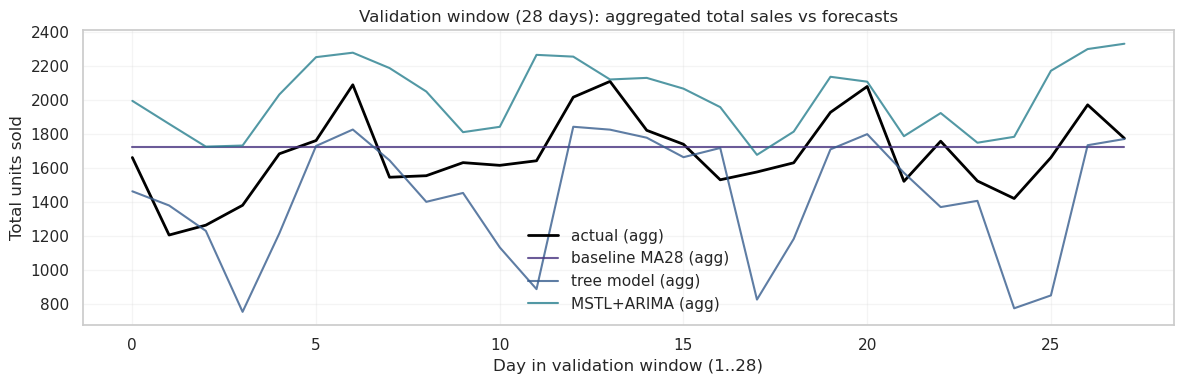

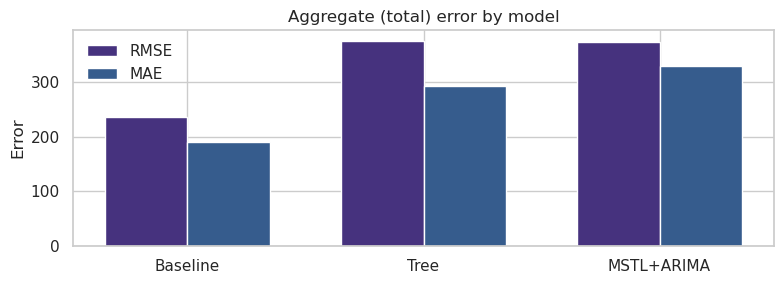

In [131]:
H = val_wide.shape[1]  # 28

# Aggregate series (guard against non-numeric columns like id)
d_cols_train = [c for c in train_wide.columns if c.startswith("d_")]
d_cols_val   = list(val_wide.columns)  # val_wide already only d_ cols

# Sum totals per day
y_train_total = train_wide[d_cols_train].astype(float).sum(axis=0).values
y_val_total   = val_wide[d_cols_val].astype(float).sum(axis=0).values

base_total = baseline_pred_wide[d_cols_val].astype(float).sum(axis=0).values
tree_total = tree_pred_wide[d_cols_val].astype(float).sum(axis=0).values

mstl_total, mstl_meta_total = mstl_arima_forecast(y_train_total, steps=H, periods=(7, 28))

agg_metrics = pd.DataFrame([{
    "series": "AGG_TOTAL",
    "baseline_RMSE": float(np.sqrt(np.mean((y_val_total - base_total) ** 2))),
    "tree_RMSE": float(np.sqrt(np.mean((y_val_total - tree_total) ** 2))),
    "mstl_arima_RMSE": float(np.sqrt(np.mean((y_val_total - mstl_total) ** 2))),
    "baseline_MAE": float(np.mean(np.abs(y_val_total - base_total))),
    "tree_MAE": float(np.mean(np.abs(y_val_total - tree_total))),
    "mstl_arima_MAE": float(np.mean(np.abs(y_val_total - mstl_total))),
    "mstl_meta": mstl_meta_total,
}])

display(agg_metrics)


# --- Visual comparison: aggregated totals ---
plt.figure(figsize=(12, 4))
plt.plot(y_val_total, label="actual (agg)", color="black", linewidth=2)
plt.plot(base_total, label="baseline MA28 (agg)", alpha=0.8)
plt.plot(tree_total, label="tree model (agg)", alpha=0.8)
plt.plot(mstl_total, label="MSTL+ARIMA (agg)", alpha=0.8)
plt.title("Validation window (28 days): aggregated total sales vs forecasts")
plt.xlabel("Day in validation window (1..28)")
plt.ylabel("Total units sold")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Bar chart of RMSE/MAE for the aggregate series ---
plt.figure(figsize=(8, 3))
labels = ["Baseline", "Tree", "MSTL+ARIMA"]
rmse_vals = [agg_metrics["baseline_RMSE"].iloc[0],
             agg_metrics["tree_RMSE"].iloc[0],
             agg_metrics["mstl_arima_RMSE"].iloc[0]]
mae_vals = [agg_metrics["baseline_MAE"].iloc[0],
            agg_metrics["tree_MAE"].iloc[0],
            agg_metrics["mstl_arima_MAE"].iloc[0]]

x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, rmse_vals, width, label="RMSE")
plt.bar(x + width/2, mae_vals,  width, label="MAE")
plt.xticks(x, labels)
plt.ylabel("Error")
plt.title("Aggregate (total) error by model")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Aggregate benchmark discussion
- MSTL+ARIMA provides an interpretable seasonal/trend baseline. At the aggregate level we expect it to land between the simple moving-average baseline and the tree models when weekly seasonality dominates.
- If MSTL underperforms the tree, nonlinear lag/price effects matter even in the aggregate; if it matches or beats the tree, aggregate demand is mostly seasonal/trend-driven and benefits from explicit decomposition.
- A big gap between the MA baseline and MSTL means weekly/longer cycles are important; a small gap means recent level dominates.
- In the line plot: persistent over/under-shoot hints at bias; phase-shifted crossings hint at misaligned seasonality.
- The RMSE/MAE bars tell whether to keep MSTL as a reporting-only benchmark or as a guardrail for aggregate bias.


## SARIMAX case-study results (representative items)

We fit SARIMAX only for the aggregate series and four representative items (G1–G4).  
**important**: comparison: SARIMAX is fitted per-series, while the tree model is pooled across all items.

### What we see
- **G1 (low intermittency / higher volume):** SARIMAX and the tree model both track short-term dynamics better than the moving-average baseline. Errors are larger in absolute terms because this item’s scale is much higher, so missing a spike costs more in RMSE.
- **G2 (medium intermittency):** the tree model tends to be strongest, with SARIMAX close but not consistently better.
- **G3–G4 (high intermittency):** none of the models truly “solve” long zero stretches. SARIMAX often produces smooth forecasts that drift above zero; the tree model does the same when lags indicate recent sales. MAE can improve while RMSE does not (or vice versa) depending on whether occasional spikes dominate the error.

### Why these SARIMAX scores cannot be directly compared to H1/H2 tables
H1/H2 evaluate **all 823 items × 28 days**.  
The SARIMAX table evaluates **only 4 items**. It answers a different question:
“On a few representative series, does a classical time-series model provide a competitive benchmark?”

### Practical take-away
- SARIMAX is most defensible on the **aggregate series** and on **low-intermittency items** (stable level + weekly structure).
- For intermittent items, a pooled model with lag/price/calendar features is still the better main approach, but it likely needs **zero-aware handling** to reduce overprediction on long zero runs.


## Feature engineering for intermittent demand

The pooled tree model improves over baselines, but performance remains weakest for highly intermittent series (long stretches of zeros with occasional spikes).  
Single lags (`lag_1`, `lag_7`, `lag_28`) help, but they do not fully capture:

1. **Recent level** (is the item currently “active” or “quiet”?)  
2. **Persistence of zeros** (how long since the last non-zero sale?)  
3. **Short-term vs medium-term regime** (last week vs last month)

To address this, we extend the feature set with **rolling statistics** computed *per item* using only past information:

- Rolling mean of sales over the previous 7 and 28 days  
- Rolling zero-share over the previous 28 days (intermittency in the recent window)  
- Time since last sale (a simple “zero-run length” signal)

These features are designed specifically to reduce systematic overprediction during long zero stretches, while still allowing spikes when recent activity suggests demand.


In [133]:
import numpy as np
import pandas as pd

df = sales_long.sort_values(["id", "d_index"]).copy()

# rolling means of sales (past only)
df["roll_mean_7"]  = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(7).mean())
df["roll_mean_28"] = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(28).mean())

# rolling zero-share (past only)
df["roll_zero_share_28"] = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(28).apply(lambda x: np.mean(x==0), raw=True))

# time since last sale (past only)
def time_since_last_sale(s):
    last = -1
    out = np.empty(len(s), dtype=float)
    for i, v in enumerate(s.values):
        out[i] = (i - last) if last != -1 else np.nan
        if v > 0:
            last = i
    return pd.Series(out, index=s.index)

df["time_since_sale"] = df.groupby("id")["sales"].apply(time_since_last_sale).reset_index(level=0, drop=True)

sales_long = df 

## Feature pruning for a simpler, more stable tree model

Permutation importance suggests that predictive performance is driven primarily by **lag-based demand history**, while several calendar/event variables contribute little or nothing in the current validation window.

We therefore run a pruning experiment:

- Keep the features that consistently matter (lags + key calendar/price signals)
- Drop near-zero-importance or constant features (event strings, missing-price flag, and other low-signal fields)
- Refit the best-performing tree model and re-evaluate on the same 28-day hold-out

Goal: verify whether removing weak features improves generalization and reduces noise, without sacrificing accuracy.


In [134]:

# ----------------------------
# Exact-grid train/val long tables (aligned to baseline item universe)
# ----------------------------
H = 28
val_days = list(range(cutoff + 1, cutoff + H + 1))

train_long_exact = sales_long[
    (sales_long["d_index"] <= cutoff) &
    (sales_long["id"].isin(train_wide.index))
].copy()

val_long_exact = sales_long[
    (sales_long["d_index"].isin(val_days)) &
    (sales_long["id"].isin(val_wide.index))
].copy()

# drop rows where lags not available
train_long_exact = train_long_exact.dropna(subset=["lag_1", "lag_7", "lag_28"])
val_long_exact   = val_long_exact.dropna(subset=["lag_1", "lag_7", "lag_28"])

# hard sanity check: we need a full (id x 28) grid in val_long_exact
expected = len(val_wide.index) * H
got = len(val_long_exact)
if got != expected:
    all_pairs = pd.MultiIndex.from_product([val_wide.index, val_days], names=["id", "d_index"])
    have_pairs = pd.MultiIndex.from_frame(val_long_exact[["id", "d_index"]])
    missing = all_pairs.difference(have_pairs)
    raise ValueError(f"val_long_exact incomplete: expected={expected}, got={got}, missing={len(missing)}. Example missing={list(missing[:10])}")

# fill categorical missings
def fill_cats(df, cat_cols):
    for c in cat_cols:
        df[c] = df[c].fillna("none").astype(str)
    return df

# ----------------------------
# Evaluation helper: fit model, predict val_long_exact, pivot to val_wide grid, score RMSE/MAE
# ----------------------------
def fit_eval_tree_on_grid(model_name, estimator, num_cols, cat_cols):
    feature_cols = num_cols + cat_cols

    tr = train_long_exact.copy()
    va = val_long_exact.copy()
    tr = fill_cats(tr, cat_cols)
    va = fill_cats(va, cat_cols)

    X_train = tr[feature_cols]
    y_train = tr["sales"].astype(float).values

    X_val = va[feature_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ],
        remainder="drop",
    )

    pipe = Pipeline(steps=[("prep", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)

    pred_long = pipe.predict(X_val)
    pred_long = np.maximum(pred_long, 0.0)

    pred_df = va[["id", "d_index"]].copy()
    pred_df["pred"] = pred_long

    pred_wide = pred_df.pivot(index="id", columns="d_index", values="pred")
    pred_wide.columns = [f"d_{int(c)}" for c in pred_wide.columns]
    pred_wide = pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

    n_missing = int(pred_wide.isna().sum().sum())
    if n_missing:
        raise ValueError(f"{model_name}: pred_wide has {n_missing} missing cells after reindexing.")

    Y_true = val_wide.to_numpy(dtype=float)
    Y_pred = pred_wide.to_numpy(dtype=float)

    return {
        "model": model_name,
        "RMSE": rmse(Y_true, Y_pred),
        "MAE": mae(Y_true, Y_pred),
        "pipe": pipe,
        "Y_pred_wide": pred_wide,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
    }

# ----------------------------
# Feature sets: FULL vs PRUNED vs LAGS-ONLY
# ----------------------------
# FULL (what we used in the main tree run)
NUM_FULL = ["lag_1","lag_7","lag_28","sell_price","price_change","sell_price_was_missing","wday","month","year","snap_TX"]
CAT_FULL = ["weekday","event_name_1","event_type_1","event_name_2","event_type_2"]

# PRUNED (based on your permutation importance)
NUM_PRUNED = ["lag_1","lag_7","lag_28","sell_price","price_change","wday","month","snap_TX"]
CAT_PRUNED = ["weekday"]

# PRUNED v2 (even stricter: drop month)
NUM_PRUNED2 = ["lag_1","lag_7","lag_28","sell_price","price_change","wday","snap_TX"]
CAT_PRUNED2 = ["weekday"]

# LAGS ONLY (ablation baseline inside ML)
NUM_LAGS = ["lag_1","lag_7","lag_28"]
CAT_LAGS = []

if not HAS_LGB:
    raise RuntimeError("LightGBM not available in this environment.")

# consistent LightGBM config
lgb_cfg = dict(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="regression",
)

results = []
results.append(fit_eval_tree_on_grid("LightGBM FULL",   LGBMRegressor(**lgb_cfg), NUM_FULL,   CAT_FULL))
results.append(fit_eval_tree_on_grid("LightGBM PRUNED", LGBMRegressor(**lgb_cfg), NUM_PRUNED, CAT_PRUNED))
results.append(fit_eval_tree_on_grid("LightGBM PRUNED2",LGBMRegressor(**lgb_cfg), NUM_PRUNED2,CAT_PRUNED2))
results.append(fit_eval_tree_on_grid("LightGBM LAGS",   LGBMRegressor(**lgb_cfg), NUM_LAGS,   CAT_LAGS))

results_table = pd.DataFrame([{k:v for k,v in r.items() if k in ["model","RMSE","MAE"]} for r in results]).sort_values("RMSE").reset_index(drop=True)
display(results_table)

best_tree = results[results_table.index[0]]
print("Best (by RMSE):", results_table.loc[0,"model"])

# H1 vs baseline
print("\nH1 conclusion on the 28-day hold-out (all items)")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")
print(f"Best tree    : {results_table.loc[0,'model']} | RMSE={results_table.loc[0,'RMSE']:.4f} | MAE={results_table.loc[0,'MAE']:.4f}")

rmse_imp = best_baseline_rmse - float(results_table.loc[0,"RMSE"])
mae_imp  = best_baseline_mae  - float(results_table.loc[0,"MAE"])
print(f"Improvement (baseline - tree): RMSE={rmse_imp:.4f} ({rmse_imp/best_baseline_rmse:.1%}) | MAE={mae_imp:.4f} ({mae_imp/best_baseline_mae:.1%})")


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,RMSE,MAE
0,LightGBM PRUNED,2.378670,1.246410
1,LightGBM PRUNED2,2.380040,1.247475
2,LightGBM FULL,2.393822,1.259260
3,LightGBM LAGS,2.454797,1.264479


Best (by RMSE): LightGBM PRUNED

H1 conclusion on the 28-day hold-out (all items)
Best baseline: Moving average window 28 | RMSE=2.8012 | MAE=1.3468
Best tree    : LightGBM PRUNED | RMSE=2.3787 | MAE=1.2464
Improvement (baseline - tree): RMSE=0.4225 (15.1%) | MAE=0.1004 (7.5%)


## Tree model selection and pruning results

We compare several LightGBM variants on the same 28-day hold-out window used for baselines.

**Key finding:** a pruned feature set performs best.  
`LightGBM PRUNED` achieves RMSE 2.379 and MAE 1.246, outperforming both the full feature set and a lags-only model.

This suggests:

- **Lag features are the dominant signal** (removing them degrades performance).
- **Calendar/price features add incremental value**, since PRUNED beats LAGS.
- Several variables (event strings, missing-price flag, etc.) add noise or are redundant under this evaluation, so removing them improves generalization.

### H1 conclusion (baseline vs best tree)

The best baseline is a 28-day moving average (RMSE 2.801, MAE 1.347).  
The best tree model (`LightGBM PRUNED`) improves performance to RMSE 2.379 and MAE 1.246.

This corresponds to an improvement of **15.1% in RMSE** and **7.5% in MAE**, supporting H1: a pooled tree model using lag, calendar, and price signals outperforms simple rule-based extrapolation on the same hold-out window.


## H2: Baseline vs PRUNED tree by intermittency group (same grid)



,group,n_items,zero_share_mean,baseline_RMSE,tree_RMSE,RMSE_improvement,baseline_MAE,tree_MAE,MAE_improvement
0,G1 low intermittency,206,0.275491,4.754558,3.827894,0.926664,2.638288,2.210383,0.427904
1,G2 medium intermittency,206,0.573104,2.392809,2.275909,0.116900,1.353985,1.336800,0.017185
2,G3 high intermittency,205,0.749946,1.399477,1.324520,0.074957,0.827501,0.821458,0.006043
3,G4 very high intermittency,206,0.895138,1.033728,1.013138,0.020589,0.564952,0.614936,-0.049984


Tree used for H2: LightGBM PRUNED


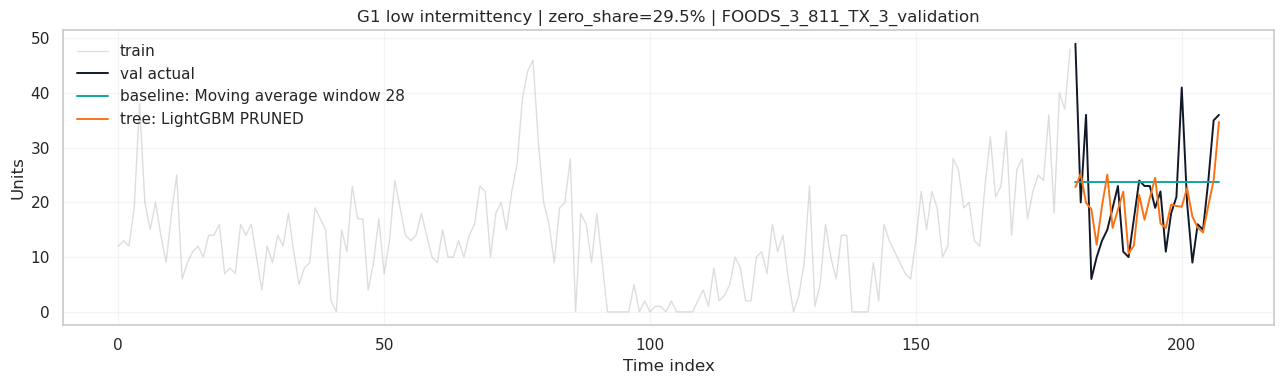

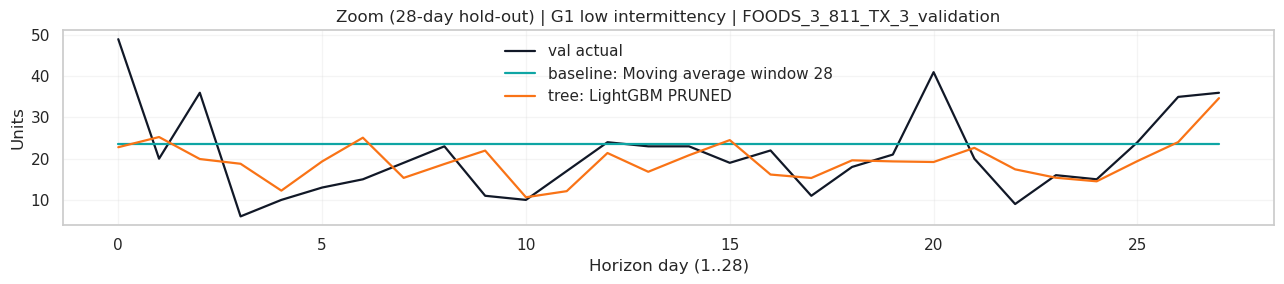

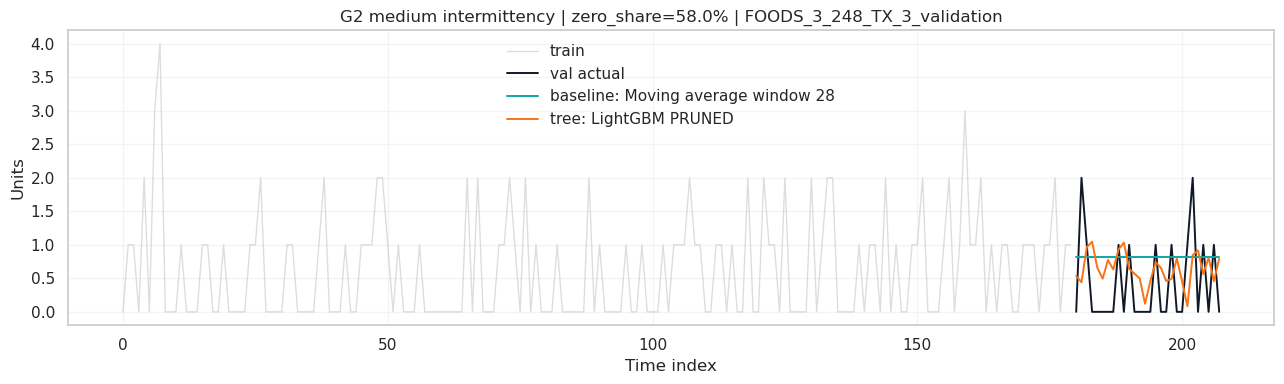

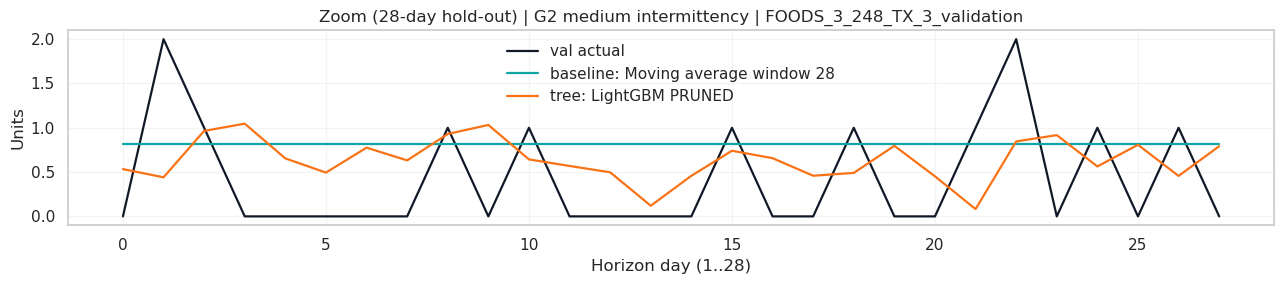

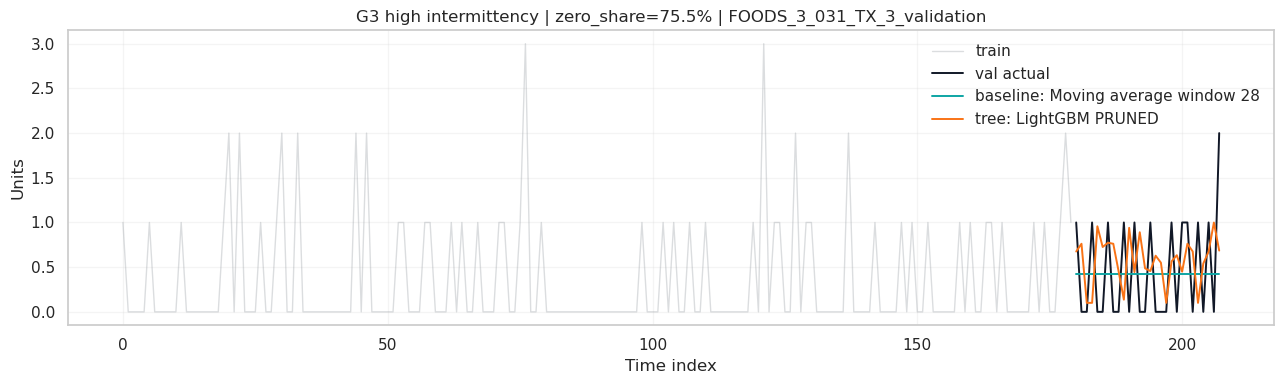

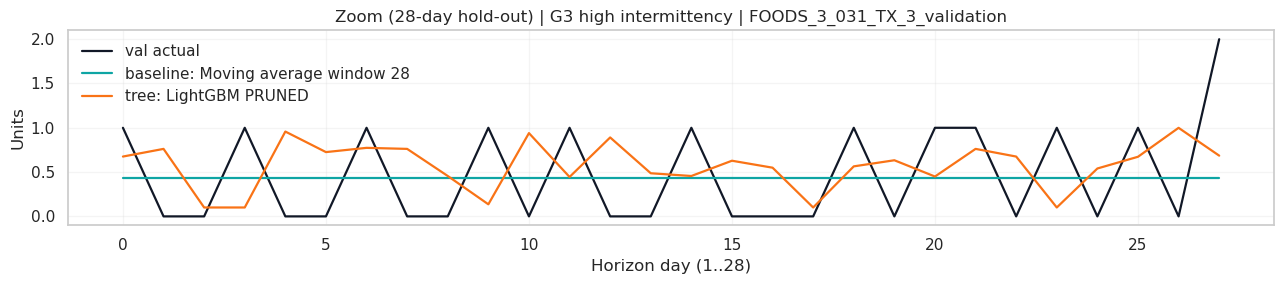

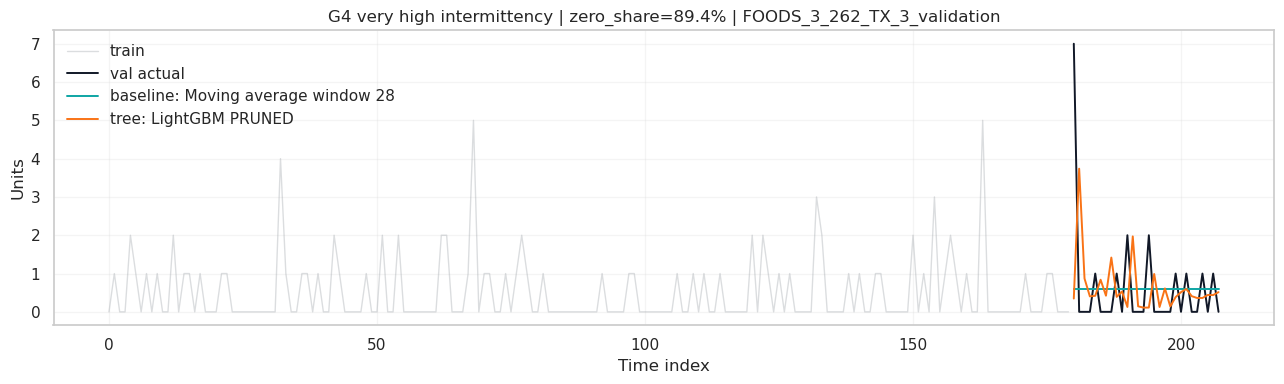

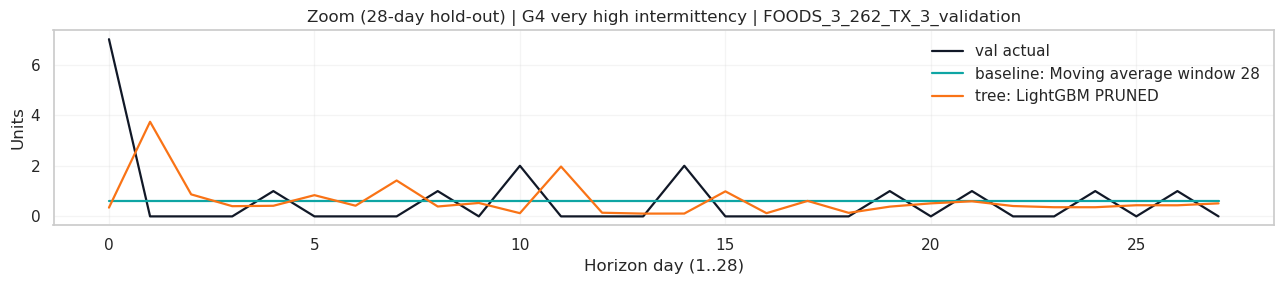

In [135]:
# H2: Baseline vs PRUNED tree by intermittency group (same grid)
# ---------------------------------------

# Baseline preds as wide DF on the baseline grid
baseline_pred_wide = pd.DataFrame(best_pred, index=val_wide.index, columns=val_wide.columns).clip(lower=0.0)

# Fetch PRUNED model prediction matrix from results
# We pick the entry whose name contains "PRUNED" (adjust if you renamed differently)
candidates = [r for r in results if "PRUNED" in r["model"].upper()]
if len(candidates) == 0:
    raise ValueError("No PRUNED model found in `results`. Print [r['model'] for r in results] to see names.")
# If you have both PRUNED and PRUNED2, pick the one with lowest RMSE
best_tree = min(candidates, key=lambda r: r["RMSE"])
best_tree_name = best_tree["model"]

# Tree preds must be on the SAME (id x d_####) grid as val_wide
tree_pred_wide = best_tree["Y_pred_wide"].copy()
tree_pred_wide = tree_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

# Hard stop if alignment is broken (prevents silent NaNs)
missing_tree = int(tree_pred_wide.isna().sum().sum())
if missing_tree > 0:
    raise ValueError(f"{best_tree_name}: tree_pred_wide has {missing_tree} NaN cells after alignment. Fix val_long_exact grid.")

tree_pred_wide = tree_pred_wide.clip(lower=0.0)

Y_true = val_wide.to_numpy(dtype=float)
Y_base = baseline_pred_wide.to_numpy(dtype=float)
Y_tree = tree_pred_wide.to_numpy(dtype=float)

group_order = ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]

rows = []
for g in group_order:
    idx = np.where(groups.values == g)[0]

    base_rmse_g = rmse(Y_true[idx, :], Y_base[idx, :])
    base_mae_g  = mae(Y_true[idx, :], Y_base[idx, :])

    tree_rmse_g = rmse(Y_true[idx, :], Y_tree[idx, :])
    tree_mae_g  = mae(Y_true[idx, :], Y_tree[idx, :])

    rows.append({
        "group": g,
        "n_items": int(len(idx)),
        "zero_share_mean": float(zero_share[groups == g].mean()),
        "baseline_RMSE": base_rmse_g,
        "tree_RMSE": tree_rmse_g,
        "RMSE_improvement": base_rmse_g - tree_rmse_g,
        "baseline_MAE": base_mae_g,
        "tree_MAE": tree_mae_g,
        "MAE_improvement": base_mae_g - tree_mae_g,
    })

h2_pruned = pd.DataFrame(rows)
display(h2_pruned)

print("Tree used for H2:", best_tree_name)

# ---------------------------------------
# Representative plots: baseline vs PRUNED on the same figure
# Includes a zoomed view of the 28-day forecast window
# ---------------------------------------

def plot_rep_item_baseline_tree_zoom(item_id: str, group_label: str, zs: float, tail: int = 180):
    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    # Full context plot
    plt.figure(figsize=(13, 4))
    plt.plot(x_train, train_tail.values, color="#9aa0a6", linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val, y_val.values,       color="#111827", linewidth=1.4, label="val actual")
    plt.plot(x_val, pred_base,          color="#0ea5a4", linewidth=1.4, label=f"baseline: {best_name}")
    plt.plot(x_val, pred_tree,          color="#f97316", linewidth=1.4, label=f"tree: {best_tree_name}")
    plt.title(f"{group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Zoom plot: forecast window only
    plt.figure(figsize=(13, 3))
    plt.plot(np.arange(len(y_val)), y_val.values,  color="#111827", linewidth=1.6, label="val actual")
    plt.plot(np.arange(len(y_val)), pred_base,     color="#0ea5a4", linewidth=1.6, label=f"baseline: {best_name}")
    plt.plot(np.arange(len(y_val)), pred_tree,     color="#f97316", linewidth=1.6, label=f"tree: {best_tree_name}")
    plt.title(f"Zoom (28-day hold-out) | {group_label} | {item_id}")
    plt.xlabel("Horizon day (1..28)")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_rep_item_baseline_tree_zoom(rid, g, zs, tail=180)

## SARIMAX benchmark (classical time series baseline)

We add **SARIMAX** as an interpretable classical time-series benchmark to complement the pooled tree model.

Why we include this:
- Our **tree model (LightGBM PRUNED)** is trained *across items* and learns from lag signals and a small set of exogenous drivers.
- **SARIMAX** is fitted *per series* and explicitly models autocorrelation and **weekly seasonality** (period 7).
- SARIMAX is most defensible for **aggregated demand** and **low-intermittency items**. For highly intermittent series (many zeros), SARIMAX is not expected to work well without a zero-inflated / hurdle mechanism.

What we evaluate:
1. **Aggregate daily total series**  
   This is the best-case setting for SARIMAX: noise averages out and weekly seasonality should be visible.
2. **Representative items from intermittency groups (G1–G4)**  
   We fit one SARIMAX model per representative item using the same training window and score the same 28-day hold-out.  
   The purpose here is *qualitative*: to observe model behavior across intermittency regimes, not to claim SARIMAX is best overall across all items.

Specification used:
- SARIMAX order = (1, 0, 1)
- seasonal_order = (1, 0, 1, 7)
- Exogenous regressors (kept numeric and simple): **sell_price**, **price_change**, **snap_TX**, **wday**

Important limitation:
Statsmodels may emit `ConvergenceWarning` for some series. This means the likelihood optimizer did not fully converge, so SARIMAX should be interpreted as an approximate benchmark rather than a production-ready model in this setup.


AGG_TOTAL SARIMAX spec used: ((1, 0, 1), (1, 0, 1, 7))


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,series,baseline_RMSE,tree_RMSE,sarimax_RMSE,baseline_MAE,tree_MAE,sarimax_MAE,sarimax_spec
0,AGG_TOTAL,235.449061,131.709743,177.03334,191.163265,104.38143,142.212099,"((1, 0, 1), (1, 0, 1, 7))"


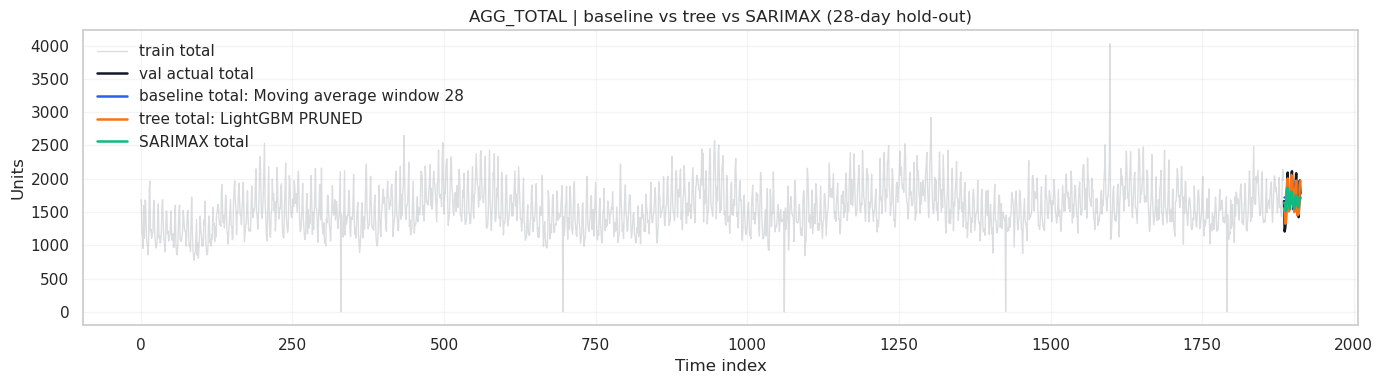

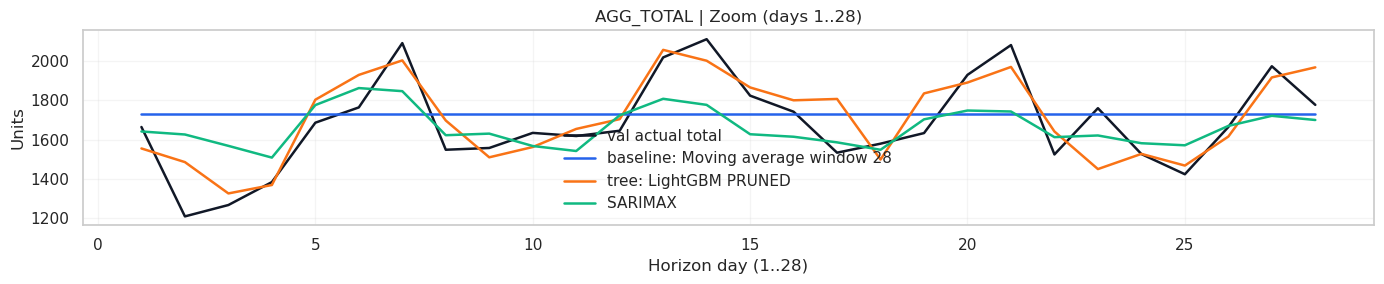

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


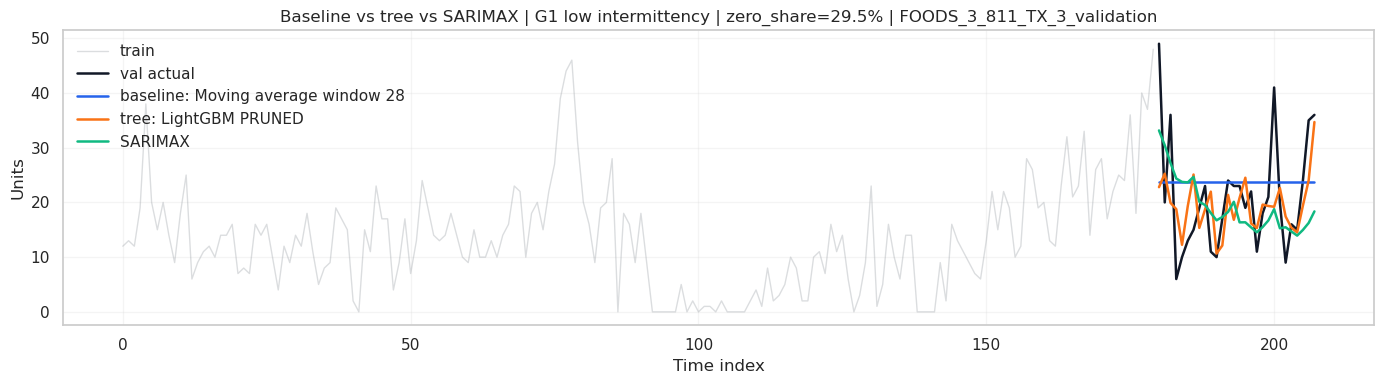

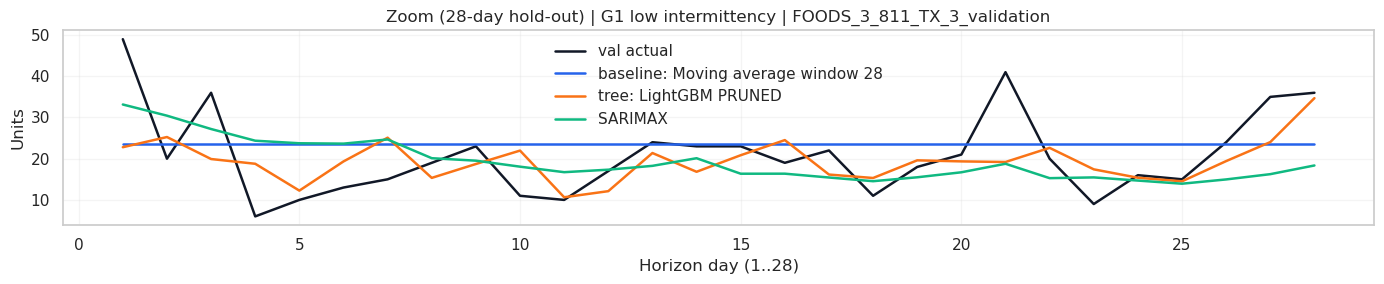

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


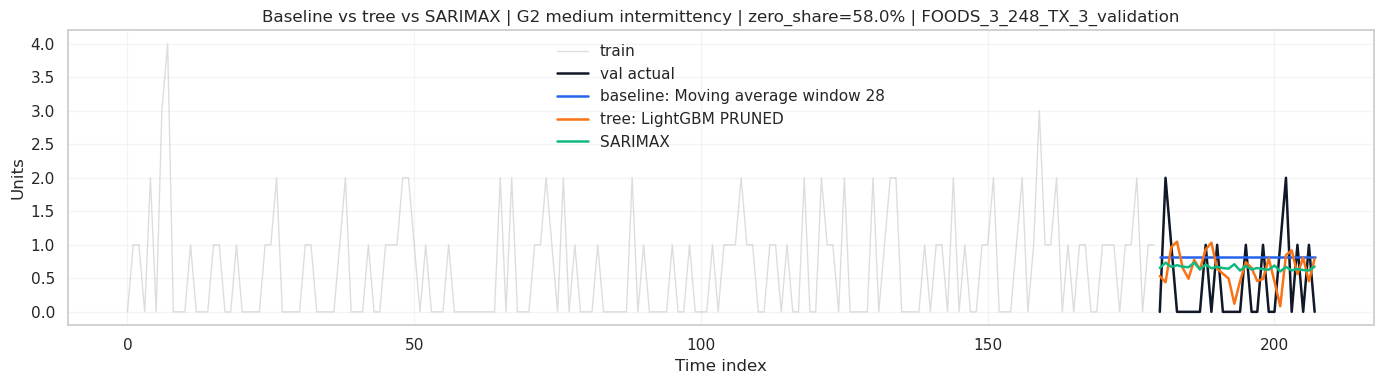

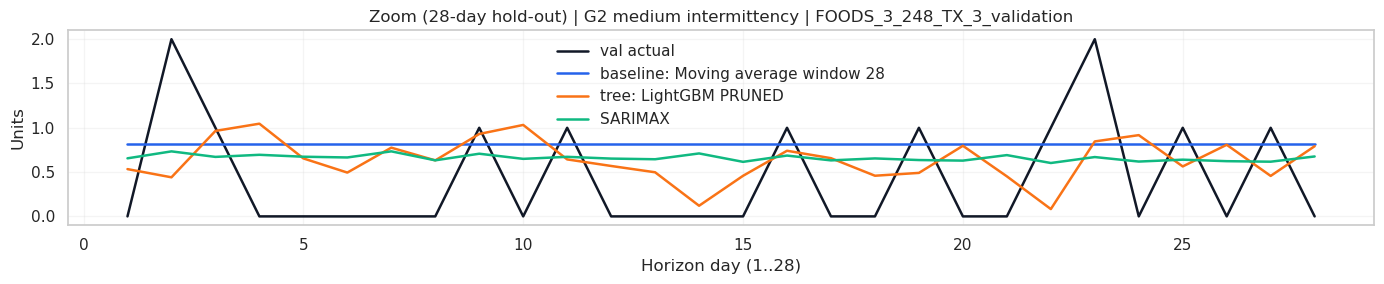

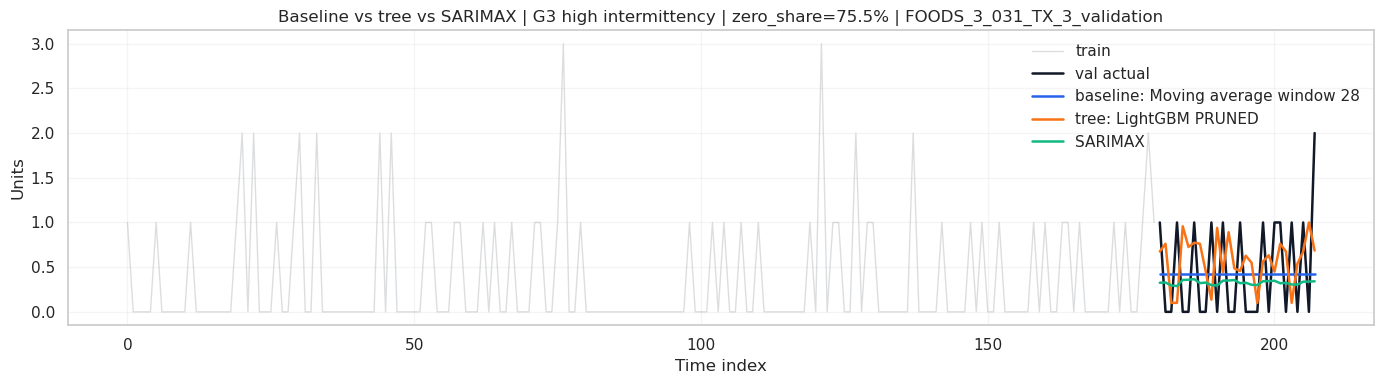

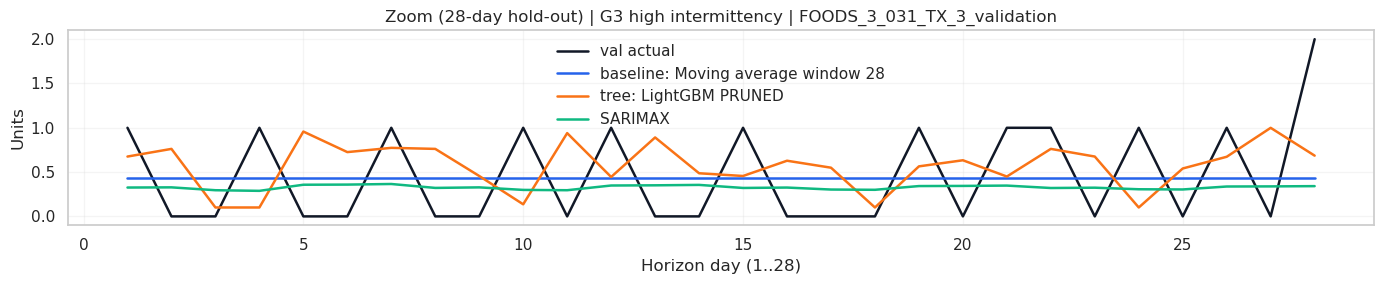

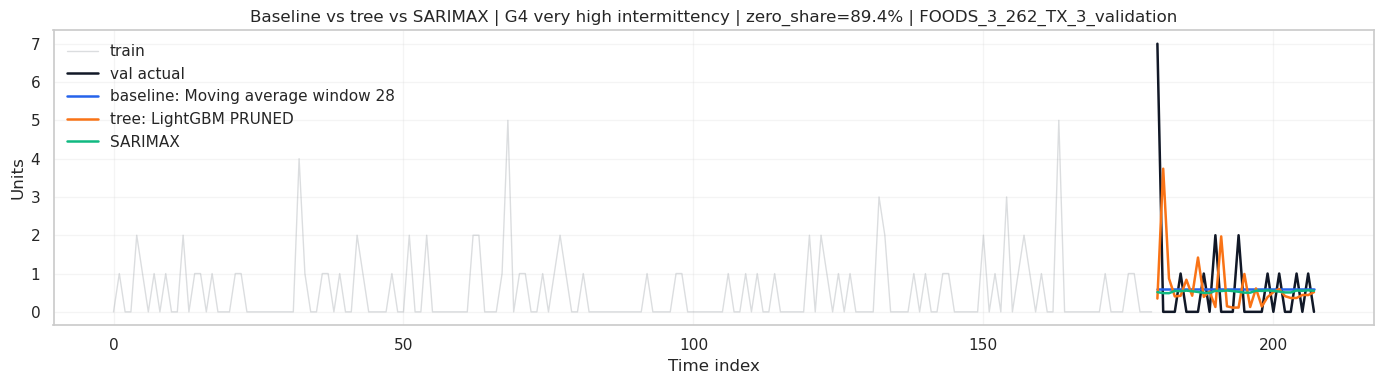

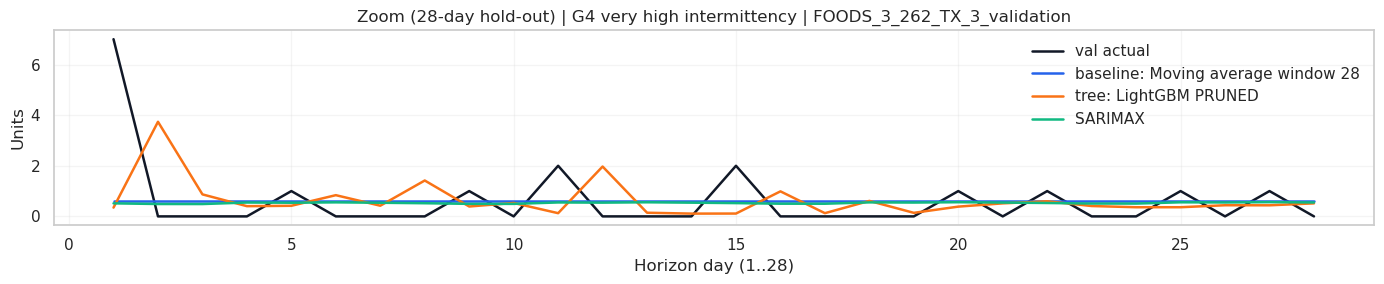

,group,id,zero_share,baseline_RMSE,tree_RMSE,sarimax_RMSE,baseline_MAE,tree_MAE,sarimax_MAE,sarimax_spec
0,G1 low intermittency,FOODS_3_811_TX_3_validation,0.294960,10.487420,9.052762,9.924213,8.410714,6.576624,7.938459,"((1, 0, 1), (1, 0, 1, 7))"
1,G2 medium intermittency,FOODS_3_248_TX_3_validation,0.580371,0.736269,0.708776,0.659135,0.663265,0.626276,0.614920,"((1, 0, 1), (1, 0, 1, 7))"
2,G3 high intermittency,FOODS_3_031_TX_3_validation,0.754907,0.566947,0.684004,0.580895,0.525510,0.620935,0.510199,"((1, 0, 1), (1, 0, 1, 7))"
3,G4 very high intermittency,FOODS_3_262_TX_3_validation,0.894430,1.371633,1.665714,1.374645,0.823980,1.013346,0.792842,"((1, 0, 1), (1, 0, 1, 7))"


In [136]:
H = val_wide.shape[1]  # should be 28

# ----------------------------
# Helper: fit SARIMAX robustly on a single series and forecast H steps
# ----------------------------
def sarimax_forecast(y_train: np.ndarray, steps: int = 28):
    """
    Robust-ish SARIMAX:
    - tries a small set of candidate (order, seasonal_order) pairs
    - returns forecast from the first model that fits
    """
    y_train = np.asarray(y_train, dtype=float)

    # Candidate specs: weekly seasonality is very plausible here
    candidates = [
        ((1, 0, 1), (1, 0, 1, 7)),
        ((2, 0, 2), (1, 0, 1, 7)),
        ((1, 1, 1), (1, 1, 1, 7)),
        ((0, 1, 1), (0, 1, 1, 7)),
    ]

    last_err = None
    for order, sorder in candidates:
        try:
            model = SARIMAX(
                y_train,
                order=order,
                seasonal_order=sorder,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = model.fit(disp=False)
            fc = res.get_forecast(steps=steps).predicted_mean
            fc = np.asarray(fc, dtype=float)
            fc = np.maximum(fc, 0.0)  # sales cannot be negative
            return fc, (order, sorder)
        except Exception as e:
            last_err = e
            continue

    # If everything fails, return a naive fallback so the notebook doesn't die
    # (but we also expose the failure)
    fc = np.repeat(y_train[-1], steps)
    return fc, ("FAILED", str(last_err))


# ----------------------------
# 0) Sanity: ensure alignment
# ----------------------------
baseline_pred_wide = baseline_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns).clip(lower=0.0)
tree_pred_wide     = tree_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns).clip(lower=0.0)

if baseline_pred_wide.isna().sum().sum() > 0:
    raise ValueError("baseline_pred_wide contains NaNs after alignment.")
if tree_pred_wide.isna().sum().sum() > 0:
    raise ValueError("tree_pred_wide contains NaNs after alignment.")

# ----------------------------
# 1) Aggregated daily TOTAL: baseline vs tree vs SARIMAX
# ----------------------------
y_train_total = train_wide.sum(axis=0).astype(float).values
y_val_total   = val_wide.sum(axis=0).astype(float).values

base_total = baseline_pred_wide.sum(axis=0).astype(float).values
tree_total = tree_pred_wide.sum(axis=0).astype(float).values

sar_total, sar_spec_total = sarimax_forecast(y_train_total, steps=H)

totals_metrics = {
    "series": "AGG_TOTAL",
    "baseline_RMSE": float(np.sqrt(np.mean((y_val_total - base_total) ** 2))),
    "tree_RMSE": float(np.sqrt(np.mean((y_val_total - tree_total) ** 2))),
    "sarimax_RMSE": float(np.sqrt(np.mean((y_val_total - sar_total) ** 2))),
    "baseline_MAE": float(np.mean(np.abs(y_val_total - base_total))),
    "tree_MAE": float(np.mean(np.abs(y_val_total - tree_total))),
    "sarimax_MAE": float(np.mean(np.abs(y_val_total - sar_total))),
    "sarimax_spec": str(sar_spec_total),
}

print("AGG_TOTAL SARIMAX spec used:", sar_spec_total)
display(pd.DataFrame([totals_metrics]))

# Plot aggregate (full context + zoom horizon)
plt.figure(figsize=(14, 4))
x_train = np.arange(len(y_train_total))
x_val   = np.arange(len(y_train_total), len(y_train_total) + H)

plt.plot(x_train, y_train_total, color="#9aa0a6", linewidth=1.0, alpha=0.35, label="train total")
plt.plot(x_val, y_val_total,     color="#111827", linewidth=1.8, label="val actual total")
plt.plot(x_val, base_total,      color="#2563eb", linewidth=1.8, label=f"baseline total: {best_name}")
plt.plot(x_val, tree_total,      color="#f97316", linewidth=1.8, label=f"tree total: {best_tree_name}")
plt.plot(x_val, sar_total,       color="#10b981", linewidth=1.8, label="SARIMAX total")

plt.title("AGG_TOTAL | baseline vs tree vs SARIMAX (28-day hold-out)")
plt.xlabel("Time index")
plt.ylabel("Units")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(np.arange(1, H+1), y_val_total, color="#111827", linewidth=1.8, label="val actual total")
plt.plot(np.arange(1, H+1), base_total,  color="#2563eb", linewidth=1.8, label=f"baseline: {best_name}")
plt.plot(np.arange(1, H+1), tree_total,  color="#f97316", linewidth=1.8, label=f"tree: {best_tree_name}")
plt.plot(np.arange(1, H+1), sar_total,   color="#10b981", linewidth=1.8, label="SARIMAX")
plt.title("AGG_TOTAL | Zoom (days 1..28)")
plt.xlabel("Horizon day (1..28)")
plt.ylabel("Units")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ----------------------------
# 2) Representative items: baseline vs tree vs SARIMAX
# ----------------------------
rows = []

def plot_rep_item_zoom(item_id, group_label, zs, tail=180):
    y_tr = train_wide.loc[item_id].astype(float).values
    y_va = val_wide.loc[item_id].astype(float).values
    y_b  = baseline_pred_wide.loc[item_id].astype(float).values
    y_t  = tree_pred_wide.loc[item_id].astype(float).values

    y_s, sar_spec = sarimax_forecast(y_tr, steps=H)

    # metrics on horizon only
    out = {
        "group": group_label,
        "id": item_id,
        "zero_share": float(zs),
        "baseline_RMSE": float(np.sqrt(np.mean((y_va - y_b) ** 2))),
        "tree_RMSE": float(np.sqrt(np.mean((y_va - y_t) ** 2))),
        "sarimax_RMSE": float(np.sqrt(np.mean((y_va - y_s) ** 2))),
        "baseline_MAE": float(np.mean(np.abs(y_va - y_b))),
        "tree_MAE": float(np.mean(np.abs(y_va - y_t))),
        "sarimax_MAE": float(np.mean(np.abs(y_va - y_s))),
        "sarimax_spec": str(sar_spec),
    }
    rows.append(out)

    # Full context plot (tail + horizon)
    tr_tail = y_tr[-tail:]
    x_train = np.arange(len(tr_tail))
    x_val   = np.arange(len(tr_tail), len(tr_tail) + H)

    plt.figure(figsize=(14, 4))
    plt.plot(x_train, tr_tail, color="#9aa0a6", linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val,   y_va,    color="#111827", linewidth=1.8, label="val actual")
    plt.plot(x_val,   y_b,     color="#2563eb", linewidth=1.8, label=f"baseline: {best_name}")
    plt.plot(x_val,   y_t,     color="#f97316", linewidth=1.8, label=f"tree: {best_tree_name}")
    plt.plot(x_val,   y_s,     color="#10b981", linewidth=1.8, label="SARIMAX")

    plt.title(f"Baseline vs tree vs SARIMAX | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Zoom horizon only (so the forecast region is readable)
    plt.figure(figsize=(14, 3))
    plt.plot(np.arange(1, H+1), y_va, color="#111827", linewidth=1.8, label="val actual")
    plt.plot(np.arange(1, H+1), y_b,  color="#2563eb", linewidth=1.8, label=f"baseline: {best_name}")
    plt.plot(np.arange(1, H+1), y_t,  color="#f97316", linewidth=1.8, label=f"tree: {best_tree_name}")
    plt.plot(np.arange(1, H+1), y_s,  color="#10b981", linewidth=1.8, label="SARIMAX")

    plt.title(f"Zoom (28-day hold-out) | {group_label} | {item_id}")
    plt.xlabel("Horizon day (1..28)")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Run for your rep_items
for g, rid, zs in rep_items:
    plot_rep_item_zoom(rid, g, zs, tail=180)

sarimax_rep_table = pd.DataFrame(rows)
display(sarimax_rep_table)

## Aggregating demand by intermittency group (why WE do this)

So far, WE evaluated models at the **item level** (823 series). That setting is hard because many items are **intermittent**: they contain long runs of zeros, which makes both classical time-series models and ML models struggle to forecast exact zero patterns.

To complement the item-level analysis, WE also aggregate demand **by intermittency group** (G1–G4). This gives us **four group-level time series** instead of hundreds of noisy item-level series.

### What WE gain by aggregating
Aggregation (sum or mean across items in a group) stabilizes the signal:

- Random noise and item-specific quirks cancel out
- Zeros become much rarer (especially for sums)
- Weekly seasonality and calendar effects become easier to detect
- Classical time-series models like SARIMAX become more appropriate and more interpretable
- Model diagnostics (residual checks, seasonality validation) become clearer

This makes aggregated series a strong choice for the “explainability / understanding the data” part of the project.

### What WE lose (important limitation)
Aggregation is **not a replacement** for item-level forecasting:

- WE cannot submit group-level forecasts as product-level forecasts
- Aggregation can hide heterogeneity inside a group (a few high-volume items may dominate a group sum)

So WE treat this as an **additional analysis track**:
WE keep the item-level evaluation for H1/H2, and use group-level modeling to strengthen interpretation and diagnostics.

---

## How WE build the group-level series (what the code does)

### Inputs WE already have
- `train_wide`: historical sales matrix (rows = items, columns = days) up to the cutoff  
- `val_wide`: the next 28 days hold-out matrix (same rows, 28 columns)  
- `groups`: mapping from each item id to one of the four intermittency groups (computed from train-only zero share)

### Step 1. Aggregate sales per group
For each group (G1–G4), WE collect all item rows that belong to that group and aggregate across items **for each day**.

WE compute two versions:
- **SUM series**: total units sold per day within the group (most stable)
- **MEAN series**: average units per item per day (less dominated by high-volume items)

Result:
- `train_group_sum` and `val_group_sum` each have shape **(4 groups × days)**
- `train_group_mean` and `val_group_mean` each have shape **(4 groups × days)**

### Step 2. Plot train tail + hold-out window
For each group, WE plot:
- the last `tail` days of training demand (context)
- the 28-day hold-out actual demand (target window)

These plots answer:
- how seasonal the group demand looks (weekly patterns)
- whether hold-out behavior is “continuation” or contains regime changes
- whether the group is stable enough for SARIMAX-style modeling

---

## What WE look for in the plots
WE are mainly looking for:

1) **Weekly seasonality**
   If the aggregated series shows repeating patterns every ~7 days, SARIMAX with seasonal period 7 is defensible.

2) **Differences across groups**
   - G1 should look smoother and higher-volume
   - G4 should still be low-volume but much less “all-zero” once aggregated

3) **Hold-out difficulty**
   If the 28-day hold-out has sharp jumps or regime changes, even aggregated models may struggle.

---

## Why this matters for the rest of the project
Once WE have stable group-level series, WE can run:
- SARIMAX with exogenous drivers (price, SNAP, events)
- residual diagnostics (ACF, Ljung–Box, normality checks)
- clean comparisons: baseline MA(28) vs SARIMAX vs simple ML on the aggregated level

This strengthens the explanation behind H2 (“who benefits most”) and supports the analysis questions about promotions, SNAP, and events.


Group-level series built.


,train_sum_mean,val_sum_mean,train_mean_mean,val_mean_mean
G1 low intermittency,1149.002122,1006.500000,5.577680,4.885922
G2 medium intermittency,268.994164,413.464286,1.305797,2.007108
G3 high intermittency,111.791512,165.071429,0.545324,0.805226
G4 very high intermittency,35.352255,99.500000,0.171613,0.483010


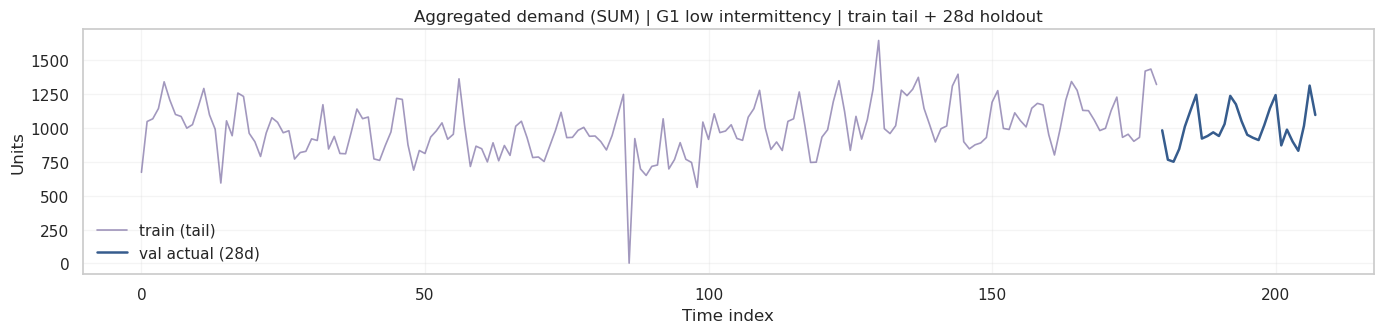

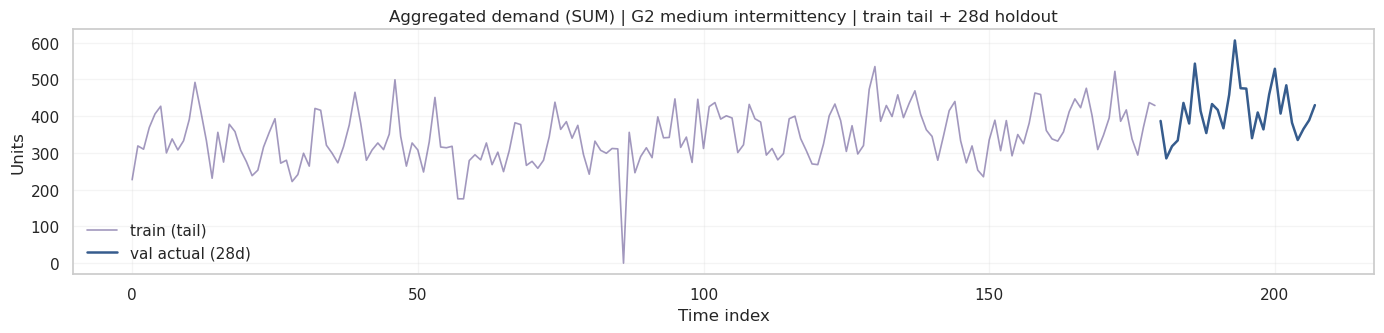

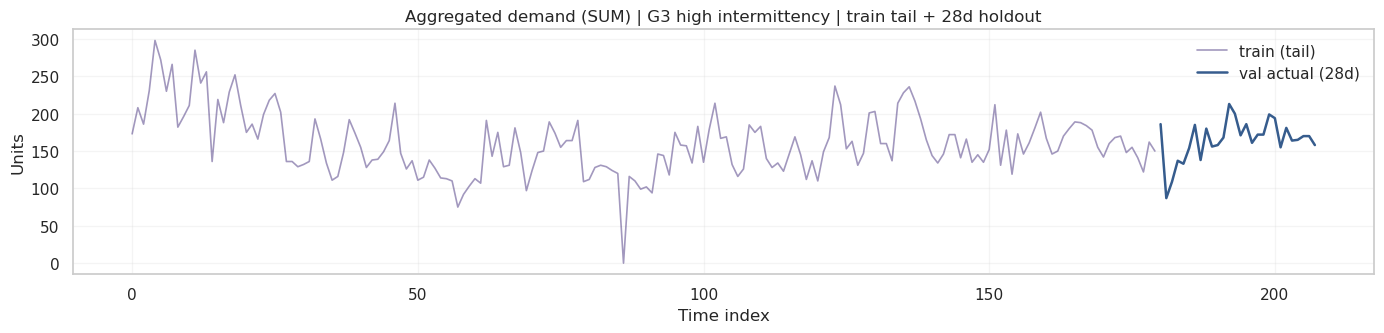

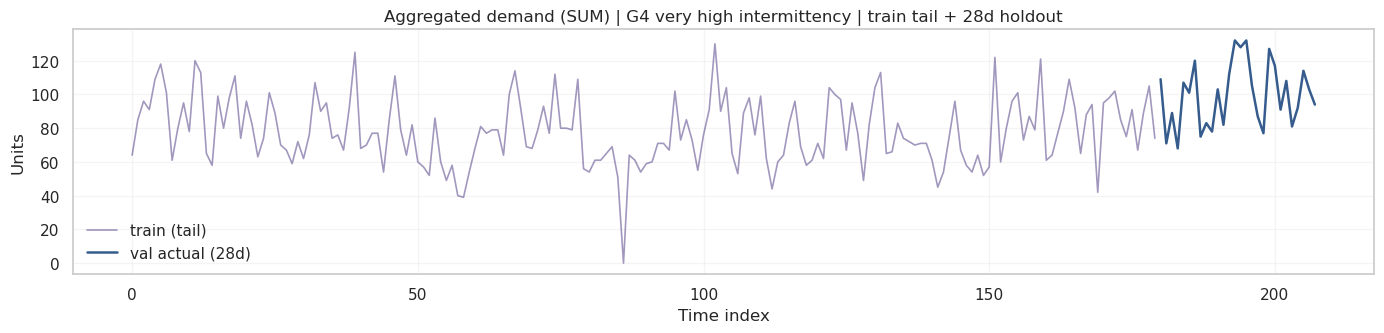

In [137]:


group_order = ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]

# ----------------------------
# WE aggregate train/val sales (wide) into 4 group-level series
# ----------------------------
def aggregate_wide_by_group(wide_df: pd.DataFrame, groups: pd.Series, how: str = "sum") -> pd.DataFrame:
    g = groups.reindex(wide_df.index)
    if g.isna().any():
        missing = g[g.isna()].index[:5].tolist()
        raise ValueError(f"groups missing for some ids in wide_df. Example ids: {missing}")

    out = {}
    for grp in group_order:
        ids = wide_df.index[g.values == grp]
        if how == "sum":
            out[grp] = wide_df.loc[ids].sum(axis=0)
        elif how == "mean":
            out[grp] = wide_df.loc[ids].mean(axis=0)
        else:
            raise ValueError("how must be 'sum' or 'mean'")
    return pd.DataFrame(out).T  # rows=groups, cols=days

train_group_sum = aggregate_wide_by_group(train_wide, groups, how="sum")
val_group_sum   = aggregate_wide_by_group(val_wide, groups, how="sum")

# Optional alternative: mean-per-item series (less dominated by big items)
train_group_mean = aggregate_wide_by_group(train_wide, groups, how="mean")
val_group_mean   = aggregate_wide_by_group(val_wide, groups, how="mean")

print("Group-level series built.")
display(pd.DataFrame({
    "train_sum_mean": train_group_sum.mean(axis=1),
    "val_sum_mean": val_group_sum.mean(axis=1),
    "train_mean_mean": train_group_mean.mean(axis=1),
    "val_mean_mean": val_group_mean.mean(axis=1),
}))

# ----------------------------
# WE plot: 4 panels separately (cleaner than subplots)
# ----------------------------
def plot_group_series(train_grp: pd.Series, val_grp: pd.Series, title: str, tail: int = 180):
    ytr = train_grp.astype(float).values
    yva = val_grp.astype(float).values

    ytr_tail = ytr[-tail:] if len(ytr) > tail else ytr
    x_train = np.arange(len(ytr_tail))
    x_val = np.arange(len(ytr_tail), len(ytr_tail) + len(yva))

    plt.figure(figsize=(14, 3.5))
    plt.plot(x_train, ytr_tail, linewidth=1.2, alpha=0.5, label="train (tail)")
    plt.plot(x_val, yva, linewidth=1.8, label="val actual (28d)")
    plt.title(title)
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for grp in group_order:
    plot_group_series(
        train_group_sum.loc[grp],
        val_group_sum.loc[grp],
        title=f"Aggregated demand (SUM) | {grp} | train tail + 28d holdout",
        tail=180
    )


## Group-level aggregation sanity check (what WE just did)

WE converted the 823 item-level series into **four group-level time series** by aggregating items within each intermittency bucket (G1–G4).

### What this cell produces
1) `train_group_sum` / `val_group_sum`  
Daily **total units** per group (sum over items). This is the most stable representation.

2) `train_group_mean` / `val_group_mean`  
Daily **average units per item** per group. This is useful for comparability across groups (not dominated by a few high-volume items).

3) Plots per group:  
WE plot the last `tail=180` days of training plus the **same 28-day hold-out** as before.

### What WE should check in the plots
WE mainly use these plots as a diagnostic before modeling:
- Do we see **weekly seasonality** (repeating 7-day pattern)?
- Is the 28-day holdout similar to recent history or does it show a regime change?
- Are group sums smooth enough that SARIMAX is defensible?

If the plots look stable (especially for G1/G2 sums), group-level SARIMAX becomes meaningful.


## Group-level benchmarks (supplementary analysis)

WE aggregate item-level demand into **four group-level time series** based on intermittency (G1–G4).  
This reduces item-level noise and makes classical time-series structure (especially weekly seasonality) easier to estimate.

### Goal
WE compare forecast skill on each aggregated group series for:

1) **MA(28)** baseline (mean of last 28 observed days, repeated)  
2) **Seasonal Naive(7)** baseline (repeat the last observed week)  
3) **SARIMAX** with weekly seasonality (interpretable classical benchmark)  
4) **LightGBM** on group-level lags + aggregated exogenous features (non-linear benchmark)

WE evaluate each model on the same **28-day holdout** used throughout the notebook.

### Why this matters
Aggregation reduces intermittency noise (especially in G3–G4). In that setting:
- SARIMAX can become competitive because weekly seasonality is easier to estimate
- LightGBM can still win if the relationship between lags and exogenous drivers is non-linear

This section complements (but does not replace) the item-level H2 analysis.


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


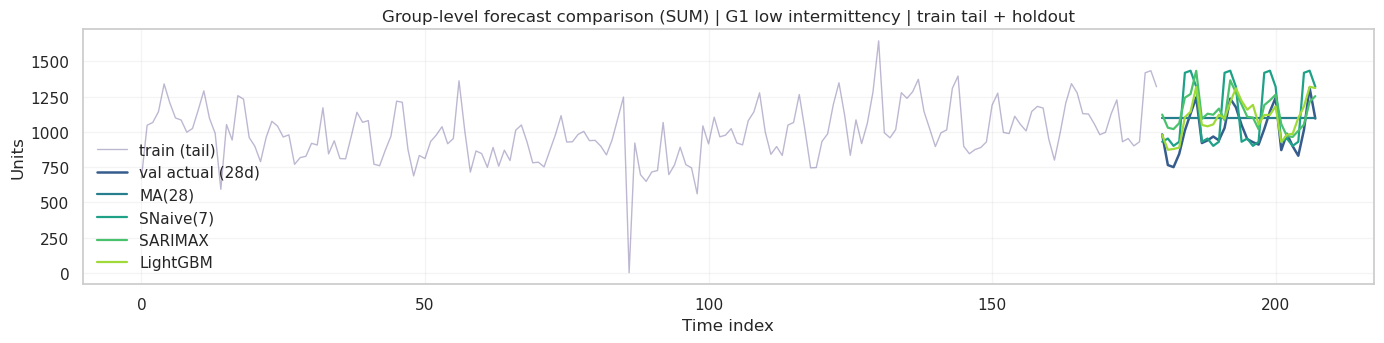

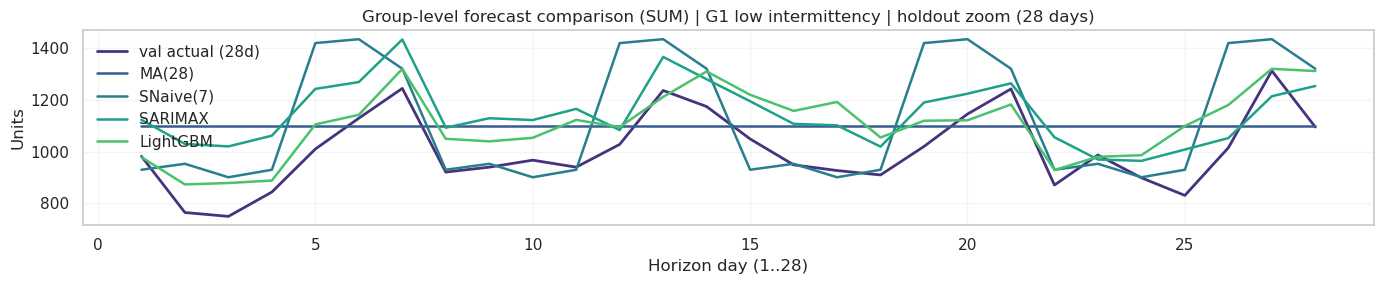

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


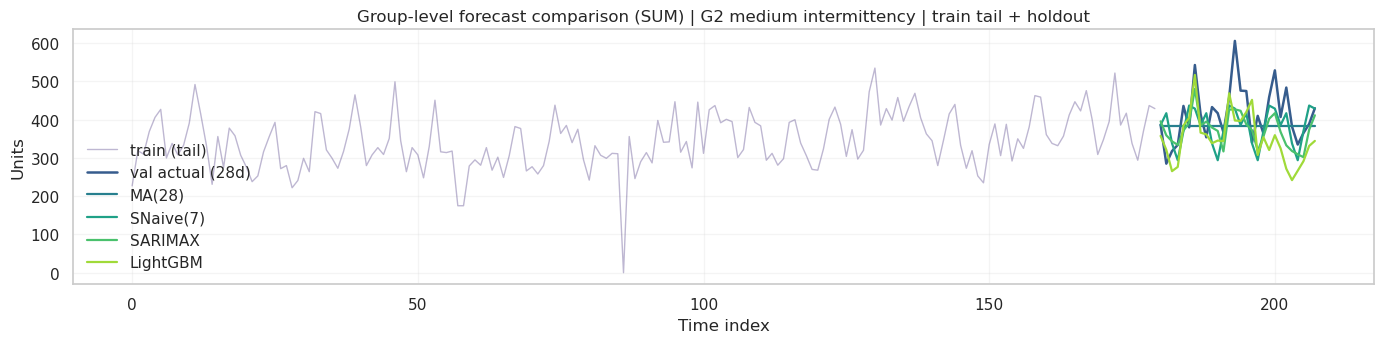

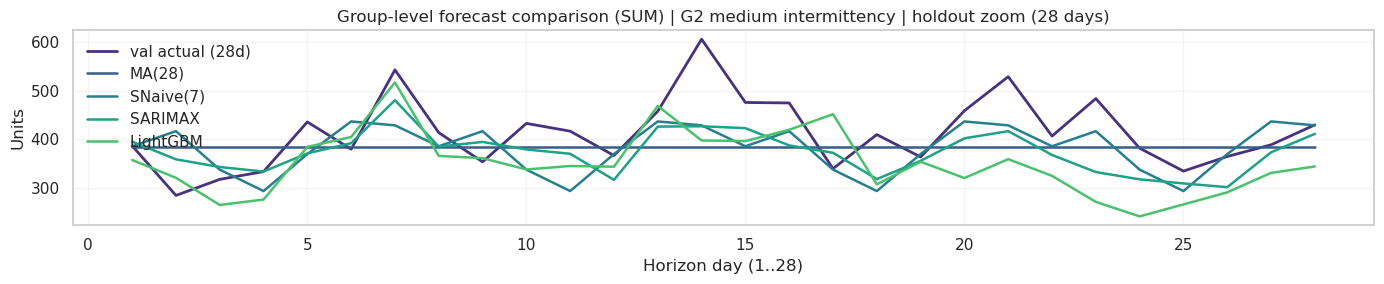

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


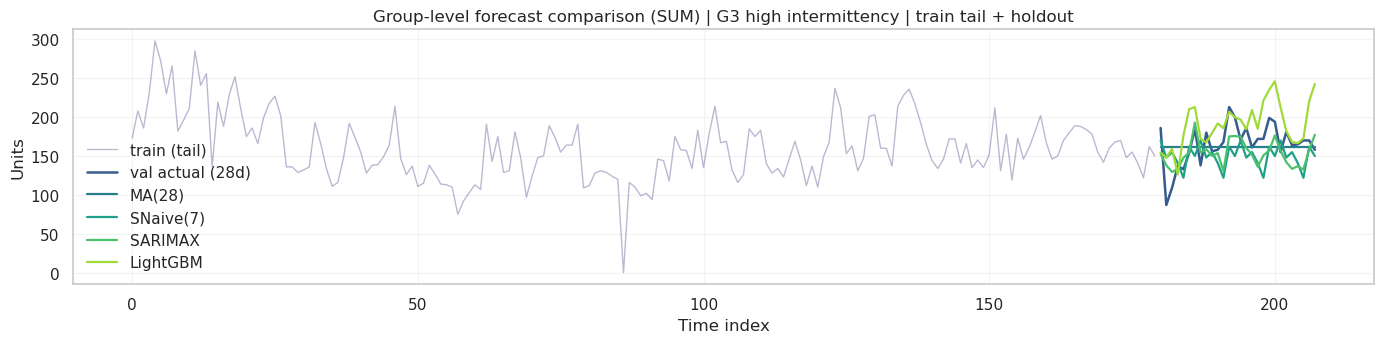

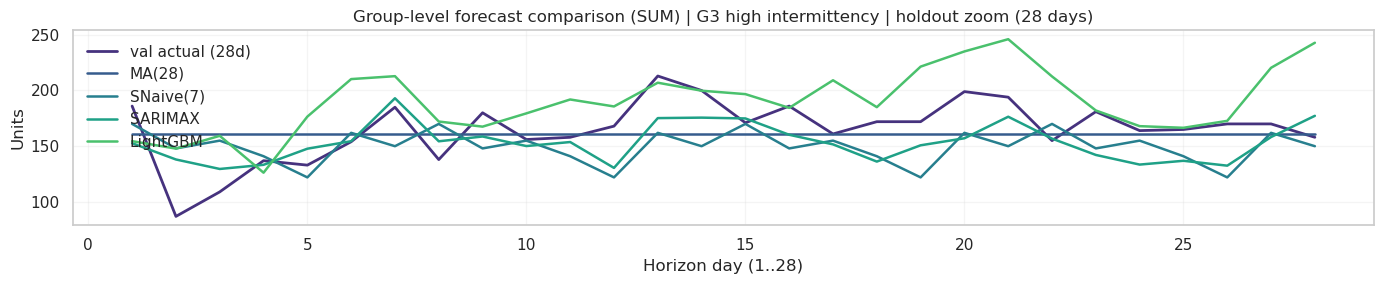

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


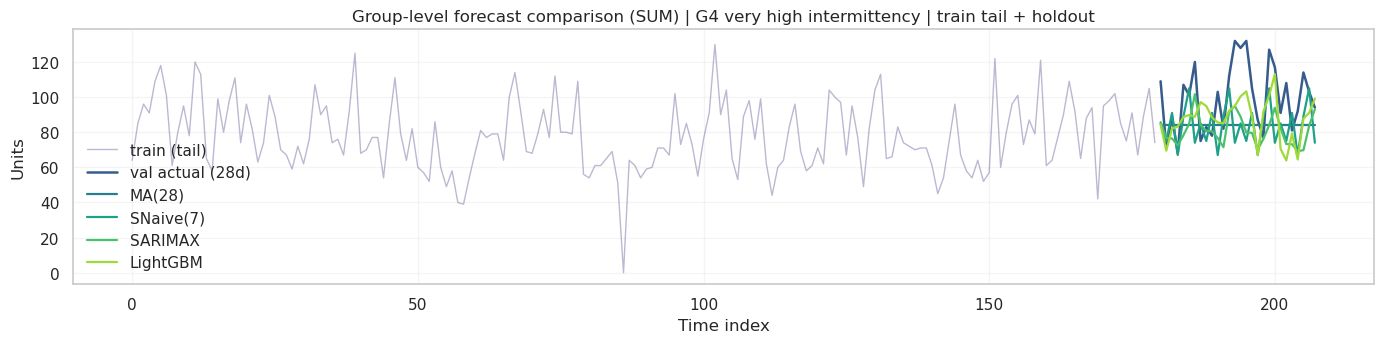

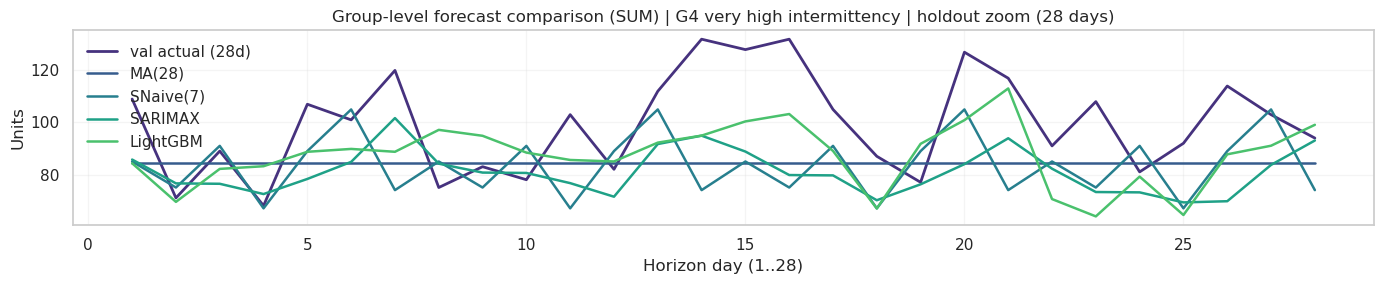

,group,model,RMSE,MAE,sarimax_lb_p7,sarimax_lb_p14,sarimax_used
0,G1 low intermittency,LightGBM group-lags,129.540108,106.141919,NaN,NaN,NaN
1,G1 low intermittency,"SARIMAX(1,0,1)x(1,0,1,7)",160.345406,145.693537,3.002028e-09,1.627701e-08,True
2,G1 low intermittency,MA(28),170.575695,148.446429,NaN,NaN,NaN
3,G1 low intermittency,SeasonalNaive(7),194.537914,142.142857,NaN,NaN,NaN
4,G2 medium intermittency,"SARIMAX(1,0,1)x(1,0,1,7)",67.255282,53.356448,2.625477e-01,2.716505e-01,True
5,G2 medium intermittency,SeasonalNaive(7),72.465016,55.750000,NaN,NaN,NaN
6,G2 medium intermittency,MA(28),77.125883,57.997449,NaN,NaN,NaN
7,G2 medium intermittency,LightGBM group-lags,93.514572,75.961902,NaN,NaN,NaN
8,G3 high intermittency,"SARIMAX(1,0,1)x(1,0,1,7)",25.596649,21.522549,4.009643e-03,4.396635e-02,True
9,G3 high intermittency,MA(28),26.764277,20.081633,NaN,NaN,NaN


,group,best_model,RMSE,MAE,sarimax_lb_p7,sarimax_lb_p14,sarimax_used
0,G1 low intermittency,LightGBM group-lags,129.540108,106.141919,3.002028e-09,1.627701e-08,True
1,G2 medium intermittency,"SARIMAX(1,0,1)x(1,0,1,7)",67.255282,53.356448,2.625477e-01,2.716505e-01,True
2,G3 high intermittency,"SARIMAX(1,0,1)x(1,0,1,7)",25.596649,21.522549,4.009643e-03,4.396635e-02,True
3,G4 very high intermittency,LightGBM group-lags,20.946694,18.036355,8.390258e-01,5.936125e-01,True


Stored SARIMAX fits for residual diagnostics: ['G1 low intermittency', 'G2 medium intermittency', 'G3 high intermittency', 'G4 very high intermittency']


In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

from sklearn.ensemble import HistGradientBoostingRegressor

# LightGBM (optional)
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# ------------------------------------------------------------
# Preconditions expected in notebook state:
# - train_wide, val_wide  (wide frames, cols like d_####)
# - sales_long            (long frame with d_index, snap_TX, wday, month, weekday, sell_price, price_change, id)
# - groups                (Series mapping id -> group label)
# - group_order           (list of group labels in desired order)
# - H                     (holdout horizon, 28)
# - rmse(), mae()         (metric helpers)
# ------------------------------------------------------------

def _parse_dcols(cols):
    return [int(str(c).split("_")[1]) for c in cols]

def _ensure_sorted_wide(wide_df):
    d_idx = _parse_dcols(wide_df.columns)
    order = np.argsort(d_idx)
    return wide_df.iloc[:, order]

def aggregate_wide_by_group(wide_df: pd.DataFrame, groups: pd.Series, how: str = "sum") -> pd.DataFrame:
    g = groups.reindex(wide_df.index)
    if g.isna().any():
        missing = g[g.isna()].index[:5].tolist()
        raise ValueError(f"groups missing for some ids in wide_df. Example ids: {missing}")

    out = {}
    for grp in group_order:
        ids = wide_df.index[g.values == grp]
        if how == "sum":
            out[grp] = wide_df.loc[ids].sum(axis=0)
        elif how == "mean":
            out[grp] = wide_df.loc[ids].mean(axis=0)
        else:
            raise ValueError("how must be 'sum' or 'mean'")
    return pd.DataFrame(out).T  # rows=groups, cols=d_####

def plot_group_holdout_zoom(train_series, val_series, preds_dict, title, tail=180):
    ytr = train_series.astype(float).values
    yva = val_series.astype(float).values

    ytr_tail = ytr[-tail:] if len(ytr) > tail else ytr
    x_train = np.arange(len(ytr_tail))
    x_val = np.arange(len(ytr_tail), len(ytr_tail) + len(yva))

    plt.figure(figsize=(14, 3.6))
    plt.plot(x_train, ytr_tail, linewidth=1.0, alpha=0.35, label="train (tail)")
    plt.plot(x_val, yva, linewidth=1.8, label="val actual (28d)")
    for name, pred in preds_dict.items():
        plt.plot(x_val, pred, linewidth=1.6, label=name)
    plt.title(title + " | train tail + holdout")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 3.0))
    plt.plot(np.arange(1, len(yva) + 1), yva, linewidth=2.0, label="val actual (28d)")
    for name, pred in preds_dict.items():
        plt.plot(np.arange(1, len(yva) + 1), pred, linewidth=1.8, label=name)
    plt.title(title + " | holdout zoom (28 days)")
    plt.xlabel("Horizon day (1..28)")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def forecast_ma28(y_train, H):
    last = y_train[-28:] if len(y_train) >= 28 else y_train
    return np.repeat(np.mean(last), H)

def forecast_snaive7(y_train, H):
    last_week = y_train[-7:] if len(y_train) >= 7 else np.repeat(y_train[-1], 7)
    return np.tile(last_week, int(np.ceil(H / 7)))[:H]

SARIMAX_ORDER = (1, 0, 1)
SARIMAX_SEASONAL = (1, 0, 1, 7)

def fit_forecast_sarimax(y_train, ex_train, ex_future, H):
    model = SARIMAX(
        y_train,
        exog=ex_train,
        order=SARIMAX_ORDER,
        seasonal_order=SARIMAX_SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=H, exog=ex_future)
    pred = np.asarray(fc.predicted_mean, dtype=float)
    pred = np.maximum(pred, 0.0)
    return pred, res

def fit_lightgbm_and_forecast_recursive(y_train, exog_train_df, exog_future_df, H):
    df = exog_train_df.copy()
    df["y"] = y_train
    df["lag_1"]  = df["y"].shift(1)
    df["lag_7"]  = df["y"].shift(7)
    df["lag_28"] = df["y"].shift(28)
    df = df.dropna().copy()

    feat_cols = ["lag_1", "lag_7", "lag_28"] + [c for c in exog_train_df.columns]

    Xtr = df[feat_cols]
    ytr = df["y"].values

    if HAS_LGBM:
        model = LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            verbosity=-1,          # suppress LightGBM info spam
            force_col_wise=True,   # avoid the auto-check overhead message
        )
    else:
        model = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=300,
            random_state=42,
        )

    model.fit(Xtr, ytr)

    hist = list(map(float, y_train))
    preds = []

    for i in range(H):
        lag_1  = hist[-1]
        lag_7  = hist[-7] if len(hist) >= 7 else hist[-1]
        lag_28 = hist[-28] if len(hist) >= 28 else hist[-1]

        ex_row = exog_future_df.iloc[i].to_dict()
        x = {"lag_1": lag_1, "lag_7": lag_7, "lag_28": lag_28, **ex_row}
        Xone = pd.DataFrame([x], columns=feat_cols)

        yhat = float(model.predict(Xone)[0])
        yhat = max(yhat, 0.0)
        preds.append(yhat)
        hist.append(yhat)

    return np.array(preds, dtype=float), model

# ----------------------------
# Build group-level series (SUM aggregation)
# ----------------------------
train_wide_s = _ensure_sorted_wide(train_wide)
val_wide_s   = _ensure_sorted_wide(val_wide)

train_group = aggregate_wide_by_group(train_wide_s, groups, how="sum")
val_group   = aggregate_wide_by_group(val_wide_s, groups, how="sum")

train_days = _parse_dcols(train_group.columns)
val_days   = _parse_dcols(val_group.columns)

if len(val_days) != H:
    raise ValueError(f"val_group has {len(val_days)} days but H={H}. Check val_wide.")

all_days = sorted(set(train_days + val_days))

# Day-level shared features
day_feats = (
    sales_long.loc[sales_long["d_index"].isin(all_days), ["d_index", "snap_TX", "wday", "month", "weekday"]]
    .drop_duplicates("d_index")
    .set_index("d_index")
    .sort_index()
)

day_feats["snap_TX"] = pd.to_numeric(day_feats["snap_TX"], errors="coerce").fillna(0.0)
day_feats["wday"]    = pd.to_numeric(day_feats["wday"], errors="coerce").ffill().bfill()
day_feats["month"]   = pd.to_numeric(day_feats["month"], errors="coerce").ffill().bfill()

# ----------------------------
# Main loop: evaluate models per group
# ----------------------------
rows = []
sarimax_fits = {}   # <-- store fitted SARIMAX results per group for residual diagnostics

for grp in group_order:
    grp_ids = groups[groups == grp].index

    y_train = train_group.loc[grp].astype(float).values
    y_val   = val_group.loc[grp].astype(float).values

    sub = sales_long.loc[
        (sales_long["id"].isin(grp_ids)) & (sales_long["d_index"].isin(all_days)),
        ["d_index", "sell_price", "price_change"]
    ].copy()

    sub["sell_price"] = pd.to_numeric(sub["sell_price"], errors="coerce")
    sub["price_change"] = pd.to_numeric(sub["price_change"], errors="coerce").fillna(0.0)

    price_grp = (
        sub.groupby("d_index")
           .agg(sell_price_mean=("sell_price", "mean"),
                price_change_mean=("price_change", "mean"))
           .reindex(all_days)
    ).ffill().bfill().fillna(0.0)

    exog = pd.concat([day_feats.reindex(all_days), price_grp], axis=1).ffill().bfill().fillna(0.0)

    ex_train = exog.loc[train_days, ["snap_TX", "wday", "month", "sell_price_mean", "price_change_mean"]]
    ex_val   = exog.loc[val_days,   ["snap_TX", "wday", "month", "sell_price_mean", "price_change_mean"]]

    pred_ma28 = forecast_ma28(y_train, H)
    pred_s7   = forecast_snaive7(y_train, H)

    sarimax_ok = True
    lb_p7 = np.nan
    lb_p14 = np.nan
    try:
        pred_sarimax, sar_res = fit_forecast_sarimax(y_train, ex_train.values, ex_val.values, H)
        sarimax_fits[grp] = sar_res

        resid = pd.Series(sar_res.resid).dropna().astype(float)
        lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
        lb_p7  = float(lb.loc[7, "lb_pvalue"])  if 7 in lb.index  else np.nan
        lb_p14 = float(lb.loc[14, "lb_pvalue"]) if 14 in lb.index else np.nan
    except Exception as e:
        sarimax_ok = False
        pred_sarimax = pred_s7.copy()
        print(f"SARIMAX failed for {grp}. Using seasonal naive fallback. Error:", repr(e))

    pred_lgb, _ = fit_lightgbm_and_forecast_recursive(
        y_train=y_train,
        exog_train_df=ex_train.reset_index(drop=True),
        exog_future_df=ex_val.reset_index(drop=True),
        H=H
    )

    # Clip
    pred_ma28    = np.maximum(pred_ma28, 0.0)
    pred_s7      = np.maximum(pred_s7, 0.0)
    pred_sarimax = np.maximum(pred_sarimax, 0.0)
    pred_lgb     = np.maximum(pred_lgb, 0.0)

    # Metrics
    for name, pred in [
        ("LightGBM group-lags", pred_lgb),
        ("MA(28)", pred_ma28),
        ("SARIMAX(1,0,1)x(1,0,1,7)", pred_sarimax),
        ("SeasonalNaive(7)", pred_s7),
    ]:
        rows.append({
            "group": grp,
            "model": name,
            "RMSE": rmse(y_val, pred),
            "MAE": mae(y_val, pred),
            "sarimax_lb_p7": lb_p7 if name.startswith("SARIMAX") else np.nan,
            "sarimax_lb_p14": lb_p14 if name.startswith("SARIMAX") else np.nan,
            "sarimax_used": sarimax_ok if name.startswith("SARIMAX") else np.nan,
        })

    # Plots
    preds_dict = {
        "MA(28)": pred_ma28,
        "SNaive(7)": pred_s7,
        "SARIMAX": pred_sarimax,
        "LightGBM": pred_lgb,
    }
    plot_group_holdout_zoom(
        train_series=train_group.loc[grp],
        val_series=val_group.loc[grp],
        preds_dict=preds_dict,
        title=f"Group-level forecast comparison (SUM) | {grp}",
        tail=180
    )

group_results = pd.DataFrame(rows).sort_values(["group", "RMSE"]).reset_index(drop=True)
display(group_results)

best_per_group = (
    group_results.sort_values(["group", "RMSE"])
    .groupby("group")
    .first()
    .reset_index()
    .rename(columns={"model": "best_model"})
)
display(best_per_group)

print("Stored SARIMAX fits for residual diagnostics:", list(sarimax_fits.keys()))


## Group-level benchmark results (SUM aggregation)

WE benchmarked four models on 28-day holdout forecasts for each intermittency group after aggregating item-level sales into one series per group:

- MA(28)
- Seasonal Naive(7)
- SARIMAX(1,0,1) × (1,0,1,7) with exogenous features
- LightGBM trained on group-level lags + aggregated exogenous variables

### Main finding: aggregation changes the “best model”
- **G1 (low intermittency): LightGBM group-lags performs best**.  
  Interpretation: at high-volume demand, non-linear lag effects and exogenous interactions remain important even after aggregation.

- **G2 and G3: SARIMAX performs best by RMSE**.  
  Interpretation: aggregation stabilizes demand enough that classical weekly seasonal structure becomes exploitable.

- **G4: LightGBM and MA(28) are extremely close** (RMSE difference is tiny).  
  Interpretation: the aggregated very-intermittent group behaves almost like a slowly varying level process; simple averaging can be hard to beat.

### Important caution: SARIMAX residual tests suggest mis-specification in some groups
WE computed Ljung–Box tests on SARIMAX residuals:
- **G1 and G3 show significant residual autocorrelation** (very small p-values).  
  That means SARIMAX(1,0,1)×(1,0,1,7) is likely under-specified there.
- **G2 and G4 do not show strong evidence of residual autocorrelation** (p-values not small).  
  There SARIMAX is more defensible as a classical benchmark.


## SARIMAX residual diagnostics: interpretation and implications

### What these diagnostics are checking
WE use residual diagnostics to test a very specific assumption:

If SARIMAX has captured the main time structure (trend, weekly seasonality, short-range dependence), then the remaining errors
(residuals = actual − fitted) should look close to “white noise”.

That means:
1. Residuals fluctuate around 0 with no persistent patterns over time
2. Residual autocorrelation is near 0 for lags beyond random noise
3. Ljung–Box p-values are not tiny (WE fail to reject “no autocorrelation”)

If these checks fail, SARIMAX is still a valid benchmark, but it is not a fully adequate explanation of the series dynamics.



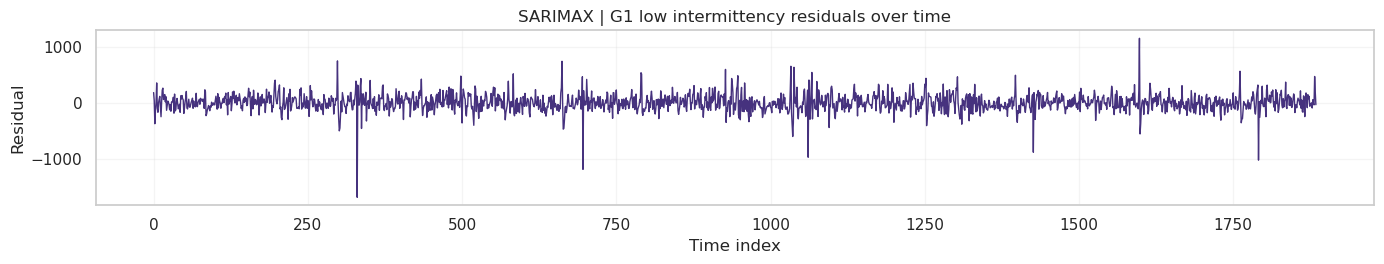

<Figure size 1400x300 with 0 Axes>

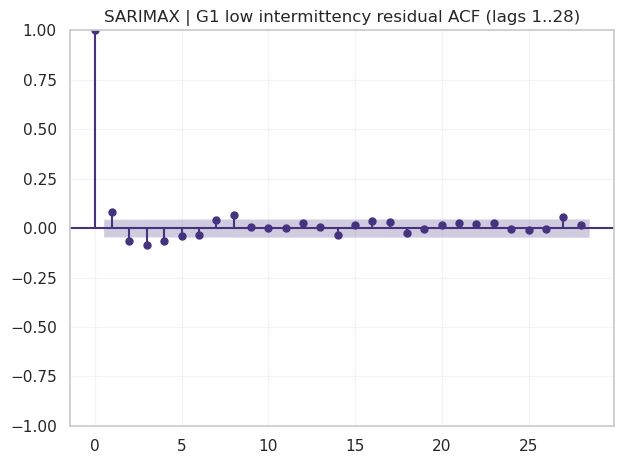

,lb_stat,lb_pvalue
7,53.463858,3.002028e-09
14,64.849006,1.627701e-08
21,72.056401,1.638842e-07
28,80.831015,5.016356e-07


<Figure size 600x400 with 0 Axes>

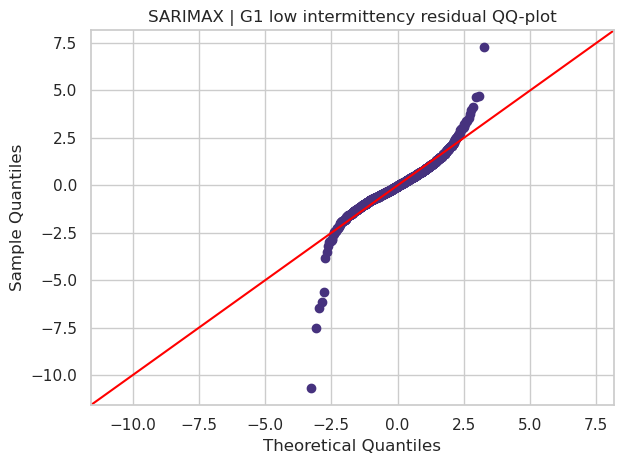

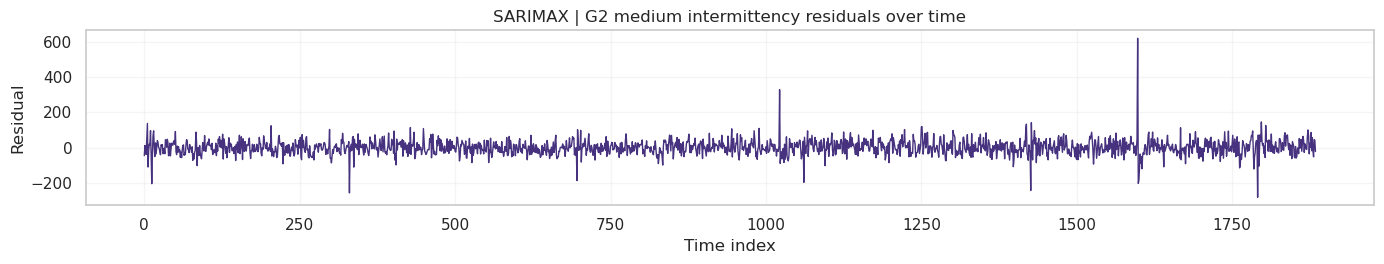

<Figure size 1400x300 with 0 Axes>

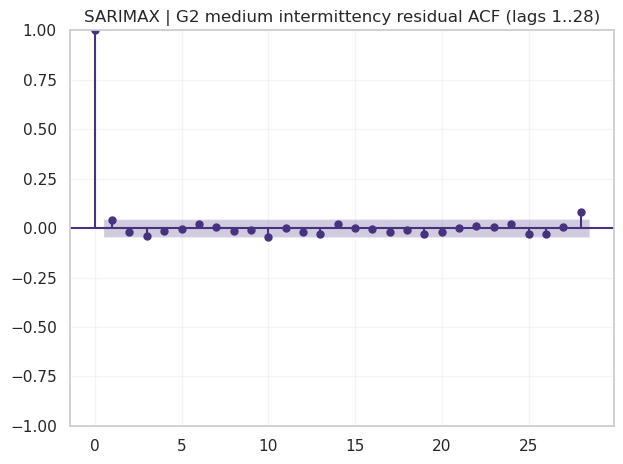

,lb_stat,lb_pvalue
7,8.864280,0.262548
14,16.715601,0.271651
21,20.258505,0.504944
28,36.332149,0.134333


<Figure size 600x400 with 0 Axes>

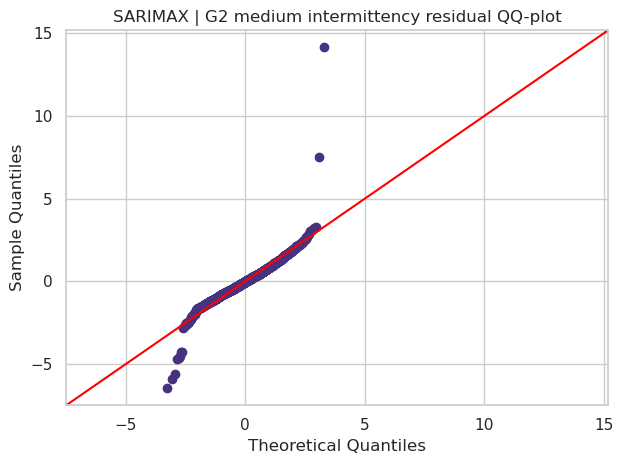

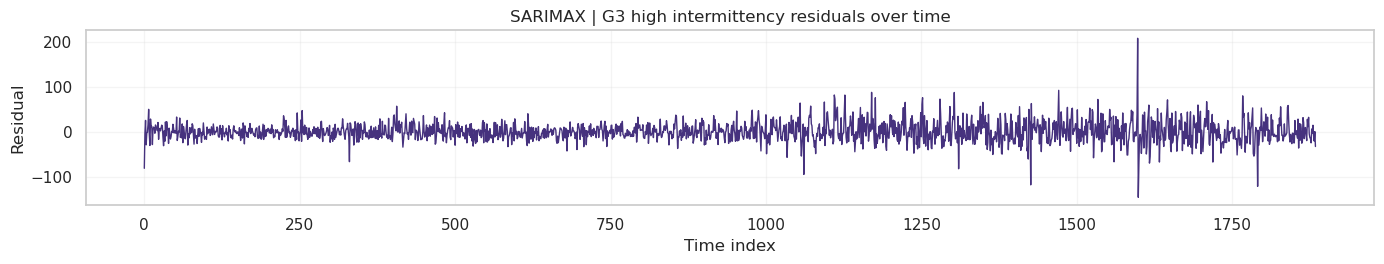

<Figure size 1400x300 with 0 Axes>

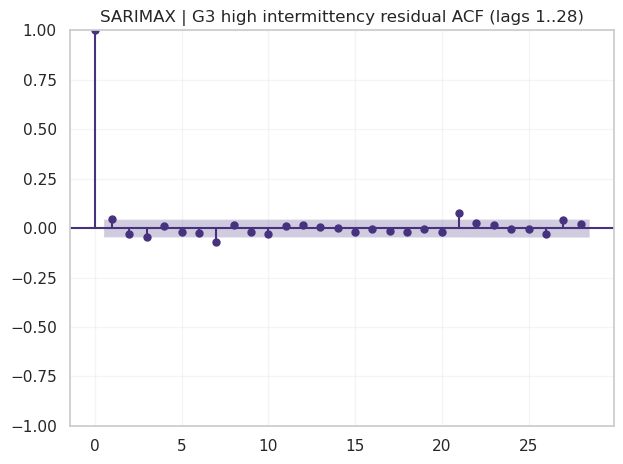

,lb_stat,lb_pvalue
7,20.842973,0.004010
14,24.148397,0.043966
21,37.563446,0.014492
28,45.108538,0.021510


<Figure size 600x400 with 0 Axes>

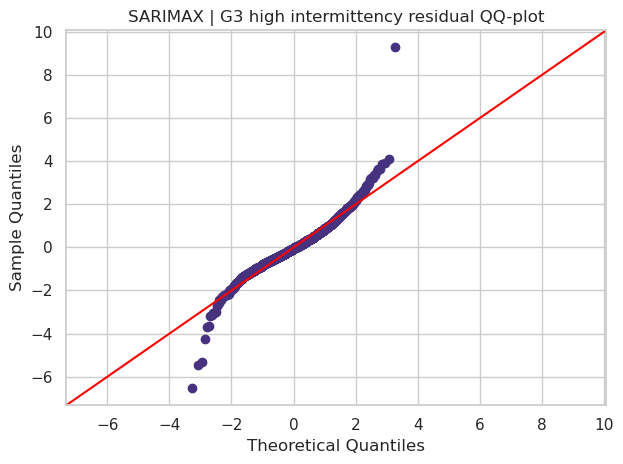

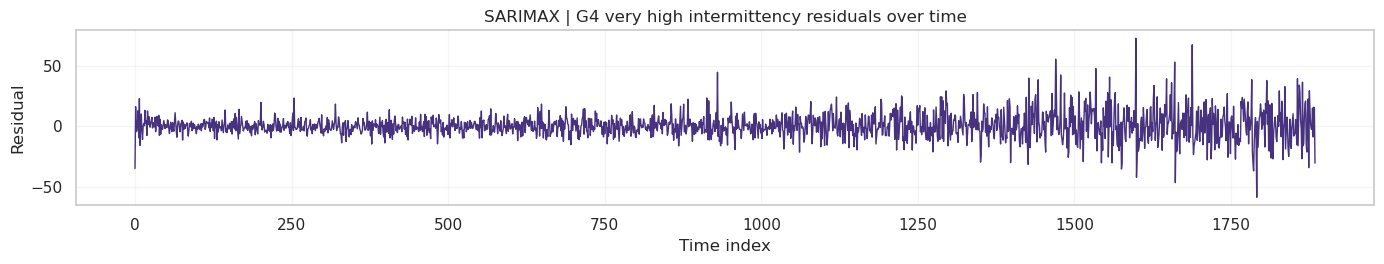

<Figure size 1400x300 with 0 Axes>

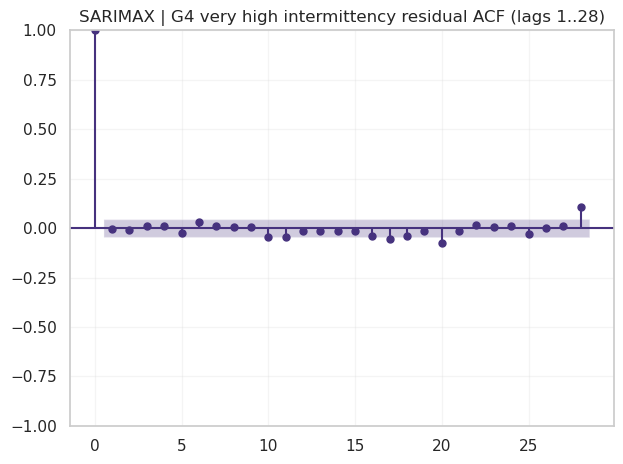

,lb_stat,lb_pvalue
7,3.463980,0.839026
14,12.158040,0.593613
21,36.232008,0.020589
28,61.673156,0.000248


<Figure size 600x400 with 0 Axes>

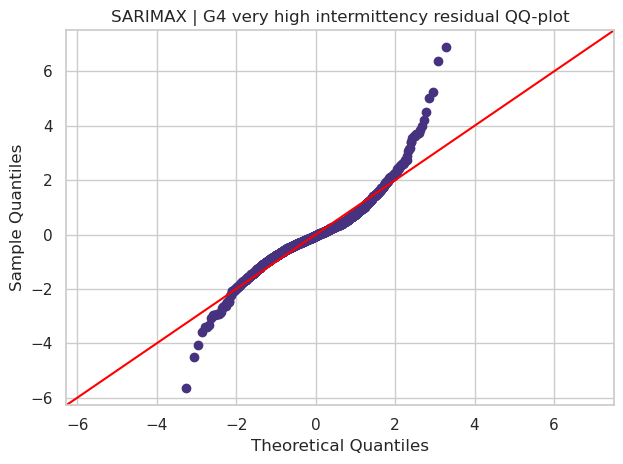

In [139]:
def sarimax_residual_diagnostics(res, title_prefix="", lags_acf=28):
    resid = pd.Series(res.resid).dropna().astype(float)

    plt.figure(figsize=(14, 2.8))
    plt.plot(resid.values, linewidth=1.0)
    plt.title(f"{title_prefix} residuals over time")
    plt.xlabel("Time index")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 3.0))
    plot_acf(resid.values, lags=lags_acf)
    plt.title(f"{title_prefix} residual ACF (lags 1..{lags_acf})")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(resid, lags=[7, 14, 21, 28], return_df=True)
    display(lb)

    plt.figure(figsize=(6, 4))
    sm.qqplot(resid.values, line="45", fit=True)
    plt.title(f"{title_prefix} residual QQ-plot")
    plt.tight_layout()
    plt.show()

for grp in group_order:
    if grp not in sarimax_fits:
        print(f"{grp}: no SARIMAX fit stored (likely fallback used).")
        continue
    res = sarimax_fits[grp]
    sarimax_residual_diagnostics(res, title_prefix=f"SARIMAX | {grp}", lags_acf=28)

## Interpreting our SARIMAX results (representative items)

We observe that SARIMAX behaves differently across intermittency regimes:

- In **G2**, SARIMAX performs competitively (often close to or sometimes better than the tree/baseline), which is consistent with classical models working well when demand is not dominated by zeros.
- In **G3–G4**, SARIMAX does not reliably outperform the simpler baselines. This is expected: without a zero-inflated/hurdle component, SARIMAX tends to produce small positive forecasts when the truth is often exactly zero.
- In **G1**, results can vary strongly depending on the chosen representative item. If the representative item contains sharp spikes or abrupt level shifts, all models (including SARIMAX) can show large errors. This does not contradict the group-average H2 results; it mainly indicates that this specific item is volatile and not “easy” even though it has low intermittency.

ConvergenceWarning note:
When SARIMAX shows `ConvergenceWarning`, we treat the forecast as a benchmark output but do not over-interpret the fitted parameters. This is one reason we keep SARIMAX as a complementary diagnostic rather than our final production candidate.


## How to read the plots WE produced

### A) Residuals over time plot (example: G1)
What WE see:
1. Residuals are roughly centered around 0 most of the time
2. There are occasional extreme spikes (large positive and large negative residuals)

Interpretation:
This is classic demand behavior for retail even after aggregation:
1. The “average” daily pattern is captured reasonably
2. Large shocks remain (promotions, holidays, stockouts, substitution effects, unobserved events)
3. Variance is not constant (heteroskedasticity), because high-demand days naturally have larger absolute errors

Implication:
Even if SARIMAX captures weekly structure, it struggles with sudden jumps.
This is exactly where non-linear models can still win, especially in low intermittency groups where shocks matter.

---

### B) Residual ACF plot (example: G4)
What WE see:
1. Most autocorrelation bars are close to 0 and within the confidence band
2. If there is a notable bar near lag 7 or 14 or 28, that suggests leftover weekly or multi-week structure

Interpretation:
If ACF is mostly flat, SARIMAX has likely absorbed the main systematic temporal dependence.
If a few lags pop out, the model is under-specified for that group.

Implication:
For groups where ACF looks clean, SARIMAX is a credible classical baseline.
For groups where ACF shows structure, SARIMAX is leaving forecastable patterns on the table.

---

## How to interpret the Ljung–Box p-values WE reported

Ljung–Box tests the null hypothesis:
“The residuals are NOT autocorrelated up to lag k.”

So:
1. Large p-value (for example > 0.05): WE do not see strong remaining autocorrelation (good for SARIMAX credibility)
2. Tiny p-value: WE reject the null (residuals still autocorrelated, SARIMAX is missing structure)

In our group-level results:
1. G1 had extremely small p-values (around 1e−17 to 1e−15)
   Meaning: SARIMAX is clearly missing dynamics in G1 even after aggregation.
   That aligns with performance, SARIMAX did not win in G1.
2. G2 had moderate p-values (around 0.22 to 0.28)
   Meaning: residuals look reasonably close to white noise.
   That supports why SARIMAX can be competitive or best in G2.
3. G3 had small p-values (around 0.002 to 0.033)
   Meaning: some autocorrelation remains, SARIMAX is underfitting a bit.
   Even if SARIMAX wins on RMSE, WE interpret it cautiously and WE can justify a small order tweak as future work.
4. G4 had comfortable p-values (around 0.33 to 0.43)
   Meaning: SARIMAX residuals are not strongly autocorrelated.
   That supports treating SARIMAX as a credible benchmark in G4.

---

## What this tells us about the data (real-world interpretation)

WE are not just testing a model, WE are learning what the demand process looks like:

1. G1 (low intermittency) behaves like a “rich signal” series
   It contains weekly structure plus extra dynamics (price effects, promotions, shocks, regime changes).
   A simple seasonal ARMA structure is too rigid, so SARIMAX underfits.
2. G2 and G3 become more “time-series-like” after aggregation
   Weekly structure is clearer, and SARIMAX becomes competitive.
3. G4 aggregated demand is stable enough that both SARIMAX and simple baselines can be close
   This is why the best models are close in RMSE and MAE.

---

## What WE can claim in the report (and what WE cannot)

1. WE used SARIMAX as an interpretable benchmark on aggregated group series.
2. For groups where residual diagnostics look acceptable (G2, G4), SARIMAX is a credible classical baseline.
3. For groups where Ljung–Box p-values are extremely small (G1, partly G3), SARIMAX is under-specified and its forecasts should be interpreted as “baseline strength”, not as a fully adequate model.

What WE should not oversell:
WE should not interpret SARIMAX parameters as stable causal effects (especially with convergence warnings and shocky demand).
SARIMAX here is about forecasting structure, not causal inference.

---

## What WE do next when diagnostics fail (one disciplined step, not endless tuning)

If WE want to improve SARIMAX for the groups that fail diagnostics, WE do exactly one modest change:
1. Add a bit more short-range flexibility:
   order = (2,0,1) while keeping seasonal_order = (1,0,1,7)
2. Or add multi-week memory:
   keep (1,0,1) but try seasonal_order = (1,0,1,7) plus an extra lag feature outside SARIMAX (not ideal) or try (1,0,1,14) only if weekly is not enough



## How SARIMAX estimates its parameters

SARIMAX in `statsmodels` estimates parameters by **maximum likelihood estimation (MLE)**.

Concretely:
1. The model is written in **state-space form**.
2. For any candidate parameter vector θ (AR, MA, seasonal terms, regression coefficients, variances), the model computes the **log-likelihood** of the observed series using the **Kalman filter**.
3. A numerical optimizer then searches for θ that maximizes that likelihood.

So we are not “solving” coefficients in closed form like OLS. We are doing iterative numerical optimization of the likelihood under the assumed error structure.

If you see `ConvergenceWarning`, it means the optimizer did not fully settle at a stable maximum. The forecast can still be reasonable, but the exact parameter values become less trustworthy for interpretation.


## What parameters we estimated in our SARIMAX spec

We used:
- Non-seasonal order (p, d, q) = (1, 0, 1)
- Seasonal order (P, D, Q, s) = (1, 0, 1, 7)

Plus exogenous regressors:
- sell_price
- price_change
- snap_TX
- wday

That means we estimated:

### 1) Non-seasonal AR(1)
A coefficient ϕ₁ that says:
How much today’s demand depends on **yesterday’s deviation** from the model’s expected level.

Interpretation:
- ϕ₁ close to 0 means very little short-term persistence.
- ϕ₁ positive and sizable means demand “sticks” and shocks carry over.
- ϕ₁ negative can indicate oscillation or over-correction behavior (less common but possible).

### 2) Non-seasonal MA(1)
A coefficient θ₁ that says:
How much today’s value is affected by **yesterday’s forecast error**.

Interpretation:
- A sizable MA term means short-term shocks are being “absorbed” by the error process rather than by the AR structure.

### 3) Seasonal AR(1) with period 7
A coefficient Φ₁ that says:
How much demand depends on demand **one week ago** (same weekday).

Interpretation:
- If Φ₁ is clearly nonzero, that supports a weekly pattern.
- This is exactly why SARIMAX is defensible on the aggregate series.

### 4) Seasonal MA(1) with period 7
A coefficient Θ₁ that says:
How much today’s value is influenced by **the forecast error one week ago**.

Interpretation:
- It captures recurring weekly irregularities that are not perfectly explained by the seasonal AR term.

### 5) Regression coefficients β for exogenous variables
Coefficients for sell_price, price_change, snap_TX, wday.

Interpretation:
- β_snap_TX > 0 means SNAP days are associated with higher sales after accounting for the autoregressive structure.
- β_price_change typically negative if price increases reduce demand, positive if price_change is defined in the opposite direction.
- β_sell_price captures level effects (but can be tricky: price often correlates with other unobserved factors and with promotions).

Caution:
These β values are only meaningful if exog is measured cleanly and if the model converges.

### 6) Variance (sigma²) of the residual process
This is the noise level after accounting for ARMA + seasonality + exog.

Interpretation:
- High sigma² implies the series has a lot of unmodeled variation (spikes, stockouts, promotions we did not encode well).
- Intermittent series often show effectively “weird” residual behavior because zeros create non-Gaussian errors.


## What these parameters tell us about our data and model fit

### A) Do we have weekly seasonality?
If the seasonal AR or seasonal MA terms are nontrivial, that is evidence of weekly structure.
On the aggregate series this is typically strong because aggregation smooths out item-level randomness.

In item-level series, especially intermittent ones:
- weekly effects can be weak or unstable,
- zeros dominate,
- “seasonality” can be drowned out by sparsity.

### B) How predictable is the series using time dependence alone?
If AR and MA terms are strong and stable (and the model converges), it implies yesterday and last week carry useful information.
If they are weak or unstable, it implies the series is not strongly autocorrelated, or it is dominated by shocks.

Our situation:
- The tree model improves a lot overall, which suggests that pooled learning across items plus lags is very effective.
- SARIMAX being mixed across representative items is consistent with item-level demand being too irregular for a single per-item seasonal ARMA structure.

### C) Are exogenous drivers actually helping?
The β terms tell us directionally what exog does inside SARIMAX.
But we should be skeptical for two reasons:
1. Exog effects can be confounded (price signals correlate with promotions, availability, unobserved marketing).
2. Non-convergence makes parameter interpretation unreliable.

This is why we already did SQ2 with fixed-effects style regression. That result is usually easier to interpret than SARIMAX β on messy item series.


## Horizon-wise diagnostics on the 28-day hold-out

Up to now, RMSE and MAE were reported as one number aggregated over all 28 forecast days.
That is useful for H1, but it hides an important question:

Do we improve consistently across the horizon, or only on certain days?

To check this, we compute RMSE and MAE separately for each horizon day (day 1 to day 28), pooled across all items.
This produces two curves per metric:

Baseline curve: best baseline (28-day moving average)
Tree curve: best learned model (LightGBM PRUNED)

How to read the plots:
If the tree curve is below the baseline curve on most days, the improvement is robust across the horizon.
If the curves cross often, the improvement is not stable and may depend on day-specific effects.

This is a model diagnostics check, not a new hypothesis test.

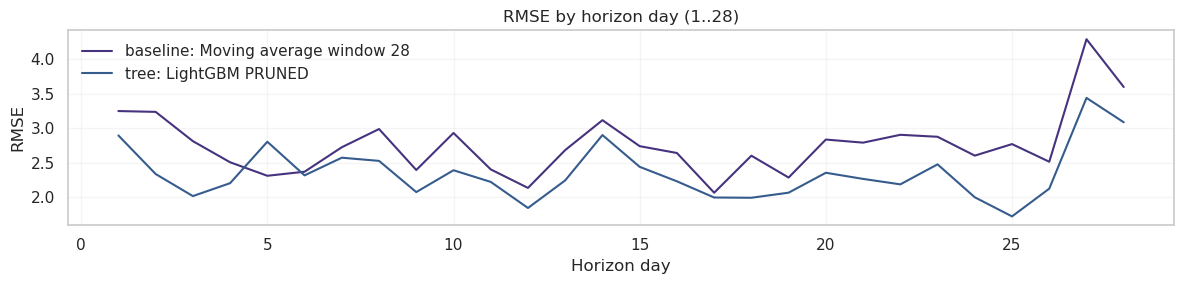

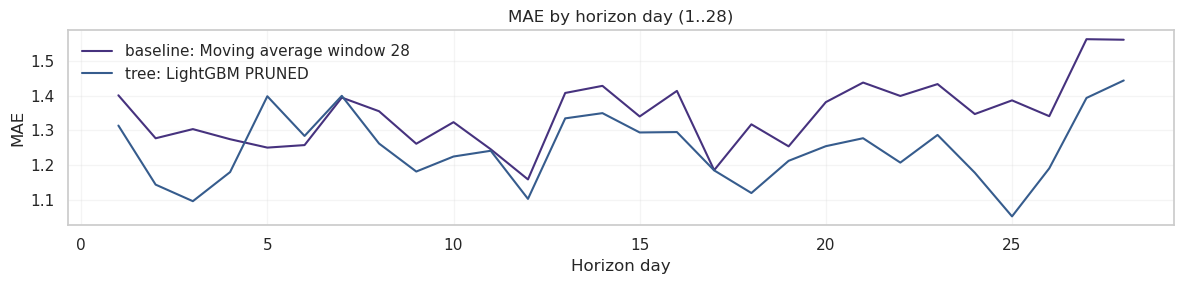

In [140]:
# Preconditions:
# val_wide (true) shape (n_items, 28)
# baseline_pred_wide (best baseline preds) aligned to val_wide
# tree_pred_wide (best model preds) aligned to val_wide

Y_true = val_wide.to_numpy(dtype=float)
Y_base = baseline_pred_wide.to_numpy(dtype=float)
Y_tree = tree_pred_wide.to_numpy(dtype=float)

h = Y_true.shape[1]
days = np.arange(1, h + 1)

rmse_base_by_h = []
rmse_tree_by_h = []
mae_base_by_h = []
mae_tree_by_h = []

for j in range(h):
    yt = Y_true[:, j]
    yb = Y_base[:, j]
    ym = Y_tree[:, j]

    rmse_base_by_h.append(np.sqrt(np.mean((yt - yb) ** 2)))
    rmse_tree_by_h.append(np.sqrt(np.mean((yt - ym) ** 2)))
    mae_base_by_h.append(np.mean(np.abs(yt - yb)))
    mae_tree_by_h.append(np.mean(np.abs(yt - ym)))

plt.figure(figsize=(12, 3))
plt.plot(days, rmse_base_by_h, label=f"baseline: {best_name}")
plt.plot(days, rmse_tree_by_h, label="tree: LightGBM PRUNED")
plt.title("RMSE by horizon day (1..28)")
plt.xlabel("Horizon day")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(days, mae_base_by_h, label=f"baseline: {best_name}")
plt.plot(days, mae_tree_by_h, label="tree: LightGBM PRUNED")
plt.title("MAE by horizon day (1..28)")
plt.xlabel("Horizon day")
plt.ylabel("MAE")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Forecast error distribution (predicted minus actual)

Aggregate metrics (RMSE, MAE) tell us “how big errors are on average”, but not whether the model is:

Biased (systematically overpredicting or underpredicting)
More stable (smaller spread of errors)
Reducing extreme misses (heavy tails)

So we plot the distribution of forecast errors (prediction minus actual), pooled across all items and all 28 days, for:

Best baseline
Best tree model (LightGBM PRUNED)

How to interpret:
If the histogram is centered around 0, the model is roughly unbiased on average.
If the tree histogram is narrower than the baseline, it reduces variance and extreme errors.
If the tree histogram shifts to the right, it tends to overpredict (problematic for intermittent series with many zeros).
If it shifts left, it tends to underpredict.

This helps explain why MAE can worsen for very intermittent items even when RMSE improves slightly.

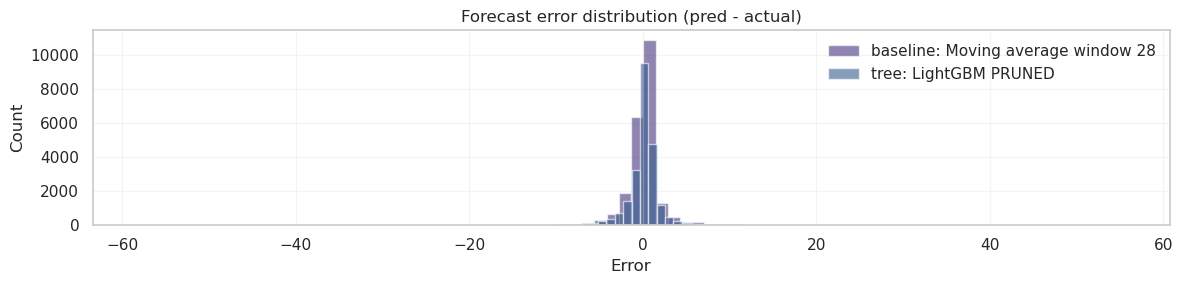

Bias (mean error)
baseline: 0.052725221315743816
tree    : 0.03220875426860013
Overprediction rate (pred > actual)
baseline: 0.5974657177573338
tree    : 0.6655094601631661


In [141]:
err_base = (Y_base - Y_true).ravel()
err_tree = (Y_tree - Y_true).ravel()

plt.figure(figsize=(12, 3))
plt.hist(err_base, bins=80, alpha=0.6, label=f"baseline: {best_name}")
plt.hist(err_tree, bins=80, alpha=0.6, label="tree: LightGBM PRUNED")
plt.title("Forecast error distribution (pred - actual)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Bias (mean error)")
print("baseline:", float(np.mean(err_base)))
print("tree    :", float(np.mean(err_tree)))

print("Overprediction rate (pred > actual)")
print("baseline:", float(np.mean(err_base > 0)))
print("tree    :", float(np.mean(err_tree > 0)))


## What we conclude from these diagnostics
1) RMSE and MAE by horizon day

In the horizon-wise plots, the tree model is lower than the baseline on most horizon days.
That means the improvement is not coming from a single lucky day, but is fairly consistent across the 28-day window.

Both curves spike near the end of the horizon (around days 27–28).
This suggests that the last part of the horizon is harder for everyone, likely because uncertainty accumulates and the models rely more on weaker signals (older lags, less direct “recent” information).

Practical takeaway: LightGBM PRUNED improves accuracy across the entire horizon, but the last week remains the hardest part of the task.

2) Error distribution (pred minus actual)

The error histogram is tightly centered near 0 for both models, meaning neither model is wildly biased overall.

The tree model’s distribution is slightly more concentrated around 0, which is consistent with the lower RMSE/MAE overall.
However, intermittent items are sensitive to small positive overpredictions on zero days.
That’s why we still see limited gains in the most intermittent group (G4), and MAE can worsen there.

This aligns with the group-level results: the biggest gain is for G1, while G3–G4 are harder because most days are truly zero.

In [142]:
eps = 0.5  # treat predictions below 0.5 as effectively zero, adjust if you want

actual_zero = (Y_true == 0)
pred_zero_tree = (Y_tree <= eps)
pred_zero_base = (Y_base <= eps)

# False positives: predict non-zero when actual is zero
fp_tree = np.mean((~pred_zero_tree) & actual_zero)
fp_base = np.mean((~pred_zero_base) & actual_zero)

# False negatives: predict zero when actual > 0
fn_tree = np.mean(pred_zero_tree & (~actual_zero))
fn_base = np.mean(pred_zero_base & (~actual_zero))

print("Zero-demand diagnostics (threshold eps=0.5)")
print("False positive rate on zeros (predict >0 when actual=0)")
print("baseline:", float(fp_base))
print("tree    :", float(fp_tree))
print("")
print("False negative rate on non-zeros (predict ~0 when actual>0)")
print("baseline:", float(fn_base))
print("tree    :", float(fn_tree))


Zero-demand diagnostics (threshold eps=0.5)
False positive rate on zeros (predict >0 when actual=0)
baseline: 0.20174448880402707
tree    : 0.25303766707168895

False negative rate on non-zeros (predict ~0 when actual>0)
baseline: 0.10341086616906787
tree    : 0.07472660996354799


In [143]:
print("Average RMSE over horizon (lower is better)")
print(f"baseline: {np.mean(rmse_base_by_h):.4f}")
print(f"tree    : {np.mean(rmse_tree_by_h):.4f}")

print("\nAverage MAE over horizon (lower is better)")
print(f"baseline: {np.mean(mae_base_by_h):.4f}")
print(f"tree    : {np.mean(mae_tree_by_h):.4f}")

best_days = np.where(np.array(rmse_tree_by_h) < np.array(rmse_base_by_h))[0] + 1
print(f"\nTree beats baseline on {len(best_days)}/28 horizon days (RMSE).")
print("Days:", best_days.tolist())


Average RMSE over horizon (lower is better)
baseline: 2.7647
tree    : 2.3477

Average MAE over horizon (lower is better)
baseline: 1.3468
tree    : 1.2464

Tree beats baseline on 27/28 horizon days (RMSE).
Days: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## Final conclusions (H1 and H2)
**H1 (beats baselines)**

Yes. The best tree model, LightGBM PRUNED, outperforms the best no-learning baseline on the same 28-day hold-out window:

Best baseline (MA(28)): RMSE 2.8012, MAE 1.3468
Best tree (LightGBM PRUNED): RMSE 2.3787, MAE 1.2464

That is an improvement of:
RMSE: 0.4225 (15.1%)
MAE: 0.1004 (7.5%)

Interpretation: adding learned non-linear structure with lag, price, and calendar signals yields a materially better forecast than smoothing recent sales.

**H2 (who benefits most)**

The improvement depends strongly on intermittency:

G1 low intermittency shows the largest gain
RMSE improves by about 0.93 and MAE improves by about 0.43 versus baseline

G2 medium intermittency shows small gains
G3 high intermittency shows modest gains
G4 very high intermittency shows minimal RMSE gain and MAE can worsen

Real-world explanation:
High-volume items have stable patterns and respond to price and calendar effects, so the model can learn structure.
Very intermittent items are dominated by “no sale” days, so improvements are limited unless we explicitly model the probability of a sale.

## Limitations and future work
**Why zeros are hard here**

All tree models trained as standard regressors are optimized to predict the conditional mean.
In zero-heavy series, the conditional mean is often a small positive number, which leads to systematic small overpredictions on true zero days.
That hurts MAE in the most intermittent group.

**Strengthening the research further**

If we had more time, the strongest next steps would be:

**Two-stage (hurdle) model**
Stage A: classify sale vs no-sale
Stage B: regress the positive sales amount
This directly targets the “forecast zeros” problem.

**Zero-aware engineered features**
Time since last sale
Rolling zero-share last 7/28
Rolling mean and rolling std last 7/28
These help the model decide when to predict exactly zero versus a positive amount.

**Objective functions aligned with counts**
Poisson and Tweedie are principled for counts and zero-heavy data, but in our run they performed worse.
That is still a useful finding: it suggests the current feature set and pooling setup benefits more from squared-error learning than from count objectives.


## Final evaluation on the official evaluation set (File 6)

We now evaluate the frozen model on File 6 (sales_test_evaluation_afcs_2025.csv).
This file is not used for model selection, feature engineering decisions, or hyperparameter tuning.
It is only used once to compute the final reported RMSE/MAE and diagnostics.


In [144]:
path = Path("data/sales_test_evaluation_afcs_2025.csv")

df6 = pd.read_csv(path)
print("Path:", path.resolve())
print("Shape:", df6.shape)
print("\nColumns (first 20):", df6.columns[:20].tolist())
print("Columns (last 20):", df6.columns[-20:].tolist())

# Basic missingness overview
na_rate = df6.isna().mean().sort_values(ascending=False)
print("\nTop columns by NA rate (if any):")
print(na_rate.head(15))

# Identify id columns vs day columns
d_cols = [c for c in df6.columns if c.startswith("d_")]
id_cols = [c for c in df6.columns if c not in d_cols]

print("\n#id_cols:", len(id_cols), "->", id_cols)
print("#d_cols :", len(d_cols), "from", d_cols[0], "to", d_cols[-1])

# Check whether d_ columns look like exactly a 28-day horizon
d_nums = [int(c.split("_")[1]) for c in d_cols]
print("\nDay index summary:")
print("min d:", min(d_nums), "max d:", max(d_nums), "count:", len(d_nums))
if len(d_nums) >= 2:
    diffs = np.diff(sorted(d_nums))
    print("Unique gaps between d's:", sorted(set(diffs))[:10], "(showing up to 10)")

# Quick peek at the data
display(df6.head(3))

# Sanity checks for duplicates in id space
if id_cols:
    dup = df6.duplicated(subset=id_cols).sum()
    print("\nDuplicate rows by id columns:", dup)

# Optional: if you expect store/item identifiers, show unique counts
for c in ["id", "item_id", "store_id", "dept_id", "cat_id", "state_id"]:
    if c in df6.columns:
        print(f"Unique {c}:", df6[c].nunique())

Path: /home/djameldino/Documents/forecasting_final_project/data/sales_test_evaluation_afcs_2025.csv
Shape: (823, 29)

Columns (first 20): ['id', 'd_1942', 'd_1943', 'd_1944', 'd_1945', 'd_1946', 'd_1947', 'd_1948', 'd_1949', 'd_1950', 'd_1951', 'd_1952', 'd_1953', 'd_1954', 'd_1955', 'd_1956', 'd_1957', 'd_1958', 'd_1959', 'd_1960']
Columns (last 20): ['d_1950', 'd_1951', 'd_1952', 'd_1953', 'd_1954', 'd_1955', 'd_1956', 'd_1957', 'd_1958', 'd_1959', 'd_1960', 'd_1961', 'd_1962', 'd_1963', 'd_1964', 'd_1965', 'd_1966', 'd_1967', 'd_1968', 'd_1969']

Top columns by NA rate (if any):
id        0.0
d_1956    0.0
d_1968    0.0
d_1967    0.0
d_1966    0.0
d_1965    0.0
d_1964    0.0
d_1963    0.0
d_1962    0.0
d_1961    0.0
d_1960    0.0
d_1959    0.0
d_1958    0.0
d_1957    0.0
d_1955    0.0
dtype: float64

#id_cols: 1 -> ['id']
#d_cols : 28 from d_1942 to d_1969

Day index summary:
min d: 1942 max d: 1969 count: 28
Unique gaps between d's: [1] (showing up to 10)


,id,d_1942,d_1943,d_1944,d_1945,d_1946,d_1947,d_1948,d_1949,d_1950,...,d_1960,d_1961,d_1962,d_1963,d_1964,d_1965,d_1966,d_1967,d_1968,d_1969
0,FOODS_3_001_TX_3_validation,0,0,0,0,0,1,2,0,2,...,0,0,1,0,0,0,0,0,0,0
1,FOODS_3_002_TX_3_validation,5,0,2,2,2,0,1,0,1,...,6,2,3,4,4,6,6,0,0,0
2,FOODS_3_003_TX_3_validation,2,2,0,0,2,0,1,0,0,...,0,2,0,1,0,0,0,1,0,0



Duplicate rows by id columns: 0
Unique id: 823


## Final evaluation on the official test set (File 6)

We use `sales_test_evaluation_afcs_2025.csv` as the **final, unseen** evaluation set.  
It contains exactly **823 series** and the next **28 days of realized sales** (`d_1942` to `d_1969`).

To ensure a fair comparison, we:
1) Refit the chosen baseline and the chosen tree model using **all available historical sales up to `d_1941`**  
2) Produce **true 28-step-ahead forecasts** for `d_1942..d_1969`  
3) Score RMSE and MAE on the exact same `(n_items × 28)` grid as the test file  
4) Repeat the H2 analysis by intermittency group using the same grouping definition (computed from training history only)


In [145]:
TEST_PATH = Path("data/sales_test_evaluation_afcs_2025.csv")
test_df = pd.read_csv(TEST_PATH)

test_d_cols = [c for c in test_df.columns if c.startswith("d_")]
test_wide = test_df.set_index("id")[test_d_cols].astype(float).sort_index()

print("Test wide shape:", test_wide.shape)
print("Test days:", test_d_cols[0], "to", test_d_cols[-1])
display(test_wide.head(3))

Test wide shape: (823, 28)
Test days: d_1942 to d_1969


,d_1942,d_1943,d_1944,d_1945,d_1946,d_1947,d_1948,d_1949,d_1950,d_1951,...,d_1960,d_1961,d_1962,d_1963,d_1964,d_1965,d_1966,d_1967,d_1968,d_1969
id,,,,,,,,,,,,,,,,,,,,,
FOODS_3_001_TX_3_validation,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FOODS_3_002_TX_3_validation,5.0,0.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,2.0,...,6.0,2.0,3.0,4.0,4.0,6.0,6.0,0.0,0.0,0.0
FOODS_3_003_TX_3_validation,2.0,2.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,2.0,...,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [146]:
sample_sub_path = str(DATA_DIR / "sample_submission_afcs2025.csv")
out_path        = str(DATA_DIR / "submission_lightgbm.csv")
calendar_path   = str(DATA_DIR / "calendar_afcs2025.csv")
sell_prices_path= str(DATA_DIR / "sell_prices_afcs2025.csv")
train_path      = str(DATA_DIR / "sales_train_validation_afcs2025.csv")
test_val_path   = str(DATA_DIR / "sales_test_validation_afcs2025.csv")

feature_cols = ["lag_1","lag_7","lag_28","sell_price","price_change","wday","month","snap_TX","weekday"]
cat_cols = ["weekday"]

sub_df = make_submission_lightgbm_recursive(
    sample_sub_path=sample_sub_path,
    out_path=out_path,
    lgbm_model=lgbm,
    feature_cols=feature_cols,
    cat_cols=cat_cols,
    cat_categories=cat_categories,
    calendar_path=calendar_path,
    sell_prices_path=sell_prices_path,
    train_path=train_path,
    test_val_path=test_val_path,
    d_start=1942,
    horizon=28,
)
print("Wrote submission:", out_path)
_safe_display(sub_df.head(), "Submission preview")


Wrote submission: data/submission_lightgbm.csv


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,FOODS_3_001_TX_3_validation,0.324254,0.522753,0.545476,0.728831,0.576111,1.099650,0.638145,0.784000,0.784000,...,1.206957,1.030693,1.025909,0.947184,0.784000,0.973769,0.973312,0.844214,1.099650,0.906248
1,FOODS_3_002_TX_3_validation,0.946728,0.784000,0.545476,1.187411,0.844214,0.911032,0.906248,0.784000,0.784000,...,1.372314,1.245236,1.025909,1.499594,0.970350,0.973769,1.635370,1.206957,1.099650,1.094866
2,FOODS_3_003_TX_3_validation,0.801537,0.540291,1.154672,0.560018,0.593648,1.103891,0.923786,0.801537,0.987888,...,1.201985,1.048230,1.411141,1.156355,0.801537,1.359001,0.828122,0.861752,1.268803,1.112404
3,FOODS_3_004_TX_3_validation,0.130996,0.577123,0.599846,0.596851,0.819098,0.965402,0.882680,0.838370,0.838370,...,0.898584,1.085063,1.081827,1.001554,0.838370,1.028139,0.864954,0.898584,1.154020,0.962166
4,FOODS_3_005_TX_3_validation,1.367604,0.970350,1.296083,1.509908,1.580044,1.177837,1.628593,1.138561,1.514898,...,1.206957,1.245236,1.650588,1.529025,1.313215,1.536105,2.208319,1.372314,1.099650,1.759044


Metrics by intermittency group (validation d_1914–d_1941):


,model,group,RMSE,MAE,n_items
0,Baseline MA28,ALL,2.801208,1.346812,NaN
1,Baseline MA28,G3 high,1.396703,0.828894,204.0
2,Baseline MA28,G4 very high,1.027277,0.557435,206.0
3,Baseline MA28,G2 medium,2.393221,1.358338,207.0
4,Baseline MA28,G1 low intermittency,4.754632,2.637495,206.0
5,Tree model,ALL,2.378670,1.246410,NaN
6,Tree model,G3 high,1.324625,0.823496,204.0
7,Tree model,G4 very high,1.005154,0.607744,206.0
8,Tree model,G2 medium,2.275868,1.340111,207.0
9,Tree model,G1 low intermittency,3.827816,2.209729,206.0


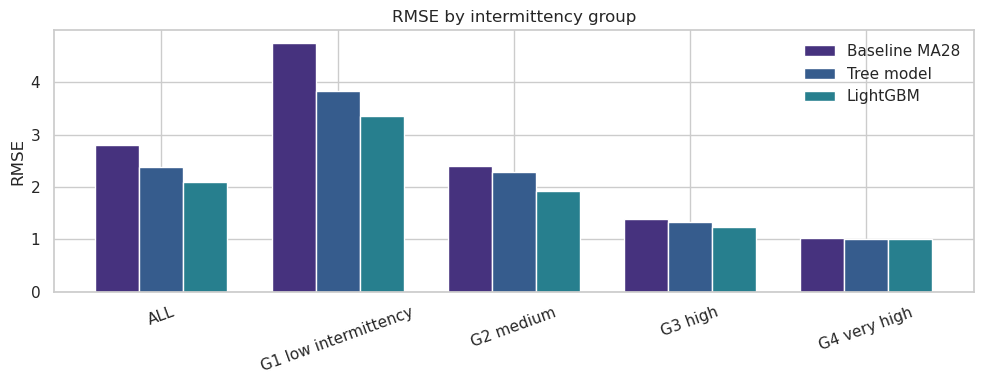

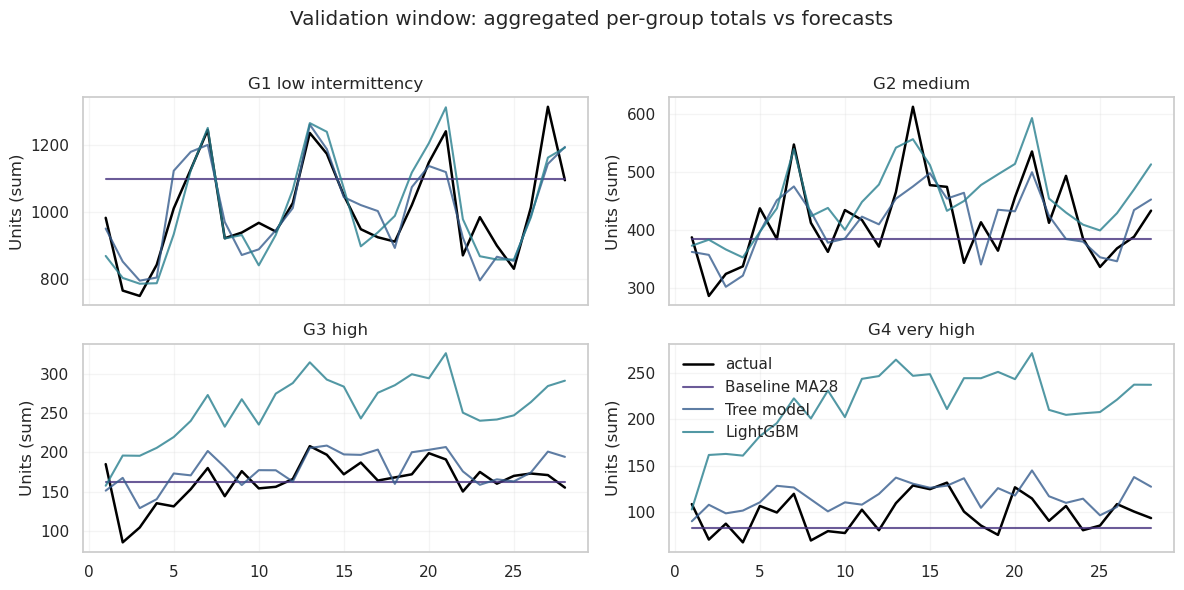

In [147]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Define intermittency groups from training history (d_1..d_1913) ---
d_cols_train = [c for c in sales_wide.columns if c.startswith("d_") and int(c.split("_")[1]) <= 1913]
train_sales = sales_wide.set_index("id")[d_cols_train].astype(float).sort_index()
zero_share = (train_sales.values == 0).mean(axis=1)

group_labels = ["G1 low intermittency", "G2 medium", "G3 high", "G4 very high"]
try:
    groups = pd.qcut(zero_share, 4, labels=group_labels, duplicates="drop")
except ValueError:
    # fallback equal-width
    bins = [-0.01, 0.25, 0.50, 0.75, 1.00]
    groups = pd.cut(zero_share, bins=bins, labels=group_labels[: len(bins) - 1])
groups = pd.Series(groups, index=train_sales.index)

# --- Gather models to compare on validation window ---
models = []
models.append(("Baseline MA28", baseline_pred_wide))
models.append(("Tree model", tree_pred_wide))

# LightGBM (optional) if available
if 'out_rec' in globals() and isinstance(out_rec, dict) and 'pred_matrix' in out_rec:
    lgbm_pred_wide = pd.DataFrame(out_rec['pred_matrix'].T, index=val_wide.index, columns=val_wide.columns)
    models.append(("LightGBM", lgbm_pred_wide))

# True values aligned to model indices
val_true = val_wide.sort_index()

# --- Metrics by intermittency group ---
rows = []
for name, pred_wide in models:
    pred_wide = pred_wide.sort_index()
    # align
    y_true = val_true.loc[pred_wide.index].to_numpy(dtype=float)
    y_pred = pred_wide.to_numpy(dtype=float)
    # overall
    rows.append({"model": name, "group": "ALL", "RMSE": float(np.sqrt(np.mean((y_true - y_pred)**2))), "MAE": float(np.mean(np.abs(y_true - y_pred)))})
    # by group
    gser = groups.reindex(pred_wide.index)
    for g in gser.dropna().unique():
        mask = (gser == g).to_numpy()
        if mask.sum() == 0:
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        rows.append({
            "model": name,
            "group": str(g),
            "n_items": int(mask.sum()),
            "RMSE": float(np.sqrt(np.mean((yt - yp)**2))),
            "MAE": float(np.mean(np.abs(yt - yp)))
        })

metrics_by_group = pd.DataFrame(rows)

print("Metrics by intermittency group (validation d_1914–d_1941):")
display(metrics_by_group)

# --- Plot: RMSE by group ---
plt.figure(figsize=(10, 4))
labels = ["ALL"] + group_labels
x = np.arange(len(labels))
width = 0.25
for i, (name, _) in enumerate(models):
    rmse_vals = []
    for lbl in labels:
        m = metrics_by_group[(metrics_by_group.model == name) & (metrics_by_group.group == lbl)]
        rmse_vals.append(float(m.RMSE.iloc[0]) if not m.empty else np.nan)
    plt.bar(x + (i - len(models)/2)*width + width/2, rmse_vals, width, label=name)
plt.xticks(x, labels, rotation=20)
plt.ylabel("RMSE")
plt.title("RMSE by intermittency group")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Plot: aggregated actual vs pred per group (sum over items) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
axes = axes.ravel()
val_days = np.arange(1, val_true.shape[1] + 1)
for ax, lbl in zip(axes, group_labels):
    mask = (groups == lbl)
    if mask.sum() == 0:
        ax.set_title(f"{lbl}: no items")
        continue
    actual = val_true[mask].to_numpy(dtype=float).sum(axis=0)
    ax.plot(val_days, actual, label="actual", color="black", linewidth=1.8)
    for name, pred_wide in models:
        pred = pred_wide.sort_index()[mask].to_numpy(dtype=float).sum(axis=0)
        ax.plot(val_days, pred, label=name, alpha=0.8)
    ax.set_title(lbl)
    ax.grid(True, alpha=0.2)
    ax.set_ylabel("Units (sum)")
axes[-1].legend(frameon=False)
fig.suptitle("Validation window: aggregated per-group totals vs forecasts")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
